In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

seed = 42
torch.manual_seed(seed)  # Seed for PyTorch
np.random.seed(seed)     # Seed for NumPy
random.seed(seed)        # Seed for Python's random library (if needed)

np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configuration
config = {
    'tickers': ['AAPL', 'MSFT', 'GOOGL'],
    'start_date': "2020-01-01",
    'end_date': "2024-01-01",
    'sequence_length': 30,
    'features': ['Open', 'High', 'Low', 'Close'],
    'random_seed': 42
}

np.random.seed(config['random_seed'])


Processing AAPL...

Shape of AAPL data: (1006, 5)

First few rows of AAPL data:


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,74.0600,75.1500,73.7975,75.0875,135480400
2020-01-03 00:00:00+00:00,74.2875,75.1450,74.1250,74.3575,146322800
2020-01-06 00:00:00+00:00,73.4475,74.9900,73.1875,74.9500,118387200
2020-01-07 00:00:00+00:00,74.9600,75.2250,74.3700,74.5975,108872000
2020-01-08 00:00:00+00:00,74.2900,76.1100,74.2900,75.7975,132079200


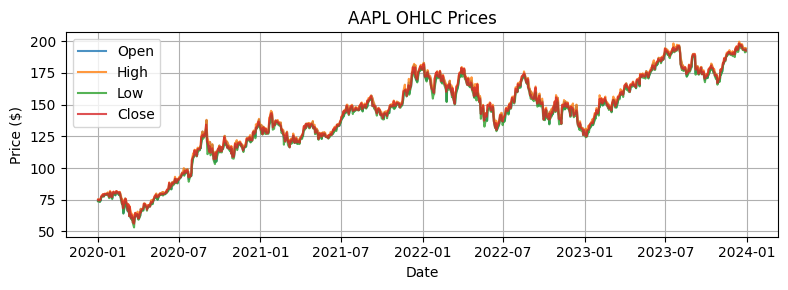

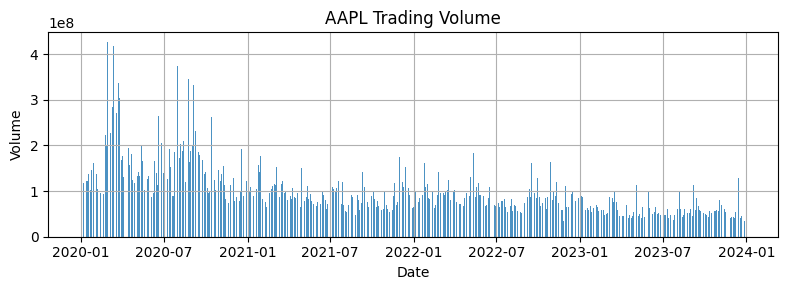


Statistics for AAPL:


,Open,High,Low,Close,Volume
count,1006.0000,1006.0000,1006.0000,1006.0000,1006.0000
mean,140.6755,142.3214,139.1435,140.8081,98952110.7356
std,33.3100,33.4306,33.1792,33.3139,54396526.6656
min,57.0200,57.1250,53.1525,56.0925,24048300.0000
25%,123.6825,125.0300,122.1575,123.5925,64076750.0000
50%,145.5400,147.2650,144.1200,145.8600,84675400.0000
75%,166.3025,168.1475,164.8150,166.2150,115506875.0000
max,198.0200,199.6200,197.0000,198.1100,426510000.0000


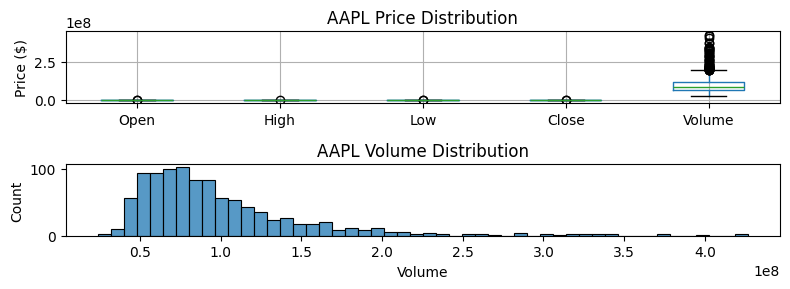


Processing MSFT...

Shape of MSFT data: (1006, 5)

First few rows of MSFT data:


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,158.7800,160.7300,158.3300,160.6200,22622100
2020-01-03 00:00:00+00:00,158.3200,159.9500,158.0600,158.6200,21116200
2020-01-06 00:00:00+00:00,157.0800,159.1000,156.5100,159.0300,20813700
2020-01-07 00:00:00+00:00,159.3200,159.6700,157.3200,157.5800,21634100
2020-01-08 00:00:00+00:00,158.9300,160.8000,157.9500,160.0900,27746500


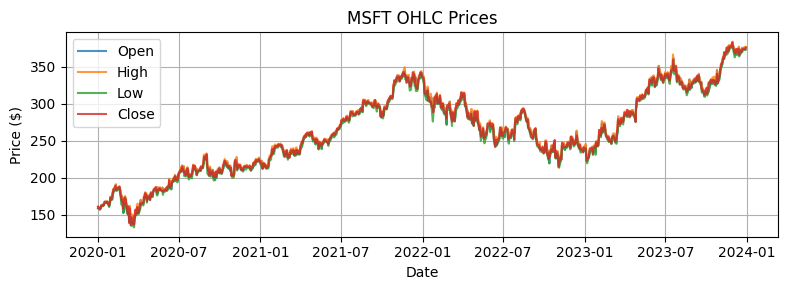

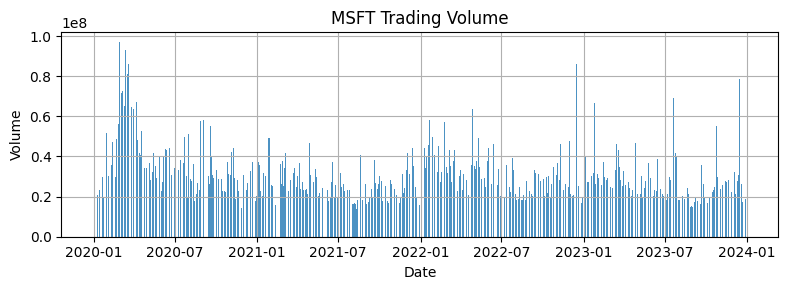


Statistics for MSFT:


,Open,High,Low,Close,Volume
count,1006.0000,1006.0000,1006.0000,1006.0000,1006.0000
mean,262.6693,265.5094,259.8040,262.7819,30654170.6759
std,54.6526,54.7324,54.4156,54.6220,12997976.8431
min,137.0100,140.5700,132.5200,135.4200,9200800.0000
25%,222.0025,224.1450,219.1300,221.4700,22495225.0000
50%,259.1650,261.5000,255.9900,259.4650,27272750.0000
75%,304.2300,307.8200,301.1200,304.3225,34620200.0000
max,383.7600,384.3000,378.1600,382.7000,97012700.0000


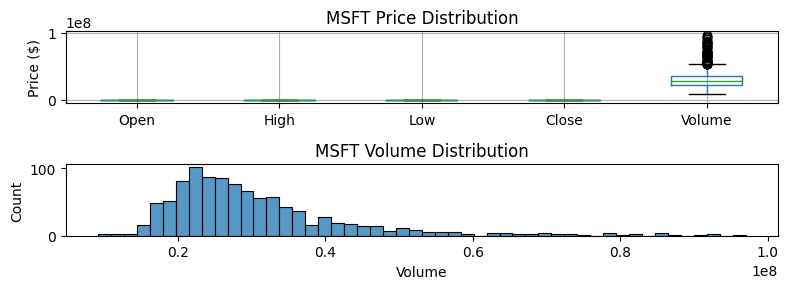


Processing GOOGL...

Shape of GOOGL data: (1006, 5)

First few rows of GOOGL data:


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,67.4205,68.4340,67.3245,68.4340,27278000
2020-01-03 00:00:00+00:00,67.4000,68.6875,67.3660,68.0760,23408000
2020-01-06 00:00:00+00:00,67.5815,69.9160,67.5500,69.8905,46768000
2020-01-07 00:00:00+00:00,70.0230,70.1750,69.5780,69.7555,34330000
2020-01-08 00:00:00+00:00,69.7410,70.5925,69.6315,70.2520,35314000


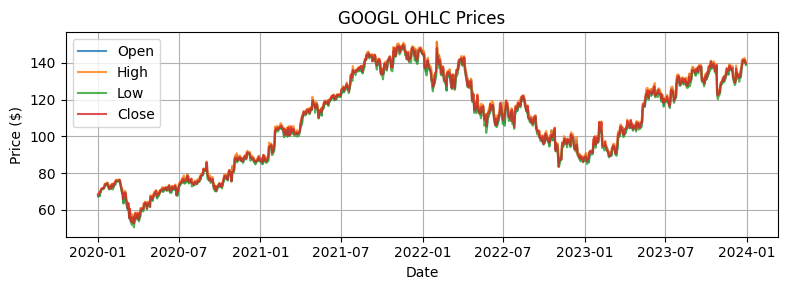

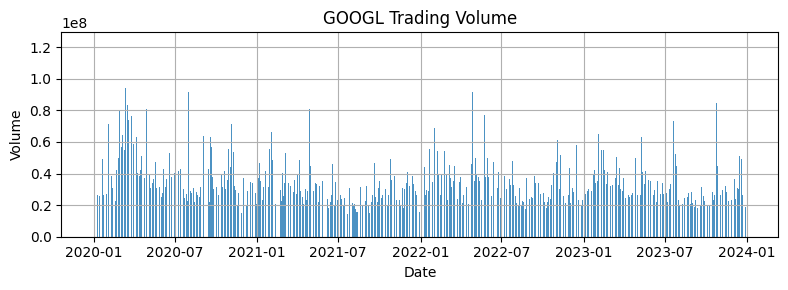


Statistics for GOOGL:


,Open,High,Low,Close,Volume
count,1006.0000,1006.0000,1006.0000,1006.0000,1006.0000
mean,107.8022,109.0883,106.5954,107.8702,34499134.2942
std,25.1683,25.2753,24.9839,25.1149,15014268.5249
min,52.8185,53.3455,50.4435,52.7065,9312000.0000
25%,88.1025,88.8566,86.9489,88.0285,25026850.0000
50%,109.7887,111.4365,107.9700,109.8885,30718000.0000
75%,130.7532,132.0821,128.9900,130.2500,39339000.0000
max,151.2500,151.5465,148.8990,149.8385,123200000.0000


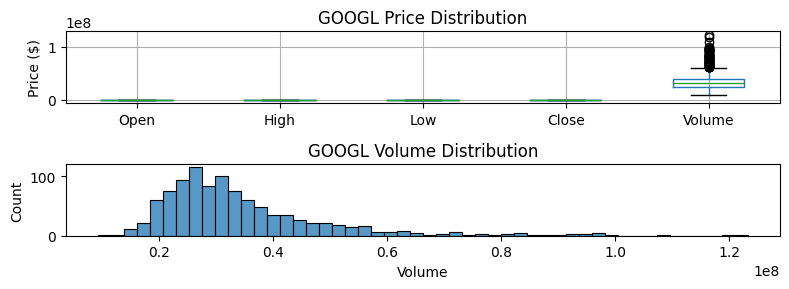

In [2]:

np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Download and inspect raw data
raw_data = {}
columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for ticker in config['tickers']:
    print(f"\nProcessing {ticker}...")
    
    # Download data
    df = yf.download(ticker, start=config['start_date'], end=config['end_date'], progress=False)
    raw_data[ticker] = df[columns]
    
    # Print data info
    print(f"\nShape of {ticker} data:", df[columns].shape)
    print(f"\nFirst few rows of {ticker} data:")
    display(df[columns].head())
    
    # Create two separate figures: one for prices, one for volume
    # Price Plot
    plt.figure(figsize=(8, 3))
    for col in config['features']:
        plt.plot(df.index, df[col], label=col, alpha=0.8)
    plt.title(f'{ticker} OHLC Prices')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Volume Plot
    plt.figure(figsize=(8, 3))
    plt.bar(df.index, df['Volume'], alpha=0.8)
    plt.title(f'{ticker} Trading Volume')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nStatistics for {ticker}:")
    display(df[columns].describe())
    
    # Show basic statistical plots
    plt.figure(figsize=(8, 3))
    
    # Box plot for price columns
    plt.subplot(2, 1, 1)
    df[columns].boxplot()
    plt.title(f'{ticker} Price Distribution')
    plt.ylabel('Price ($)')
    
    # Volume distribution
    plt.subplot(2, 1, 2)
    sns.histplot(df['Volume'], bins=50)
    plt.title(f'{ticker} Volume Distribution')
    plt.xlabel('Volume')
    
    plt.tight_layout()
    plt.show()

In [3]:
raw_data['AAPL']

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,74.0600,75.1500,73.7975,75.0875,135480400
2020-01-03 00:00:00+00:00,74.2875,75.1450,74.1250,74.3575,146322800
2020-01-06 00:00:00+00:00,73.4475,74.9900,73.1875,74.9500,118387200
2020-01-07 00:00:00+00:00,74.9600,75.2250,74.3700,74.5975,108872000
2020-01-08 00:00:00+00:00,74.2900,76.1100,74.2900,75.7975,132079200
...,...,...,...,...,...
2023-12-22 00:00:00+00:00,195.1800,195.4100,192.9700,193.6000,37122800
2023-12-26 00:00:00+00:00,193.6100,193.8900,192.8300,193.0500,28919300
2023-12-27 00:00:00+00:00,192.4900,193.5000,191.0900,193.1500,48087700


In [4]:
raw_data

{'AAPL':                               Open     High      Low    Close     Volume
 Date                                                                    
 2020-01-02 00:00:00+00:00  74.0600  75.1500  73.7975  75.0875  135480400
 2020-01-03 00:00:00+00:00  74.2875  75.1450  74.1250  74.3575  146322800
 2020-01-06 00:00:00+00:00  73.4475  74.9900  73.1875  74.9500  118387200
 2020-01-07 00:00:00+00:00  74.9600  75.2250  74.3700  74.5975  108872000
 2020-01-08 00:00:00+00:00  74.2900  76.1100  74.2900  75.7975  132079200
 ...                            ...      ...      ...      ...        ...
 2023-12-22 00:00:00+00:00 195.1800 195.4100 192.9700 193.6000   37122800
 2023-12-26 00:00:00+00:00 193.6100 193.8900 192.8300 193.0500   28919300
 2023-12-27 00:00:00+00:00 192.4900 193.5000 191.0900 193.1500   48087700
 2023-12-28 00:00:00+00:00 194.1400 194.6600 193.1700 193.5800   34049900
 2023-12-29 00:00:00+00:00 193.9000 194.4000 191.7300 192.5300   42628800
 
 [1006 rows x 5 columns],
 '

In [5]:
def create_sequences_single_stock(stock_data: pd.DataFrame, seq_length: int, ticker_id: int) -> tuple:
    """
    Create sequences from a single stock's data and include ticker_id.
    """
    # Separate OHLC and Volume
    ohlc_data = stock_data[['Open', 'High', 'Low', 'Close']].values
    volume_data = stock_data[['Volume']].values
    
    # Create sequences
    sequences_ohlc = []
    sequences_volume = []
    ticker_ids = []  # Track ticker IDs for each sequence
    
    for i in range(len(stock_data) - seq_length + 1):
        sequences_ohlc.append(ohlc_data[i:i + seq_length])
        sequences_volume.append(volume_data[i:i + seq_length])
        ticker_ids.append(ticker_id)  # Append the ticker_id for each sequence
    
    sequences_ohlc = np.array(sequences_ohlc)
    sequences_volume = np.array(sequences_volume)
    ticker_ids = np.array(ticker_ids)  # Convert to a numpy array for consistency
    
    return sequences_ohlc, sequences_volume, ticker_ids


ticker_to_id = {ticker: idx for idx, ticker in enumerate(config['tickers'])}





In [6]:

# Create sequences for each ticker
sequences = {}
for ticker in config['tickers']:
    ticker_id = ticker_to_id[ticker]
    sequences_ohlc, sequences_volume, ticker_ids = create_sequences_single_stock(
        raw_data[ticker], 
        config['sequence_length'],
        ticker_id
    )
    
    sequences[ticker] = {
        'sequences_ohlc': sequences_ohlc,
        'sequences_volume': sequences_volume,
        'ticker_ids': ticker_ids  # Track ticker_id for each sequence
    }
    
    print(f"\nStored sequences for ticker {ticker}: {sequences_ohlc.shape}")
    print(f"\nStored sequences for ticker {ticker}: {sequences_ohlc}")



Stored sequences for ticker AAPL: (977, 30, 4)

Stored sequences for ticker AAPL: [[[ 74.06    75.15    73.7975  75.0875]
  [ 74.2875  75.145   74.125   74.3575]
  [ 73.4475  74.99    73.1875  74.95  ]
  ...
  [ 80.9     80.975   79.6775  79.9025]
  [ 80.3675  81.805   80.3675  81.8   ]
  [ 81.0475  81.555   80.8375  81.2175]]

 [[ 74.2875  75.145   74.125   74.3575]
  [ 73.4475  74.99    73.1875  74.95  ]
  [ 74.96    75.225   74.37    74.5975]
  ...
  [ 80.3675  81.805   80.3675  81.8   ]
  [ 81.0475  81.555   80.8375  81.2175]
  [ 81.185   81.495   80.7125  81.2375]]

 [[ 73.4475  74.99    73.1875  74.95  ]
  [ 74.96    75.225   74.37    74.5975]
  [ 74.29    76.11    74.29    75.7975]
  ...
  [ 81.0475  81.555   80.8375  81.2175]
  [ 81.185   81.495   80.7125  81.2375]
  [ 78.84    79.9375  78.6525  79.75  ]]

 ...

 [[187.7    188.11   186.3    187.44  ]
  [187.85   189.5    187.78   188.01  ]
  [189.57   190.96   188.65   189.71  ]
  ...
  [195.18   195.41   192.97   193.6   ]
 

In [7]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 30,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 42}

In [8]:
raw_data['AAPL'].head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,74.0600,75.1500,73.7975,75.0875,135480400
2020-01-03 00:00:00+00:00,74.2875,75.1450,74.1250,74.3575,146322800
2020-01-06 00:00:00+00:00,73.4475,74.9900,73.1875,74.9500,118387200
2020-01-07 00:00:00+00:00,74.9600,75.2250,74.3700,74.5975,108872000
2020-01-08 00:00:00+00:00,74.2900,76.1100,74.2900,75.7975,132079200


In [9]:
config['tickers']

['AAPL', 'MSFT', 'GOOGL']

In [10]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 30,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 42}

In [11]:
sequences

{'AAPL': {'sequences_ohlc': array([[[ 74.06  ,  75.15  ,  73.7975,  75.0875],
          [ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ],
          ...,
          [ 80.9   ,  80.975 ,  79.6775,  79.9025],
          [ 80.3675,  81.805 ,  80.3675,  81.8   ],
          [ 81.0475,  81.555 ,  80.8375,  81.2175]],
  
         [[ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975],
          ...,
          [ 80.3675,  81.805 ,  80.3675,  81.8   ],
          [ 81.0475,  81.555 ,  80.8375,  81.2175],
          [ 81.185 ,  81.495 ,  80.7125,  81.2375]],
  
         [[ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975],
          [ 74.29  ,  76.11  ,  74.29  ,  75.7975],
          ...,
          [ 81.0475,  81.555 ,  80.8375,  81.2175],
          [ 81.185 ,  81.495 ,  80.7125,  81.2375],
          [ 78.84  ,  79.9375,  78.65

In [12]:
# processed_data = {}
# for ticker in sequences:
#     # Get the raw OHLC and volume sequences
#     sequences_ohlc = sequences[ticker]['sequences_ohlc']
#     sequences_volume = sequences[ticker]['sequences_volume']
#     ticker_ids = sequences[ticker]['ticker_ids']
    
#     # Calculate mean and standard deviation for normalization on raw data
#     ohlc_mean = sequences_ohlc.mean(axis=(0, 1))
#     ohlc_std = sequences_ohlc.std(axis=(0, 1))
#     vol_mean = sequences_volume.mean()
#     vol_std = sequences_volume.std()
    
#     # Normalize the data
#     norm_ohlc = (sequences_ohlc - ohlc_mean) / (ohlc_std + 1e-8)
#     norm_volume = (sequences_volume - vol_mean) / (vol_std + 1e-8)
    
#     # Verify normalization by calculating mean and std of the normalized data
#     norm_ohlc_mean = norm_ohlc.mean(axis=(0, 1))
#     norm_ohlc_std = norm_ohlc.std(axis=(0, 1))
#     norm_volume_mean = norm_volume.mean()
#     norm_volume_std = norm_volume.std()
    
#     # Store both the normalized data and the "normalized parameters" (should be close to 0 and 1)
#     processed_data[ticker] = {
#         'sequences_ohlc': sequences_ohlc,           # Original raw OHLC sequences
#         'sequences_volume': sequences_volume,       # Original raw Volume sequences
#         'norm_ohlc': norm_ohlc,                     # Normalized OHLC sequences
#         'norm_volume': norm_volume,                 # Normalized Volume sequences
#         'norm_params': {                            # Store normalized parameters
#             'ohlc_mean': norm_ohlc_mean,
#             'ohlc_std': norm_ohlc_std,
#             'vol_mean': norm_volume_mean,
#             'vol_std': norm_volume_std
#         },
#         'ticker_ids': ticker_ids                    # Ticker IDs for each sequence
#     }
    
#     print(f"\nNormalization parameters for {ticker} (should be close to 0 and 1):")
#     print("Normalized OHLC Mean:", norm_ohlc_mean)
#     print("Normalized OHLC Std Dev:", norm_ohlc_std)
#     print("Normalized Volume Mean:", norm_volume_mean)
#     print("Normalized Volume Std Dev:", norm_volume_std)

processed_data = {}
for ticker in sequences:
    # Get the raw OHLC and volume sequences
    sequences_ohlc = sequences[ticker]['sequences_ohlc']
    sequences_volume = sequences[ticker]['sequences_volume']
    ticker_ids = sequences[ticker]['ticker_ids']
    
    # Step 1: Compute original mean and std for normalization (raw data)
    ohlc_mean = sequences_ohlc.mean(axis=(0, 1))
    ohlc_std = sequences_ohlc.std(axis=(0, 1))
    vol_mean = sequences_volume.mean()
    vol_std = sequences_volume.std()
    
    # Step 2: Normalize the data
    norm_ohlc = (sequences_ohlc - ohlc_mean) / (ohlc_std + 1e-8)
    norm_volume = (sequences_volume - vol_mean) / (vol_std + 1e-8)
    
    # Step 3: Store normalized data and raw normalization parameters for denormalization
    processed_data[ticker] = {
        'sequences_ohlc': sequences_ohlc,           # Original raw OHLC sequences
        'sequences_volume': sequences_volume,       # Original raw Volume sequences
        'norm_ohlc': norm_ohlc,                     # Normalized OHLC sequences
        'norm_volume': norm_volume,                 # Normalized Volume sequences
        'norm_params': {                            # Store raw params for denormalization
            'ohlc_mean': ohlc_mean,
            'ohlc_std': ohlc_std,
            'vol_mean': vol_mean,
            'vol_std': vol_std
        },
        'ticker_ids': ticker_ids                    # Ticker IDs for each sequence
    }
    
    print(f"\nStored normalization parameters for {ticker} (original data):")
    print("OHLC Mean:", ohlc_mean)
    print("OHLC Std Dev:", ohlc_std)
    print("Volume Mean:", vol_mean)
    print("Volume Std Dev:", vol_std)



Stored normalization parameters for AAPL (original data):
OHLC Mean: [140.8228 142.4904 139.2729 140.956 ]
OHLC Std Dev: [32.2379 32.359  32.1247 32.2536]
Volume Mean: 99120970.96895258
Volume Std Dev: 54527507.71872934

Stored normalization parameters for MSFT (original data):
OHLC Mean: [262.4926 265.3658 259.5974 262.5987]
OHLC Std Dev: [52.4094 52.4698 52.1926 52.3724]
Volume Mean: 30808738.77516206
Volume Std Dev: 13015600.686671503

Stored normalization parameters for GOOGL (original data):
OHLC Mean: [107.9197 109.2149 106.6985 107.9838]
OHLC Std Dev: [24.8876 24.9855 24.709  24.8366]
Volume Mean: 34586921.96178778
Volume Std Dev: 15077352.326820627


In [13]:
processed_data

{'AAPL': {'sequences_ohlc': array([[[ 74.06  ,  75.15  ,  73.7975,  75.0875],
          [ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ],
          ...,
          [ 80.9   ,  80.975 ,  79.6775,  79.9025],
          [ 80.3675,  81.805 ,  80.3675,  81.8   ],
          [ 81.0475,  81.555 ,  80.8375,  81.2175]],
  
         [[ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975],
          ...,
          [ 80.3675,  81.805 ,  80.3675,  81.8   ],
          [ 81.0475,  81.555 ,  80.8375,  81.2175],
          [ 81.185 ,  81.495 ,  80.7125,  81.2375]],
  
         [[ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975],
          [ 74.29  ,  76.11  ,  74.29  ,  75.7975],
          ...,
          [ 81.0475,  81.555 ,  80.8375,  81.2175],
          [ 81.185 ,  81.495 ,  80.7125,  81.2375],
          [ 78.84  ,  79.9375,  78.65

Normalization parameters for denormalization:
{'ohlc_mean': array([140.8228, 142.4904, 139.2729, 140.956 ]), 'ohlc_std': array([32.2379, 32.359 , 32.1247, 32.2536]), 'vol_mean': 99120970.96895258, 'vol_std': 54527507.71872934}
Shape of norm_seq: (30, 4)
Shape of data['norm_volume'][0]: (30, 1)
Original vs Denormalized comparison:

Original sequence first 3 timesteps:
[[74.06   75.15   73.7975 75.0875]
 [74.2875 75.145  74.125  74.3575]
 [73.4475 74.99   73.1875 74.95  ]]

Denormalized sequence first 3 timesteps:
[[74.06   75.15   73.7975 75.0875]
 [74.2875 75.145  74.125  74.3575]
 [73.4475 74.99   73.1875 74.95  ]]

Absolute difference:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Original volume first 3 timesteps:
[[135480400]
 [146322800]
 [118387200]
 [108872000]
 [132079200]
 [170108400]
 [140644800]
 [121532000]
 [161954400]
 [121923600]
 [108829200]
 [137816400]
 [110843200]
 [101832400]
 [104472000]
 [146537600]
 [161940000]
 [162234000]
 [216229200]
 [126743200]
 [199588400]

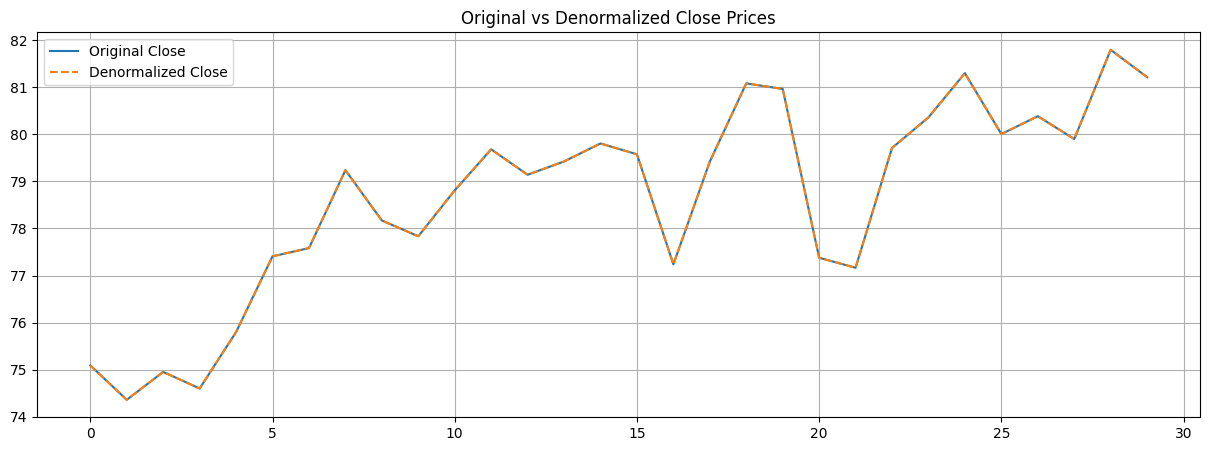

In [14]:
def denormalize_stock_data(norm_ohlc: np.ndarray, norm_volume: np.ndarray, 
                          norm_params: dict) -> tuple:
    """
    Denormalize data back to original scale
    """
    denorm_ohlc = (norm_ohlc * norm_params['ohlc_std']) + norm_params['ohlc_mean']
    denorm_volume = (norm_volume * norm_params['vol_std']) + norm_params['vol_mean']
    return denorm_ohlc, denorm_volume

# Test denormalization for one stock
ticker = 'AAPL'
data = processed_data[ticker]

print("Normalization parameters for denormalization:")
print(data['norm_params'])

original_seq = data['sequences_ohlc'][0]  # First sequence
original_vol = data['sequences_volume'][0]  # First sequence
norm_seq = data['norm_ohlc'][0]

print("Shape of norm_seq:", norm_seq.shape)
print("Shape of data['norm_volume'][0]:", data['norm_volume'][0].shape)

denorm_seq, denorm_volume = denormalize_stock_data(
    norm_seq[np.newaxis], 
    data['norm_volume'][0][np.newaxis],
    data['norm_params']
)

print("Original vs Denormalized comparison:")
print("\nOriginal sequence first 3 timesteps:")
print(original_seq[:3])
print("\nDenormalized sequence first 3 timesteps:")
print(denorm_seq[0, :3])
print("\nAbsolute difference:")
print(np.abs(original_seq[:3] - denorm_seq[0, :3]))

print("\nOriginal volume first 3 timesteps:")
print(original_vol)
print("\nDenormalized volume first 3 timesteps:")
print(denorm_volume)
print("\nAbsolute difference volume:")
print(np.abs(original_vol - denorm_volume))

# Visualize
plt.figure(figsize=(15, 5))
plt.plot(original_seq[:, 3], label='Original Close')  # Close prices
plt.plot(denorm_seq[0, :, 3], '--', label='Denormalized Close')
plt.title('Original vs Denormalized Close Prices')
plt.legend()
plt.grid(True)
plt.show()

# Minimal test example whole process

In [15]:
# Create a sample dataset with sequences from multiple tickers for testing
sample_sequences = []
sample_ticker_ids = []

for ticker in config['tickers']:
    # Get the first sequence for each ticker to keep it small for testing
    print(ticker)
    # print("sequences[ticker]['norm_ohlc']", sequences[ticker]['sequences_ohlc'])
    print("processed_data[ticker]['norm_ohlc']", processed_data[ticker]['norm_ohlc'])
    ticker_sequences = processed_data[ticker]['norm_ohlc'][:config['sequence_length']]
    ticker_id = ticker_to_id[ticker]
    
    # Append to the sample dataset
    sample_sequences.append(ticker_sequences)
    sample_ticker_ids.append(ticker_id)

# Convert lists to tensors
sample_sequences = np.concatenate(sample_sequences, axis=0)
sample_ticker_ids = torch.tensor(sample_ticker_ids)

# Display the sample data
print("Sample sequences shape:", sample_sequences.shape)
print("Sample ticker IDs:", sample_ticker_ids)
print("Sample data from multiple tickers (first sequence for each):")
print(sample_sequences)


AAPL
processed_data[ticker]['norm_ohlc'] [[[-2.0709 -2.081  -2.0382 -2.0422]
  [-2.0639 -2.0812 -2.028  -2.0648]
  [-2.0899 -2.086  -2.0571 -2.0465]
  ...
  [-1.8588 -1.901  -1.8551 -1.8929]
  [-1.8753 -1.8754 -1.8336 -1.8341]
  [-1.8542 -1.8831 -1.819  -1.8522]]

 [[-2.0639 -2.0812 -2.028  -2.0648]
  [-2.0899 -2.086  -2.0571 -2.0465]
  [-2.043  -2.0787 -2.0203 -2.0574]
  ...
  [-1.8753 -1.8754 -1.8336 -1.8341]
  [-1.8542 -1.8831 -1.819  -1.8522]
  [-1.8499 -1.885  -1.8229 -1.8515]]

 [[-2.0899 -2.086  -2.0571 -2.0465]
  [-2.043  -2.0787 -2.0203 -2.0574]
  [-2.0638 -2.0514 -2.0228 -2.0202]
  ...
  [-1.8542 -1.8831 -1.819  -1.8522]
  [-1.8499 -1.885  -1.8229 -1.8515]
  [-1.9227 -1.9331 -1.887  -1.8976]]

 ...

 [[ 1.4541  1.4098  1.4639  1.4412]
  [ 1.4588  1.4527  1.51    1.4589]
  [ 1.5121  1.4979  1.537   1.5116]
  ...
  [ 1.6861  1.6354  1.6715  1.6322]
  [ 1.6374  1.5884  1.6672  1.6151]
  [ 1.6027  1.5764  1.613   1.6182]]

 [[ 1.4588  1.4527  1.51    1.4589]
  [ 1.5121  1.4979  1

In [16]:
# Step 1: Create position vector
positions = torch.arange(config['sequence_length']).float().unsqueeze(1)  # Shape: [3, 1]
print("\nPosition vector:")
print(positions)


Position vector:
tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.]])


In [17]:
# Add transformer-specific parameters to existing config
config.update({
    'd_model': 8,      # Size of embeddings and transformer internal dim
    'n_heads': 2,       # Number of attention heads
    'dropout': 0.1,     # Dropout rate
    'n_layers': 2       # Number of transformer layers
})

print("Updated config:")
for key, value in config.items():
    print(f"{key}: {value}")

Updated config:
tickers: ['AAPL', 'MSFT', 'GOOGL']
start_date: 2020-01-01
end_date: 2024-01-01
sequence_length: 30
features: ['Open', 'High', 'Low', 'Close']
random_seed: 42
d_model: 8
n_heads: 2
dropout: 0.1
n_layers: 2


In [18]:
torch.set_printoptions(sci_mode=False, precision=4)
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

import math

# Step 2: Create frequency dividers
# Step 3: Define the frequency factor based on dimension indices
# This creates a range of frequencies from 2π to 10000 * 2π
div_term = torch.exp(torch.arange(0, config['d_model'], 2).float() * (-math.log(10000.0) / config['d_model']))
print("\nFrequency dividers:")
print(div_term)  # Shape: [4] (d_model/2)
print(div_term.shape)


Frequency dividers:
tensor([    1.0000,     0.1000,     0.0100,     0.0010])
torch.Size([4])


In [19]:
# Step 3: Calculate position * frequencies
angles = positions * div_term
print("\nAngles for each position and frequency:")
print(angles)  # Shape: [3, 4]


Angles for each position and frequency:
tensor([[    0.0000,     0.0000,     0.0000,     0.0000],
        [    1.0000,     0.1000,     0.0100,     0.0010],
        [    2.0000,     0.2000,     0.0200,     0.0020],
        [    3.0000,     0.3000,     0.0300,     0.0030],
        [    4.0000,     0.4000,     0.0400,     0.0040],
        [    5.0000,     0.5000,     0.0500,     0.0050],
        [    6.0000,     0.6000,     0.0600,     0.0060],
        [    7.0000,     0.7000,     0.0700,     0.0070],
        [    8.0000,     0.8000,     0.0800,     0.0080],
        [    9.0000,     0.9000,     0.0900,     0.0090],
        [   10.0000,     1.0000,     0.1000,     0.0100],
        [   11.0000,     1.1000,     0.1100,     0.0110],
        [   12.0000,     1.2000,     0.1200,     0.0120],
        [   13.0000,     1.3000,     0.1300,     0.0130],
        [   14.0000,     1.4000,     0.1400,     0.0140],
        [   15.0000,     1.5000,     0.1500,     0.0150],
        [   16.0000,     1.6000

In [20]:
# Step 4: Create final positional encoding
pe = torch.zeros(config['sequence_length'], config['d_model'])
print(pe)
pe[:, 0::2] = torch.sin(angles)  # Even indices
pe[:, 1::2] = torch.cos(angles)  # Odd indices
print("\nFinal positional encoding:")
print(pe)  # Shape: [3, 8]

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0

In [21]:
seed = 42
torch.manual_seed(seed)  # Seed for PyTorch
np.random.seed(seed)     # Seed for NumPy
random.seed(seed)        # Seed for Python's random library


# Step 5: Project OHLC data to d_model dimensions
weight = torch.randn(4, config['d_model']) / np.sqrt(4)  # Xavier initialization
bias = torch.zeros(config['d_model'])
print("\nProjection weight matrix:")
print(weight)

# Convert sample data to tensor
# x = torch.FloatTensor(sample_sequences)  # Shape: [2, 3, 4]
# x = torch.FloatTensor(processed_data[ticker]['norm_ohlc']) 
# print("\nInput shape:", x.shape)

# # Project OHLC to d_model dimensions
# projected = torch.matmul(x, weight) + bias
# print("\nProjected data (first sequence):")
# print(projected[0])  # Shape: [3, 8]

# Concatenate normalized OHLC sequences from all tickers in processed_data
all_sequences = np.concatenate([processed_data[ticker]['norm_ohlc'] for ticker in config['tickers']], axis=0)

# Convert to a tensor
x = torch.FloatTensor(all_sequences)  # Shape: [total_sequences, sequence_length, num_features]
print("\nInput shape:", x.shape)

# Apply the projection
projected = torch.matmul(x, weight) + bias  # Adjust `weight` if needed to match dimensions
print("\nProjected data (first sequence across all tickers):")
print(projected[0])  # First sequence in the concatenated data



Projection weight matrix:
tensor([[ 0.9635,  0.7436,  0.4504, -1.0528,  0.3392, -0.6173, -0.0215, -0.8023],
        [-0.3761,  0.8244, -0.1962, -0.7018, -0.3639, -0.2797, -0.3844,  0.3812],
        [ 0.8212, -0.0798, -0.2487,  0.2198, -0.3791,  0.5392,  0.4004,  0.8403],
        [ 0.6396,  0.6482,  0.3052,  0.6674, -0.1158,  0.0209, -0.1258,  0.4299]])

Input shape: torch.Size([2931, 30, 4])

Projected data (first sequence across all tickers):
tensor([[-4.1924, -4.4167, -0.6407,  1.8298,  1.0640,  0.7189,  0.2854, -1.7224],
        [-4.1917, -4.4271, -0.6470,  1.8096,  1.0652,  0.7196,  0.2922, -1.7293],
        [-4.2272, -4.4362, -0.6449,  1.8463,  1.0670,  0.7217,  0.2806, -1.7269],
        [-4.1615, -4.4053, -0.6377,  1.7926,  1.0676,  0.7103,  0.2929, -1.7355],
        [-4.1700, -4.3739, -0.6404,  1.8195,  1.0473,  0.7149,  0.2772, -1.6945],
        [-4.0224, -4.2509, -0.6166,  1.7535,  1.0245,  0.6927,  0.2796, -1.6590],
        [-3.9873, -4.2150, -0.6106,  1.7211,  1.0204,  0.68

In [22]:
# Starting with our projected data from last cell
print("Projected data shape:", projected.shape)
print("\nProjected data (first sequence):")
print(projected[0])
print("\nPositional encoding shape:", pe.shape)
print("\nPositional encoding:")
print(pe)

Projected data shape: torch.Size([2931, 30, 8])

Projected data (first sequence):
tensor([[-4.1924, -4.4167, -0.6407,  1.8298,  1.0640,  0.7189,  0.2854, -1.7224],
        [-4.1917, -4.4271, -0.6470,  1.8096,  1.0652,  0.7196,  0.2922, -1.7293],
        [-4.2272, -4.4362, -0.6449,  1.8463,  1.0670,  0.7217,  0.2806, -1.7269],
        [-4.1615, -4.4053, -0.6377,  1.7926,  1.0676,  0.7103,  0.2929, -1.7355],
        [-4.1700, -4.3739, -0.6404,  1.8195,  1.0473,  0.7149,  0.2772, -1.6945],
        [-4.0224, -4.2509, -0.6166,  1.7535,  1.0245,  0.6927,  0.2796, -1.6590],
        [-3.9873, -4.2150, -0.6106,  1.7211,  1.0204,  0.6805,  0.2781, -1.6576],
        [-3.9409, -4.1495, -0.6035,  1.7280,  0.9962,  0.6792,  0.2674, -1.6100],
        [-3.9192, -4.1392, -0.5987,  1.6636,  1.0089,  0.6575,  0.2725, -1.6476],
        [-3.9728, -4.1855, -0.6106,  1.7030,  1.0109,  0.6740,  0.2726, -1.6452],
        [-3.9249, -4.1562, -0.6005,  1.7122,  1.0040,  0.6765,  0.2758, -1.6258],
        [-3.8778

In [23]:
# Add positional encoding to projected data
data_with_pos = projected + pe
print("Data after adding positional encoding:")
print("\nFirst sequence:")
print(data_with_pos[0])

# Show the change positional encoding made
print("\nDifference from original (what positional encoding added):")
print(data_with_pos[0] - projected[0])

Data after adding positional encoding:

First sequence:
tensor([[-4.1924, -3.4167, -0.6407,  2.8298,  1.0640,  1.7189,  0.2854, -0.7224],
        [-3.3502, -3.8868, -0.5471,  2.8046,  1.0752,  1.7196,  0.2932, -0.7293],
        [-3.3179, -4.8523, -0.4462,  2.8263,  1.0870,  1.7215,  0.2826, -0.7269],
        [-4.0204, -5.3953, -0.3422,  2.7479,  1.0976,  1.7099,  0.2959, -0.7355],
        [-4.9268, -5.0275, -0.2510,  2.7406,  1.0873,  1.7141,  0.2812, -0.6945],
        [-4.9814, -3.9672, -0.1372,  2.6311,  1.0745,  1.6914,  0.2846, -0.6590],
        [-4.2667, -3.2548, -0.0459,  2.5464,  1.0803,  1.6787,  0.2841, -0.6576],
        [-3.2839, -3.3956,  0.0407,  2.4928,  1.0662,  1.6768,  0.2744, -0.6101],
        [-2.9299, -4.2847,  0.1186,  2.3603,  1.0889,  1.6543,  0.2805, -0.6477],
        [-3.5607, -5.0966,  0.1727,  2.3246,  1.1008,  1.6700,  0.2816, -0.6452],
        [-4.4689, -4.9952,  0.2409,  2.2525,  1.1038,  1.6715,  0.2858, -0.6258],
        [-4.8778, -4.1012,  0.2981,  2.150

In [24]:
# Add transformer-specific parameters to existing config
config.update({
    'd_model': 8,      # Size of embeddings and transformer internal dim
    'n_heads': 2,       # Number of attention heads
    'dropout': 0.1,     # Dropout rate
    'n_layers': 2,       # Number of transformer layers
    'batch_size': len(data_with_pos) 
})

print("Updated config:")
for key, value in config.items():
    print(f"{key}: {value}")

Updated config:
tickers: ['AAPL', 'MSFT', 'GOOGL']
start_date: 2020-01-01
end_date: 2024-01-01
sequence_length: 30
features: ['Open', 'High', 'Low', 'Close']
random_seed: 42
d_model: 8
n_heads: 2
dropout: 0.1
n_layers: 2
batch_size: 2931


In [25]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 30,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 42,
 'd_model': 8,
 'n_heads': 2,
 'dropout': 0.1,
 'n_layers': 2,
 'batch_size': 2931}

### Attention Parameters Explanation:

In [26]:
# Retrieve attention parameters from config
d_k = config['d_model'] //  config['n_heads']     # Dimension per head, derived from config values

# Assuming `data_with_pos` is defined with a shape [batch_size, seq_length, d_model]
print("Input data shape:", data_with_pos.shape)
print("\nInput data (first sequence):")
print(data_with_pos[0])

print("\nAttention dimensions (from config):")
print(f"d_model (total dimension): {config['d_model']}")
print(f"n_heads (number of attention heads): {config['n_heads']}")
print(f"d_k (dimension per head): {d_k}")

Input data shape: torch.Size([2931, 30, 8])

Input data (first sequence):
tensor([[-4.1924, -3.4167, -0.6407,  2.8298,  1.0640,  1.7189,  0.2854, -0.7224],
        [-3.3502, -3.8868, -0.5471,  2.8046,  1.0752,  1.7196,  0.2932, -0.7293],
        [-3.3179, -4.8523, -0.4462,  2.8263,  1.0870,  1.7215,  0.2826, -0.7269],
        [-4.0204, -5.3953, -0.3422,  2.7479,  1.0976,  1.7099,  0.2959, -0.7355],
        [-4.9268, -5.0275, -0.2510,  2.7406,  1.0873,  1.7141,  0.2812, -0.6945],
        [-4.9814, -3.9672, -0.1372,  2.6311,  1.0745,  1.6914,  0.2846, -0.6590],
        [-4.2667, -3.2548, -0.0459,  2.5464,  1.0803,  1.6787,  0.2841, -0.6576],
        [-3.2839, -3.3956,  0.0407,  2.4928,  1.0662,  1.6768,  0.2744, -0.6101],
        [-2.9299, -4.2847,  0.1186,  2.3603,  1.0889,  1.6543,  0.2805, -0.6477],
        [-3.5607, -5.0966,  0.1727,  2.3246,  1.1008,  1.6700,  0.2816, -0.6452],
        [-4.4689, -4.9952,  0.2409,  2.2525,  1.1038,  1.6715,  0.2858, -0.6258],
        [-4.8778, -4.101

Why these numbers?
- n_heads=2: We want the model to look at data from two different perspectives
  Head 1 might focus on short-term patterns
  Head 2 might focus on longer-term patterns
- d_k=4: Each head gets half of the total dimensions (8/2)
  This allows each head to have enough dimensions to capture patterns
  while keeping computations manageable

### Create Query (Q) projection

In [27]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 30,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 42,
 'd_model': 8,
 'n_heads': 2,
 'dropout': 0.1,
 'n_layers': 2,
 'batch_size': 2931}

In [28]:
# Set seed for reproducibility
seed = config['random_seed']
torch.manual_seed(seed)  # Seed for PyTorch
np.random.seed(seed)     # Seed for NumPy
random.seed(seed)        # Seed for Python's random library

# Initialize Q projection matrix using Xavier initialization
Q_weight = torch.randn(config['d_model'], config['d_model']) / np.sqrt(config['d_model'])
print("Q projection matrix shape:", Q_weight.shape)
print("Q projection matrix:")
print(Q_weight)

# Assuming data_with_pos has shape [batch_size, seq_length, d_model] = [3, 3, 8]
seq_length = config['sequence_length']  # 3
n_heads = config['n_heads']             # 2
d_model = config['d_model']             # 8
batch_size = config['batch_size']
d_k = d_model // n_heads                # 4

# Project data to get Q
Q = torch.matmul(data_with_pos, Q_weight)
print("\nQ shape before reshape:", Q.shape)  # Expected shape: [3, 3, 8]
print("Q values (first sequence):")
print(Q[0])

# Correct reshaping for multi-head attention
# Shape should be [batch_size, seq_len, d_model] -> [batch_size, n_heads, seq_len, d_k]
Q = Q.view(batch_size, seq_length, n_heads, d_k).transpose(1, 2)
print("\nQ shape after reshape for multi-head:", Q.shape)  # Expected shape: [3, 2, 3, 4]
print("Q values (first sequence, first head):")
print(Q[0, 0])


Q projection matrix shape: torch.Size([8, 8])
Q projection matrix:
tensor([[ 0.6813,  0.5258,  0.3185, -0.7444,  0.2399, -0.4365, -0.0152, -0.5673],
        [-0.2659,  0.5829, -0.1388, -0.4963, -0.2573, -0.1978, -0.2718,  0.2696],
        [ 0.5806, -0.0564, -0.1759,  0.1554, -0.2680,  0.3812,  0.2831,  0.5942],
        [ 0.4522,  0.4584,  0.2158,  0.4719, -0.0819,  0.0148, -0.0889,  0.3040],
        [-0.4896, -0.3080, -0.0790,  0.6072,  0.1127, -0.1501,  0.1081, -0.2739],
        [-0.5507,  0.3520, -0.3111, -0.2125, -0.4505,  0.7505, -0.4365, -0.1725],
        [-0.3231, -0.2327,  0.0276,  0.1859, -0.1725,  0.4212, -0.2878, -0.2602],
        [-0.4961,  0.0127, -0.0224,  0.2389, -0.0346,  0.6522, -0.4188,  0.4892]])

Q shape before reshape: torch.Size([2931, 30, 8])
Q values (first sequence):
tensor([[-2.2411, -2.6612, -0.7321,  6.2134, -0.8649,  3.0826,  0.1446,  0.9215],
        [-1.5044, -2.5143, -0.4213,  5.8289, -0.5651,  2.8409,  0.2898,  0.3563],
        [-1.1618, -3.0564, -0.2920

## Create Key (K) and Value (V) projections

In [29]:
# Initialize K and V projection matrices (similar to Q)
K_weight = torch.randn(d_model, d_model) / np.sqrt(d_model)  # Same initialization as Q
V_weight = torch.randn(d_model, d_model) / np.sqrt(d_model)

print("Original data_with_pos shape:", data_with_pos.shape)
print("\nK projection matrix:")
print(K_weight)
print("\nV projection matrix:")
print(V_weight)

# Project data to get K and V
K = torch.matmul(data_with_pos, K_weight)
V = torch.matmul(data_with_pos, V_weight)

print("\nK and V shapes before reshape:", K.shape, V.shape)
print("\nK values (first sequence):")
print(K[0])
print("\nV values (first sequence):")
print(V[0])

Original data_with_pos shape: torch.Size([2931, 30, 8])

K projection matrix:
tensor([[     0.5109,      0.3028,      0.7842,      0.1850,      0.1226,
             -0.0698,     -0.3729,      0.4518],
        [    -0.0609,      0.1852,      0.0200,      0.1507,      0.2033,
             -0.2269,     -0.7801,     -0.2654],
        [     0.0038,     -0.1198,     -0.4740,     -0.2070,      0.1896,
              0.1855,      0.4035,      0.0183],
        [     0.2630,     -0.1703,     -0.3710,      0.2135,     -0.6089,
             -0.2927,      0.4719,      0.1710],
        [    -0.8873,      0.1725,      0.2774,      0.0101,      0.2265,
              0.2062,      0.3772,     -0.1592],
        [    -0.0655,      0.2661,      0.1431,      0.0631,      0.0937,
              0.4501,     -0.0005,     -0.1073],
        [    -0.5151,     -0.0362,     -0.2118,      0.1687,      0.2567,
              0.0322,     -0.1376,      0.1866],
        [    -0.0045,      0.0851,      0.0469,      0.2702, 

### Reshape K and V for multi-head attention

In [30]:
# Reshape K and V same as Q
# [batch_size, seq_len, d_model] -> [batch_size, n_heads, seq_len, d_k]
K = K.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)
V = V.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)

print("After reshape:")
print("K shape:", K.shape)
print("V shape:", V.shape)
print("\nK values (first sequence, first head):")
print(K[0, 0])
print("\nV values (first sequence, first head):")
print(V[0, 0])

After reshape:
K shape: torch.Size([2931, 2, 30, 4])
V shape: torch.Size([2931, 2, 30, 4])

K values (first sequence, first head):
tensor([[-2.3926, -1.7380, -3.6556, -0.5815],
        [-1.9539, -1.5757, -3.0383, -0.5216],
        [-1.8777, -1.7574, -3.0823, -0.6783],
        [-2.2392, -2.0722, -3.6662, -0.9291],
        [-2.7100, -2.2849, -4.4074, -1.0530],
        [-2.8199, -2.1054, -4.4482, -0.9416],
        [-2.5241, -1.7558, -3.8853, -0.7395],
        [-2.0097, -1.4841, -3.1385, -0.5973],
        [-1.8309, -1.5338, -2.8664, -0.7206],
        [-2.1252, -1.8692, -3.3843, -0.9765],
        [-2.6190, -2.1189, -4.0990, -1.1526],
        [-2.9043, -2.0671, -4.3913, -1.1219],
        [-2.7580, -1.7568, -3.9852, -0.9417],
        [-2.2958, -1.4315, -3.1934, -0.7759],
        [-1.9921, -1.3908, -2.7444, -0.8128],
        [-2.1410, -1.6297, -2.9703, -1.0352],
        [-2.7496, -2.0200, -3.8170, -1.3181],
        [-3.0913, -2.0328, -4.2248, -1.3083],
        [-3.0013, -1.6985, -3.8563, -1.11

### Compute attention scores

In [31]:
import torch.nn.functional as F

# Compute attention scores: (Q * K^T) / sqrt(d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
# Q: [2, 2, 3, 4] @ K^T: [2, 2, 4, 3] -> scores: [2, 2, 3, 3]
# Divide by sqrt(d_k) for stable gradients

print("Attention scores shape:", scores.shape)
print("\nAttention scores (first sequence, first head):")
print(scores[0, 0])  # 3x3 matrix showing how each position attends to others

# Apply softmax to get attention weights
attention_weights = F.softmax(scores, dim=-1)
print("\nAttention weights (first sequence, first head):")
print(attention_weights[0, 0])

Attention scores shape: torch.Size([2931, 2, 30, 30])

Attention scores (first sequence, first head):
tensor([[4.5255, 3.7778, 3.4635, 3.7222, 4.4191, 4.6643, 4.2897, 3.5200, 2.9031,
         3.0737, 3.6738, 4.1270, 3.9615, 3.2358, 2.5625, 2.4390, 3.0714, 3.6510,
         3.5740, 3.0455, 2.2519, 2.2099, 2.5222, 3.1030, 3.4136, 3.0204, 2.4001,
         1.8882, 2.2179, 2.9092],
        [3.0601, 2.5704, 2.2941, 2.3540, 2.7704, 2.9606, 2.7693, 2.2978, 1.8091,
         1.8153, 2.1379, 2.4385, 2.3781, 1.9378, 1.4562, 1.2680, 1.5703, 1.9578,
         1.9585, 1.6725, 1.0858, 1.0130, 1.1452, 1.4902, 1.7576, 1.5626, 1.2027,
         0.8035, 0.9688, 1.3803],
        [2.7436, 2.3395, 2.0845, 2.0691, 2.3845, 2.5317, 2.3818, 2.0076, 1.5506,
         1.5016, 1.7183, 1.9445, 1.8952, 1.5374, 1.1169, 0.8992, 1.0795, 1.3880,
         1.3845, 1.1704, 0.6306, 0.5694, 0.6344, 0.8781, 1.1185, 0.9741, 0.7126,
         0.3461, 0.4705, 0.7793],
        [3.8561, 3.2922, 3.0353, 3.1465, 3.6314, 3.7764, 3.4801, 2.

### Apply attention weights to values

In [32]:
# Apply attention weights to values
# attention_weights: [2, 2, 3, 3] @ V: [2, 2, 3, 4] -> [2, 2, 3, 4]
attended_values = torch.matmul(attention_weights, V)

print("Attended values shape:", attended_values.shape)
print("\nAttended values (first sequence, first head):")
print(attended_values[0, 0])

Attended values shape: torch.Size([2931, 2, 30, 4])

Attended values (first sequence, first head):
tensor([[-5.8261,  0.4377,  5.5038,  1.4111],
        [-5.7408,  0.4794,  5.4405,  1.3543],
        [-5.7022,  0.5093,  5.4106,  1.3567],
        [-5.7529,  0.4955,  5.4486,  1.4130],
        [-5.8391,  0.4566,  5.5136,  1.4746],
        [-5.8816,  0.4300,  5.5487,  1.4796],
        [-5.8513,  0.4344,  5.5275,  1.4333],
        [-5.7686,  0.4700,  5.4666,  1.3663],
        [-5.7222,  0.5024,  5.4345,  1.3493],
        [-5.7572,  0.4975,  5.4599,  1.4005],
        [-5.8451,  0.4603,  5.5271,  1.4660],
        [-5.9120,  0.4251,  5.5805,  1.4938],
        [-5.9102,  0.4167,  5.5816,  1.4658],
        [-5.8455,  0.4411,  5.5346,  1.4033],
        [-5.7838,  0.4764,  5.4902,  1.3695],
        [-5.8022,  0.4794,  5.5061,  1.4012],
        [-5.8885,  0.4478,  5.5711,  1.4781],
        [-5.9645,  0.4095,  5.6314,  1.5148],
        [-5.9836,  0.3903,  5.6497,  1.4937],
        [-5.9363,  0.4033, 

### Concatenate heads and project to output

In [33]:
# Reshape back using config dimensions
attended_values = attended_values.transpose(1, 2).contiguous().view(
    config['batch_size'], 
    config['sequence_length'], 
    config['d_model']
)
print(attended_values.shape)

# Final projection matrix using config dimensions
output_projection = torch.randn(config['d_model'], len(config['features'])) / np.sqrt(config['d_model'])
final_attention_output = torch.matmul(attended_values, output_projection)

print("Final attention output shape:", final_attention_output.shape)
print("\nFinal attention output (first sequence):")
print(final_attention_output[0])

torch.Size([2931, 30, 8])
Final attention output shape: torch.Size([2931, 30, 4])

Final attention output (first sequence):
tensor([[-2.4441,  6.6511, -1.8104,  2.3980],
        [-2.4347,  6.5456, -1.7956,  2.4108],
        [-2.4434,  6.5060, -1.7889,  2.4432],
        [-2.4624,  6.5735, -1.7993,  2.4627],
        [-2.4722,  6.6840, -1.8118,  2.4602],
        [-2.4621,  6.7357, -1.8137,  2.4406],
        [-2.4430,  6.6939, -1.8045,  2.4251],
        [-2.4296,  6.5888, -1.7931,  2.4253],
        [-2.4368,  6.5332, -1.7886,  2.4489],
        [-2.4580,  6.5812, -1.7983,  2.4709],
        [-2.4734,  6.6917, -1.8142,  2.4705],
        [-2.4715,  6.7738, -1.8223,  2.4528],
        [-2.4574,  6.7663, -1.8197,  2.4324],
        [-2.4444,  6.6792, -1.8121,  2.4238],
        [-2.4471,  6.6021, -1.8071,  2.4385],
        [-2.4678,  6.6260, -1.8184,  2.4550],
        [-2.4894,  6.7352, -1.8327,  2.4662],
        [-2.4936,  6.8285, -1.8479,  2.4457],
        [-2.4810,  6.8453, -1.8514,  2.4165],
  

### Project attention output to OHLC

In [34]:
final_attention_output.shape

torch.Size([2931, 30, 4])

In [35]:
# Start from our final_attention_output tensor:
print("Starting with final_attention_output:")
print("Shape:", final_attention_output.shape)  # [batch_size, seq_len, num_features]
print("First sequence values:")
print(final_attention_output[0])

# Create projection matrix using same formula as before
ohlc_projection = torch.randn(config['d_model'], len(config['features'])) / np.sqrt(config['d_model'])
print("\nOHLC projection matrix:")
print("Shape:", ohlc_projection.shape)
print("Values:")
print(ohlc_projection)

# The error is because final_attention_output already has 4 features
# We don't need another projection since we're already at the right dimension
print("\nFinal attention output already has correct feature dimension (4):")
print("Features in config:", config['features'])  # ['Open', 'High', 'Low', 'Close']
print("Features in tensor:", final_attention_output.shape[-1])  # 4

# Therefore we can use final_attention_output directly
generated_ohlc = final_attention_output

print("\nGenerated OHLC shape:", generated_ohlc.shape)
print("Generated OHLC first sequence:")
print(generated_ohlc[0])

Starting with final_attention_output:
Shape: torch.Size([2931, 30, 4])
First sequence values:
tensor([[-2.4441,  6.6511, -1.8104,  2.3980],
        [-2.4347,  6.5456, -1.7956,  2.4108],
        [-2.4434,  6.5060, -1.7889,  2.4432],
        [-2.4624,  6.5735, -1.7993,  2.4627],
        [-2.4722,  6.6840, -1.8118,  2.4602],
        [-2.4621,  6.7357, -1.8137,  2.4406],
        [-2.4430,  6.6939, -1.8045,  2.4251],
        [-2.4296,  6.5888, -1.7931,  2.4253],
        [-2.4368,  6.5332, -1.7886,  2.4489],
        [-2.4580,  6.5812, -1.7983,  2.4709],
        [-2.4734,  6.6917, -1.8142,  2.4705],
        [-2.4715,  6.7738, -1.8223,  2.4528],
        [-2.4574,  6.7663, -1.8197,  2.4324],
        [-2.4444,  6.6792, -1.8121,  2.4238],
        [-2.4471,  6.6021, -1.8071,  2.4385],
        [-2.4678,  6.6260, -1.8184,  2.4550],
        [-2.4894,  6.7352, -1.8327,  2.4662],
        [-2.4936,  6.8285, -1.8479,  2.4457],
        [-2.4810,  6.8453, -1.8514,  2.4165],
        [-2.4681,  6.7776, -1.84

We use a final linear projection to transform the output of the attention mechanism back to the original OHLC dimensions.
This generates synthetic OHLC data in the normalized space.

In [36]:
projection_layer = torch.randn(4, config['d_model']) / np.sqrt(4)  # Projects from 4 to 8 features

# Project the OHLC data (all_sequences) to match d_model dimensions
all_sequences_projected = torch.matmul(torch.FloatTensor(all_sequences), projection_layer)

print("Projected all_sequences shape:", all_sequences_projected.shape)  # Expected shape: [batch_size, seq_len, d_model]


Projected all_sequences shape: torch.Size([2931, 30, 8])


In [37]:
import torch
import torch.nn.functional as F
import numpy as np

torch.autograd.set_detect_anomaly(True)  # Enable anomaly detection

# Define constants for dimensions
d_model = config['d_model']
d_k = d_model // config['n_heads']
batch_size = config['batch_size']
sequence_length = config['sequence_length']

# Define learnable parameters
projection_layer = torch.nn.Parameter(torch.randn(4, d_model) / np.sqrt(4))  # Projects from 4 to 8 features
discriminator_projection = torch.nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
Q_weight = torch.nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
K_weight = torch.nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
V_weight = torch.nn.Parameter(torch.randn(d_model, d_model) / np.sqrt(d_model))
disc_projection = torch.nn.Parameter(torch.randn(d_model, 1) / np.sqrt(d_model))

# Initialize optimizers
optimizer_d = torch.optim.Adam([discriminator_projection, disc_projection, Q_weight, K_weight, V_weight], lr=0.0001)
optimizer_g = torch.optim.Adam([Q_weight, K_weight, V_weight], lr=0.0001)

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    # Sample a batch of real and fake sequences
    real_seq = all_sequences_projected[:batch_size]
    fake_seq = torch.randn(batch_size, sequence_length, d_model, requires_grad=True)

    # Apply discriminator projection to real and fake sequences
    real_disc_input = torch.matmul(real_seq, discriminator_projection.clone())
    fake_disc_input = torch.matmul(fake_seq, discriminator_projection.clone())

    # Compute attention for real and fake sequences
    def apply_attention(input_seq):
        Q = torch.matmul(input_seq, Q_weight.clone()).view(batch_size, sequence_length, config['n_heads'], d_k).transpose(1, 2)
        K = torch.matmul(input_seq, K_weight.clone()).view(batch_size, sequence_length, config['n_heads'], d_k).transpose(1, 2)
        V = torch.matmul(input_seq, V_weight.clone()).view(batch_size, sequence_length, config['n_heads'], d_k).transpose(1, 2)
        
        # Process attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        attention_weights = F.softmax(scores, dim=-1)
        attended = torch.matmul(attention_weights, V).transpose(1, 2).contiguous().view(batch_size, sequence_length, d_model)
        return attended

    real_attended = apply_attention(real_disc_input)
    fake_attended = apply_attention(fake_disc_input)

    # Final discriminator output with sigmoid activation
    d_real = torch.sigmoid(torch.matmul(real_attended.mean(dim=1), disc_projection.clone()))
    d_fake = torch.sigmoid(torch.matmul(fake_attended.mean(dim=1), disc_projection.clone()))

    # Compute discriminator and generator losses
    d_loss = -torch.mean(torch.log(d_real + 1e-8) + torch.log(1 - d_fake + 1e-8))
    g_loss = -torch.mean(torch.log(d_fake + 1e-8))

    # Update discriminator
    optimizer_d.zero_grad()
    d_loss.backward(retain_graph=True)  # Ensure no in-place ops are performed before .backward()
    optimizer_d.step()

    # Update generator
    optimizer_g.zero_grad()
    g_loss.backward()  # Ensure no in-place ops are performed before .backward()
    optimizer_g.step()

    # Print progress
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{n_epochs} - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")


Epoch 0/100 - D Loss: 1.4703, G Loss: 0.6996
Epoch 10/100 - D Loss: 1.4687, G Loss: 0.6967
Epoch 20/100 - D Loss: 1.4652, G Loss: 0.6951
Epoch 30/100 - D Loss: 1.4620, G Loss: 0.6937
Epoch 40/100 - D Loss: 1.4545, G Loss: 0.6967
Epoch 50/100 - D Loss: 1.4488, G Loss: 0.6976
Epoch 60/100 - D Loss: 1.4459, G Loss: 0.6966
Epoch 70/100 - D Loss: 1.4409, G Loss: 0.6978
Epoch 80/100 - D Loss: 1.4387, G Loss: 0.6963
Epoch 90/100 - D Loss: 1.4369, G Loss: 0.6945


In [38]:
# def process_attention(Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, d_k: int) -> torch.Tensor:
#     """
#     Perform multi-head attention.

#     Args:
#     - Q (torch.Tensor): Query tensor of shape [batch_size, n_heads, seq_length, d_k].
#     - K (torch.Tensor): Key tensor of shape [batch_size, n_heads, seq_length, d_k].
#     - V (torch.Tensor): Value tensor of shape [batch_size, n_heads, seq_length, d_k].
#     - d_k (int): Dimensionality of each head (d_model / n_heads).

#     Returns:
#     - torch.Tensor: Output of attention with shape [batch_size, seq_length, d_model].
#     """
#     # Compute attention scores
#     scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    
#     # Apply softmax to get attention weights
#     attention_weights = F.softmax(scores, dim=-1)
    
#     # Apply attention weights to the values
#     attended = torch.matmul(attention_weights, V)
    
#     # Reshape back to [batch_size, seq_length, d_model]
#     attended = attended.transpose(1, 2).contiguous().view(
#         Q.size(0), Q.size(2), -1  # batch_size, seq_length, d_model
#     )
    
#     return attended


In [39]:
config

{'tickers': ['AAPL', 'MSFT', 'GOOGL'],
 'start_date': '2020-01-01',
 'end_date': '2024-01-01',
 'sequence_length': 30,
 'features': ['Open', 'High', 'Low', 'Close'],
 'random_seed': 42,
 'd_model': 8,
 'n_heads': 2,
 'dropout': 0.1,
 'n_layers': 2,
 'batch_size': 2931}

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridGenerator(nn.Module):
    def __init__(self, seq_len=20, d_model=8, latent_dim=32, n_heads=1, n_layers=1):
        super(HybridGenerator, self).__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.d_model = d_model
        
        # Transformer for trend generation
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=64, dropout=0.1)
        self.transformer = nn.TransformerEncoder(self.transformer_encoder_layer, num_layers=n_layers)
        
        # Trend projection layer
        self.trend_projection = nn.Linear(d_model, 1)
        
        # MLP for noise and volume generation
        self.noise_layer = nn.Sequential(
            nn.Linear(latent_dim, seq_len),
            nn.Tanh()
        )
        self.volume_layer = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, seq_len),
            nn.Tanh()
        )

    def forward(self, z):
        batch_size = z.size(0)
        
        # Generate trend component using the transformer
        trend_input = torch.randn(batch_size, self.seq_len, self.d_model)
        trend_output = self.transformer(trend_input)  # Shape: [batch_size, seq_len, d_model]
        trend = torch.cumsum(self.trend_projection(trend_output).squeeze(-1), dim=1).unsqueeze(-1)  # Cumulative sum for trend

        # Generate noise component
        noise = 0.1 * self.noise_layer(z).unsqueeze(-1)

        # Base price combining trend and noise
        base_price = trend + noise
        
        # Generate OHLC from base price with explicit constraints
        open_price = base_price
        high_price = base_price + torch.abs(noise)
        low_price = base_price - torch.abs(noise)
        close_price = base_price + 0.5 * noise

        # Generate volume using MLP
        volume = self.volume_layer(z).unsqueeze(-1) * 5
        
        return torch.cat([open_price, high_price, low_price, close_price, volume], dim=2)
    
    
class Discriminator(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim * config['sequence_length'], hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)



In [41]:
def price_consistency_loss(generated_data):
    """
    Enforces realistic relationships between OHLC prices in generated data.
    """
    # Open, High, Low, Close prices
    open_price = generated_data[:, :, 0]
    high_price = generated_data[:, :, 1]
    low_price = generated_data[:, :, 2]
    close_price = generated_data[:, :, 3]
    
    # Enforce High >= Open and High >= Close
    high_consistency = F.relu(open_price - high_price).mean() + F.relu(close_price - high_price).mean()
    
    # Enforce Low <= Open and Low <= Close
    low_consistency = F.relu(low_price - open_price).mean() + F.relu(low_price - close_price).mean()
    
    # Enforce non-negative ranges
    range_consistency = F.relu(high_price - low_price).mean()
    
    return high_consistency + low_consistency + range_consistency


In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# Define consistency loss function
def price_consistency_loss(generated_data):
    """
    Enforces realistic relationships between OHLC prices in generated data.
    """
    open_price = generated_data[:, :, 0]
    high_price = generated_data[:, :, 1]
    low_price = generated_data[:, :, 2]
    close_price = generated_data[:, :, 3]
    
    # Enforce High >= Open and High >= Close
    high_consistency = F.relu(open_price - high_price).mean() + F.relu(close_price - high_price).mean()
    
    # Enforce Low <= Open and Low <= Close
    low_consistency = F.relu(low_price - open_price).mean() + F.relu(low_price - close_price).mean()
    
    # Enforce non-negative ranges
    range_consistency = F.relu(high_price - low_price).mean()
    
    return high_consistency + low_consistency + range_consistency

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define Discriminator model with dynamic input size
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# Calculate input dimension for the Discriminator
seq_len = config['sequence_length']
num_features = config['d_model']  # Matches the output features of the generator
input_dim = seq_len * num_features  # Flattened input dimension for discriminator

# Initialize generator and discriminator models
generator = HybridGenerator(seq_len=seq_len, d_model=config['d_model'], latent_dim=32, n_heads=config['n_heads'], n_layers=config['n_layers'])
discriminator = Discriminator(input_dim=input_dim)  # Pass input_dim here

# Define optimizers for generator and discriminator
optimizer_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    generator.train()
    discriminator.train()
    
    # Sample latent vector for generator
    z = torch.randn(config['batch_size'], generator.latent_dim)
    
    # Generate fake data
    fake_data = generator(z)
    
    # Prepare real data batch from processed sequences
    real_data = torch.FloatTensor(all_sequences_projected[:config['batch_size']])
    
    # Flatten data for discriminator
    real_data_flat = real_data.view(config['batch_size'], -1)  # Flatten to [batch_size, seq_len * num_features]
    fake_data_flat = fake_data.view(config['batch_size'], -1)  # Flatten to [batch_size, seq_len * num_features]
    
    # Discriminator step
    optimizer_d.zero_grad()
    real_predictions = discriminator(real_data_flat)
    fake_predictions = discriminator(fake_data_flat.detach())
    d_loss = (torch.mean((real_predictions - 1)**2) + torch.mean(fake_predictions**2)) / 2  # Least-squares loss
    d_loss.backward()
    optimizer_d.step()
    
    # Generator step
    optimizer_g.zero_grad()
    fake_predictions = discriminator(fake_data_flat)
    g_loss_main = torch.mean((fake_predictions - 1)**2)  # Least-squares loss
    g_loss_consistency = price_consistency_loss(fake_data)
    g_loss = g_loss_main + 0.1 * g_loss_consistency  # Weighted sum of main and consistency losses
    g_loss.backward()
    optimizer_g.step()

    # Print progress
    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{n_epochs}] D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

# Continue with evaluation and plotting as per your original code...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (2931x150 and 240x128)


Metrics for AAPL - MAE: 1.0269, RMSE: 1.3259


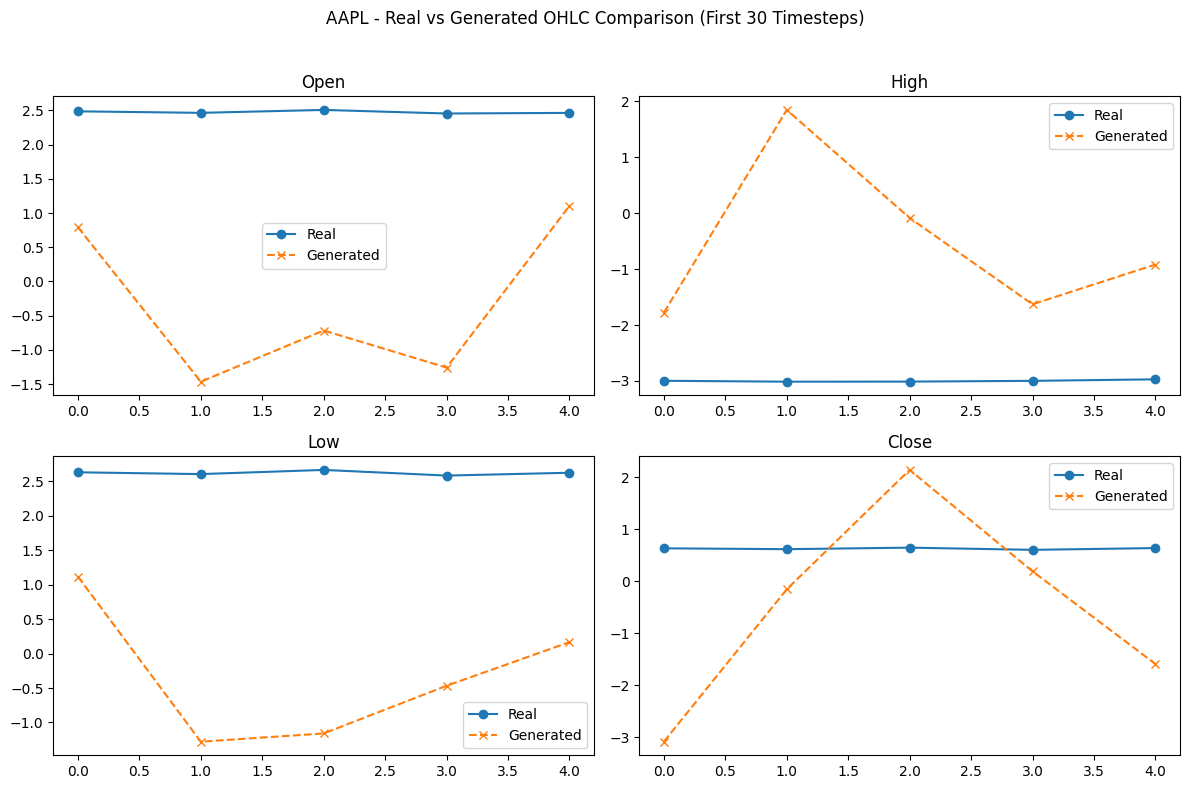


Metrics for MSFT - MAE: 1.0390, RMSE: 1.3333


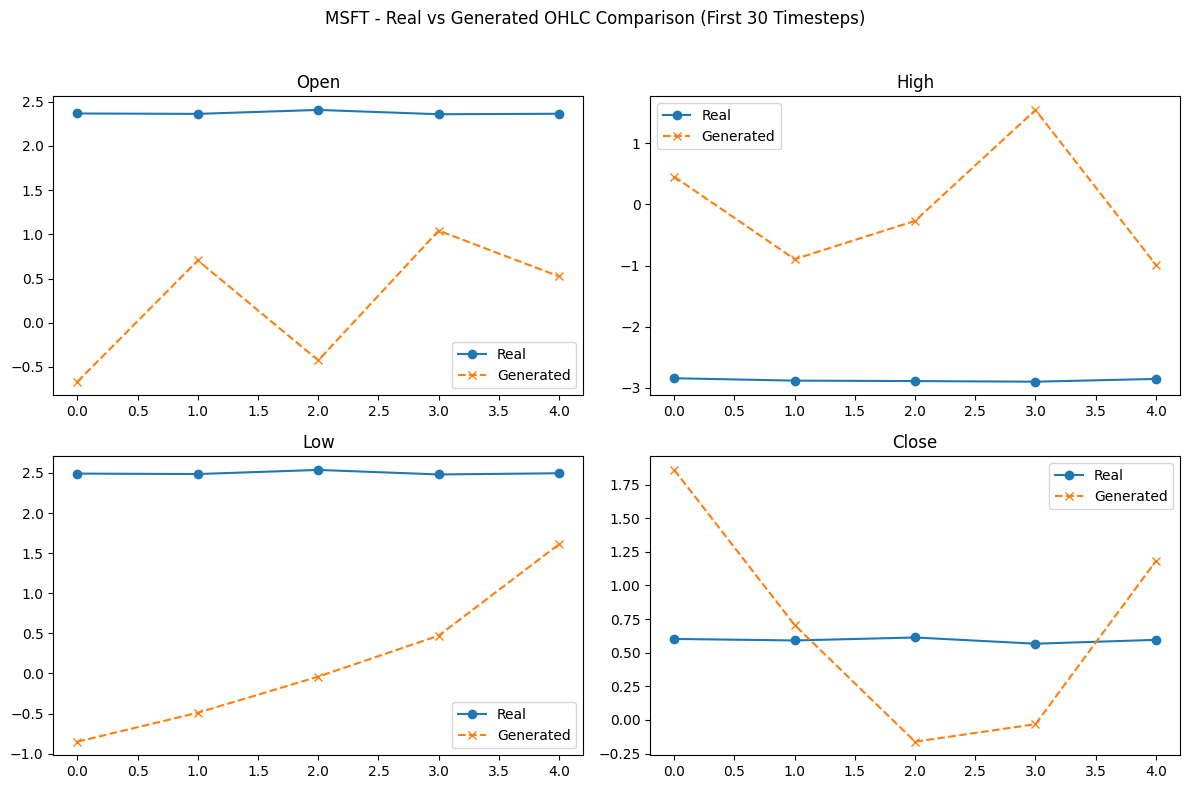


Metrics for GOOGL - MAE: 1.0471, RMSE: 1.3318


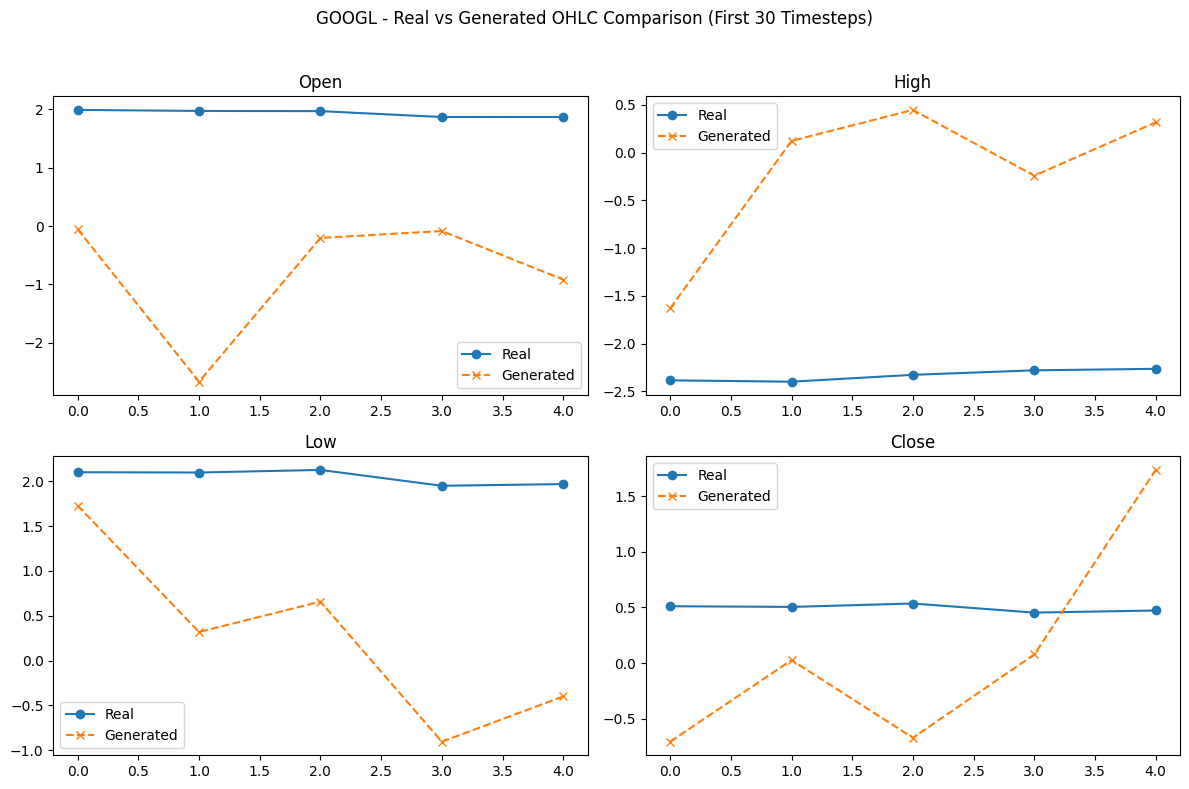

In [41]:
import matplotlib.pyplot as plt
import torch

# Ensure each sequence has a corresponding ticker ID
all_ticker_ids = []
for ticker in config['tickers']:
    ticker_id = ticker_to_id[ticker]
    ticker_sequences_count = len(processed_data[ticker]['sequences_ohlc'])  # Number of sequences for each ticker
    all_ticker_ids.extend([ticker_id] * ticker_sequences_count)

# Convert all_ticker_ids to tensor for masking during evaluation
all_ticker_ids = torch.tensor(all_ticker_ids)

# Define function to compute evaluation metrics
def compute_metrics(real, generated):
    """Compute metrics like MAE and RMSE between real and generated data."""
    mae = torch.mean(torch.abs(real - generated))
    rmse = torch.sqrt(torch.mean((real - generated) ** 2))
    return mae.item(), rmse.item()

# Loop through each ticker to compare real and generated data
for i, ticker in enumerate(config['tickers']):
    # Extract real and generated sequences by ticker
    ticker_mask = (all_ticker_ids == ticker_to_id[ticker])
    real_ticker_seq = real_seq[ticker_mask]
    generated_ticker_seq = fake_seq[ticker_mask]

    # Ensure correct sequence length for evaluation
    # assert real_ticker_seq.shape[1] >= 30, f"Expected sequence length >= 30, got {real_ticker_seq.shape[1]}"
    # assert generated_ticker_seq.shape[1] >= 30, f"Expected sequence length >= 30, got {generated_ticker_seq.shape[1]}"
    
    # Compute metrics
    mae, rmse = compute_metrics(real_ticker_seq[:, :config['sequence_length']], generated_ticker_seq[:, :30])
    print(f"\nMetrics for {ticker} - MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    
    # Plot real vs generated for each feature
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{ticker} - Real vs Generated OHLC Comparison (First 30 Timesteps)")

    for j, feature in enumerate(config['features']):
        ax = axes[j // 2, j % 2]
        ax.plot(real_ticker_seq[0, :30, j].cpu().detach().numpy(), label="Real", marker='o')
        ax.plot(generated_ticker_seq[0, :30, j].cpu().detach().numpy(), label="Generated", linestyle='--', marker='x')
        ax.set_title(f"{feature}")
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout
    plt.show()



Metrics for AAPL - MAE: 1.0286, RMSE: 1.3280


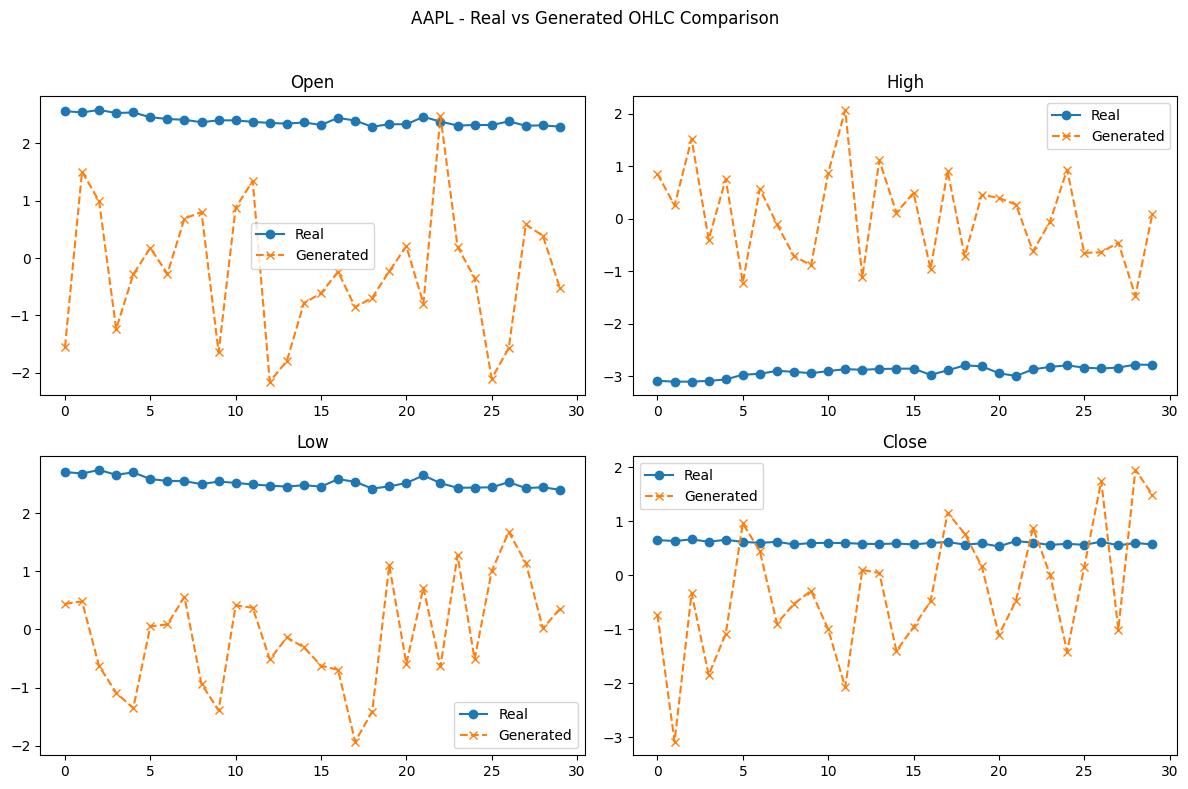


Metrics for MSFT - MAE: 1.0377, RMSE: 1.3280


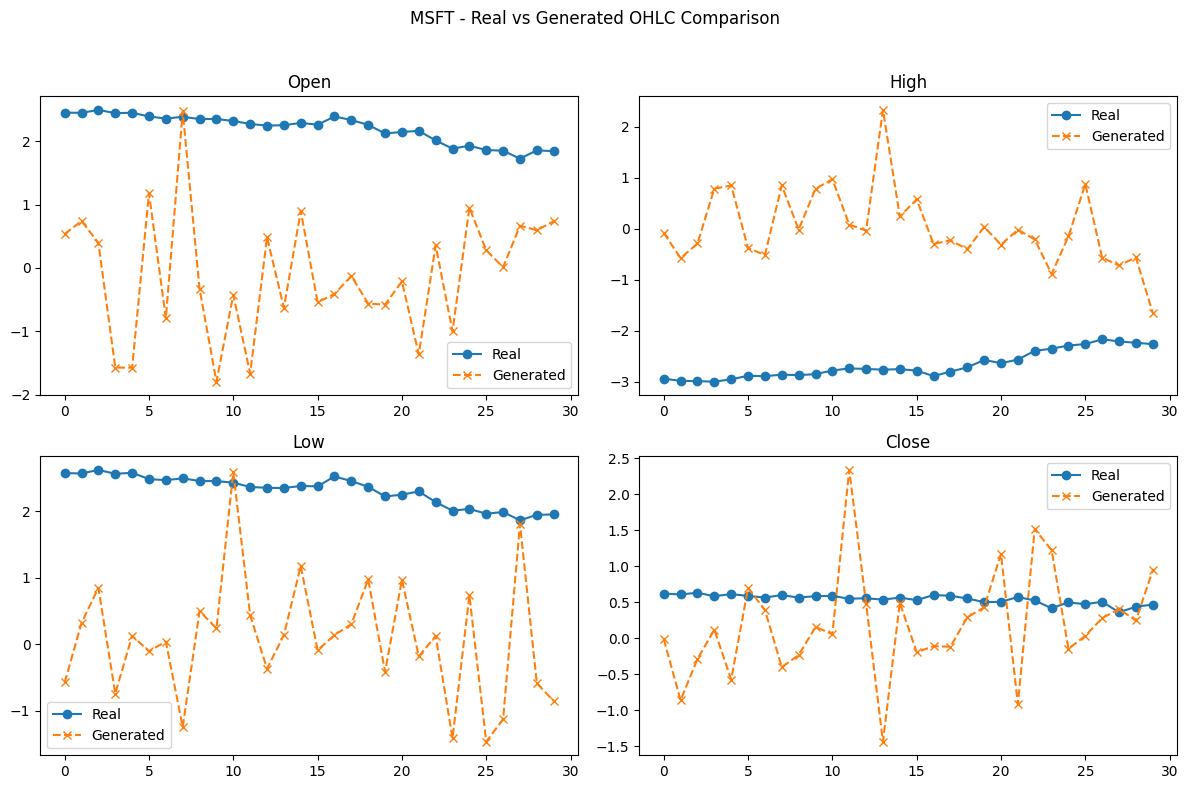


Metrics for GOOGL - MAE: 1.0424, RMSE: 1.3259


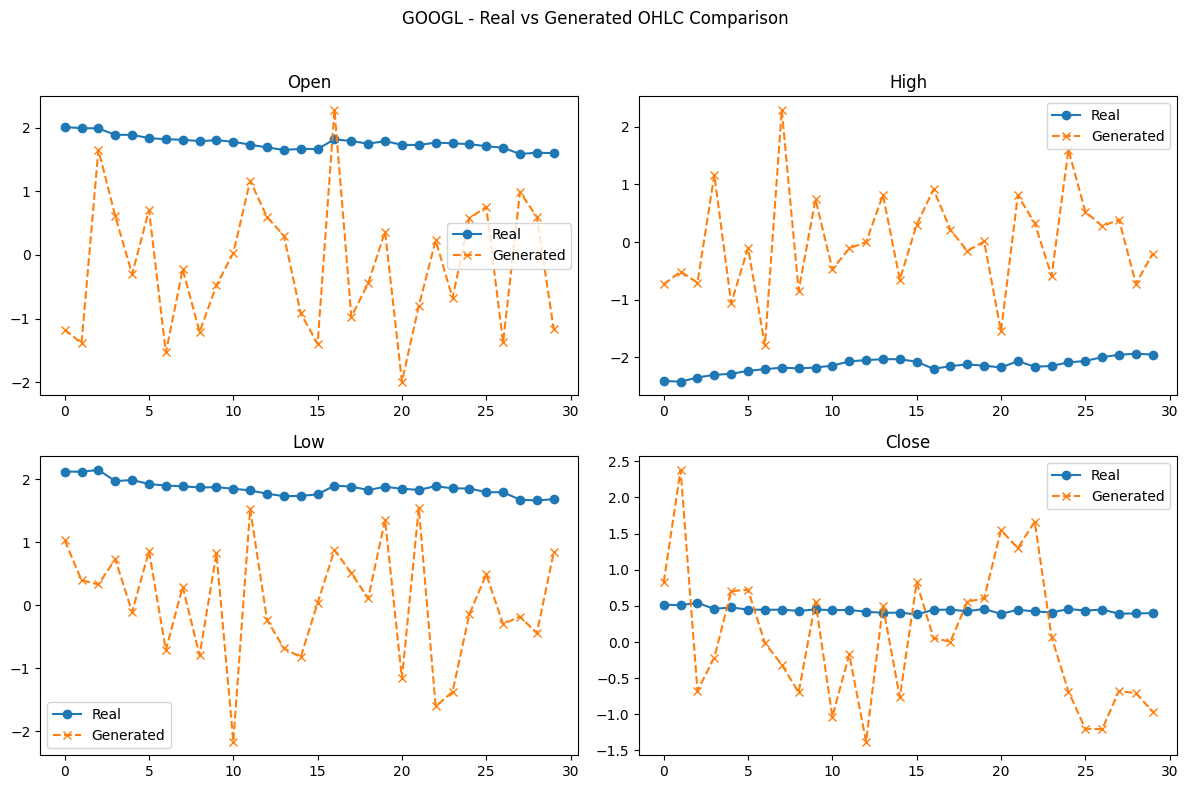

In [ ]:
import matplotlib.pyplot as plt
import torch

# Ensure each sequence has a corresponding ticker ID
all_ticker_ids = []
for ticker in config['tickers']:
    ticker_id = ticker_to_id[ticker]
    ticker_sequences_count = len(processed_data[ticker]['sequences_ohlc'])  # Number of sequences for each ticker
    all_ticker_ids.extend([ticker_id] * ticker_sequences_count)

# Convert all_ticker_ids to tensor for masking during evaluation
all_ticker_ids = torch.tensor(all_ticker_ids)

# Ensure shapes match for evaluation
assert real_seq.shape == fake_seq.shape, "Real and generated sequences should have the same shape for evaluation."

# Define function to compute evaluation metrics
def compute_metrics(real, generated):
    """Compute metrics like MAE and RMSE between real and generated data."""
    mae = torch.mean(torch.abs(real - generated))
    rmse = torch.sqrt(torch.mean((real - generated) ** 2))
    return mae.item(), rmse.item()

# Loop through each ticker to compare real and generated data
for i, ticker in enumerate(config['tickers']):
    # Extract real and generated sequences by ticker
    ticker_mask = (all_ticker_ids == ticker_to_id[ticker])
    real_ticker_seq = real_seq[ticker_mask]
    generated_ticker_seq = fake_seq[ticker_mask]

    # Compute metrics
    mae, rmse = compute_metrics(real_ticker_seq, generated_ticker_seq)
    print(f"\nMetrics for {ticker} - MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    
    # Plot real vs generated for each feature
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{ticker} - Real vs Generated OHLC Comparison")

    for j, feature in enumerate(config['features']):
        ax = axes[j // 2, j % 2]
        ax.plot(real_ticker_seq[0, :, j].cpu().detach().numpy(), label="Real", marker='o')
        ax.plot(generated_ticker_seq[0, :, j].cpu().detach().numpy(), label="Generated", linestyle='--', marker='x')
        ax.set_title(f"{feature}")
        ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout
    plt.show()


In [ ]:
# # Training loop setup
# n_epochs = 100
# optimizer_d = torch.optim.Adam([discriminator_projection, disc_projection], lr=0.0001)
# optimizer_g = torch.optim.Adam([Q_weight, K_weight, V_weight], lr=0.0001)

# # Training loop
# for epoch in range(n_epochs):
#     # Process real data
#     Q_real = torch.matmul(real_disc_input, Q_weight)
#     K_real = torch.matmul(real_disc_input, K_weight)
#     V_real = torch.matmul(real_disc_input, V_weight)
#     Q_real = Q_real.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     K_real = K_real.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     V_real = V_real.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     real_attended = process_attention(Q_real, K_real, V_real, d_k)
#     d_real = torch.sigmoid(torch.matmul(real_attended.mean(dim=1), disc_projection))

#     # Process fake data
#     Q_fake = torch.matmul(fake_disc_input, Q_weight)
#     K_fake = torch.matmul(fake_disc_input, K_weight)
#     V_fake = torch.matmul(fake_disc_input, V_weight)
#     Q_fake = Q_fake.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     K_fake = K_fake.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     V_fake = V_fake.view(-1, config['n_heads'], config['sequence_length'], d_k).transpose(1, 2)
#     fake_attended = process_attention(Q_fake, K_fake, V_fake, d_k)
#     d_fake = torch.sigmoid(torch.matmul(fake_attended.mean(dim=1), disc_projection))

#     # Compute losses
#     d_loss = -torch.mean(torch.log(d_real + 1e-8) + torch.log(1 - d_fake + 1e-8))
#     g_loss = -torch.mean(torch.log(d_fake + 1e-8))

#     # Update discriminator
#     optimizer_d.zero_grad()
#     d_loss.backward(retain_graph=True)
#     optimizer_d.step()

#     # Update generator
#     optimizer_g.zero_grad()
#     g_loss.backward()
#     optimizer_g.step()
    
#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}/{n_epochs} - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (9x12 and 8x1)

In [ ]:
# # Training loop setup
# n_epochs = 100
# batch_size = config['batch_size']

# # Optimizers
# optimizer_d = torch.optim.Adam([discriminator_projection, disc_projection], lr=0.0001)
# optimizer_g = torch.optim.Adam([Q_weight, K_weight, V_weight], lr=0.0001)

# # Training loop
# for epoch in range(n_epochs):
#     for ticker in config['tickers']:
#         ticker_mask = all_ticker_ids == ticker_to_id[ticker]
        
#         # Sample real data for this ticker
#         real_seq = all_sequences[ticker_mask][:batch_size]
        
#         # Generate fake sequences with ticker embedding
#         noise = torch.randn(batch_size, config['sequence_length'], config['d_model'])
#         ticker_embed = ticker_embedding(torch.full((batch_size,), ticker_to_id[ticker], dtype=torch.long))
#         fake_seq = noise + ticker_embed.unsqueeze(1)  # Apply ticker embedding to each time step in sequence
        
#         # Discriminator predictions for real and fake sequences
#         real_disc_input = torch.matmul(real_seq, discriminator_projection)
#         d_real_attended = process_attention(Q, K, V, d_k)
#         d_real = torch.sigmoid(torch.matmul(d_real_attended.mean(dim=1), disc_projection))
        
#         fake_disc_input = torch.matmul(fake_seq, discriminator_projection)
#         d_fake_attended = process_attention(Q, K, V, d_k)
#         d_fake = torch.sigmoid(torch.matmul(d_fake_attended.mean(dim=1), disc_projection))
        
#         # Compute losses
#         d_loss = -torch.mean(torch.log(d_real + 1e-8) + torch.log(1 - d_fake + 1e-8))
#         g_loss = -torch.mean(torch.log(d_fake + 1e-8))
        
#         # Update discriminator
#         optimizer_d.zero_grad()
#         d_loss.backward(retain_graph=True)
#         optimizer_d.step()
        
#         # Update generator
#         optimizer_g.zero_grad()
#         g_loss.backward()
#         optimizer_g.step()
    
#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}/{n_epochs} - D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (9x4 and 8x8)

In [ ]:
# Evaluation of generated data compared to real data
for ticker in config['tickers']:
    ticker_mask = all_ticker_ids == ticker_to_id[ticker]
    real = all_sequences[ticker_mask]
    fake = noise + ticker_embedding(torch.tensor([ticker_to_id[ticker]])).unsqueeze(1)
    
    # Plotting real vs generated data for each feature
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for i, feature in enumerate(config['features']):
        ax = axes[i//2, i%2]
        ax.plot(real[0, :, i], label='Real', marker='o')
        ax.plot(fake[0, :, i].detach().numpy(), label='Generated', marker='o')
        ax.set_title(f'{ticker} - {feature}')
        ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Statistics comparison
    print(f"\nStatistics for {ticker}:")
    for i, feature in enumerate(config['features']):
        print(f"\n{feature}:")
        print(f"Real - mean: {real[:, :, i].mean():.4f}, std: {real[:, :, i].std():.4f}")
        print(f"Generated - mean: {fake[:, :, i].mean():.4f}, std: {fake[:, :, i].std():.4f}")


NameError: name 'all_ticker_ids' is not defined

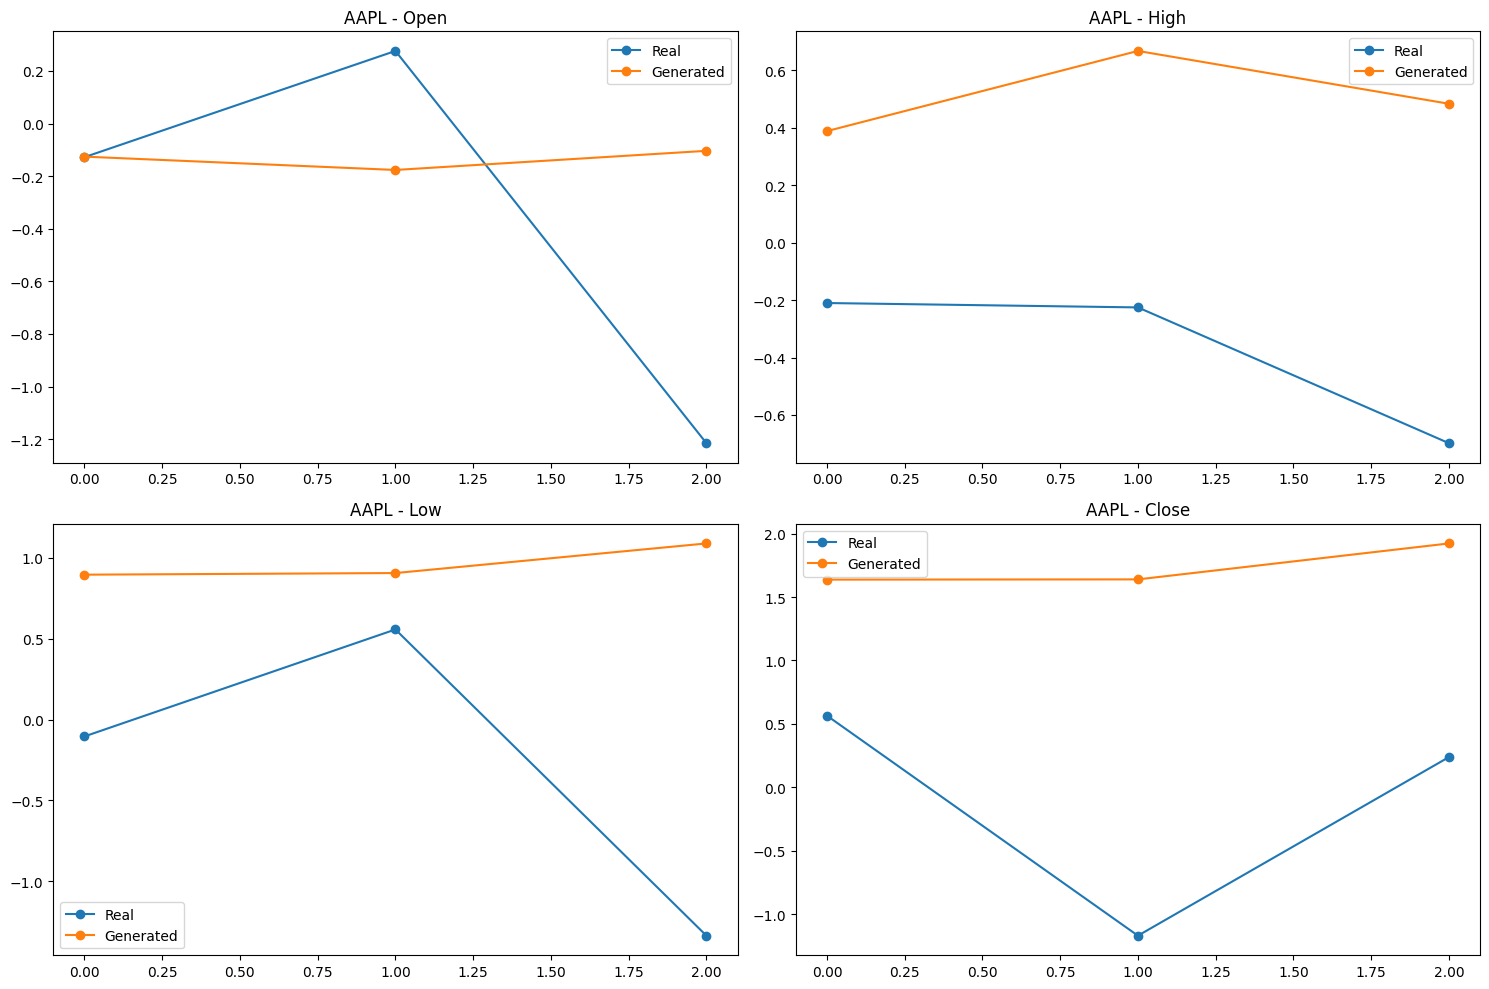


Statistics for AAPL:

Open:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 0.0607, std: 0.3922

High:
Real - mean: 0.0000, std: 1.0607
Generated - mean: -0.4778, std: 1.2270

Low:
Real - mean: -0.0000, std: 1.0607
Generated - mean: 0.8616, std: 0.4702

Close:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 1.1684, std: 0.4643


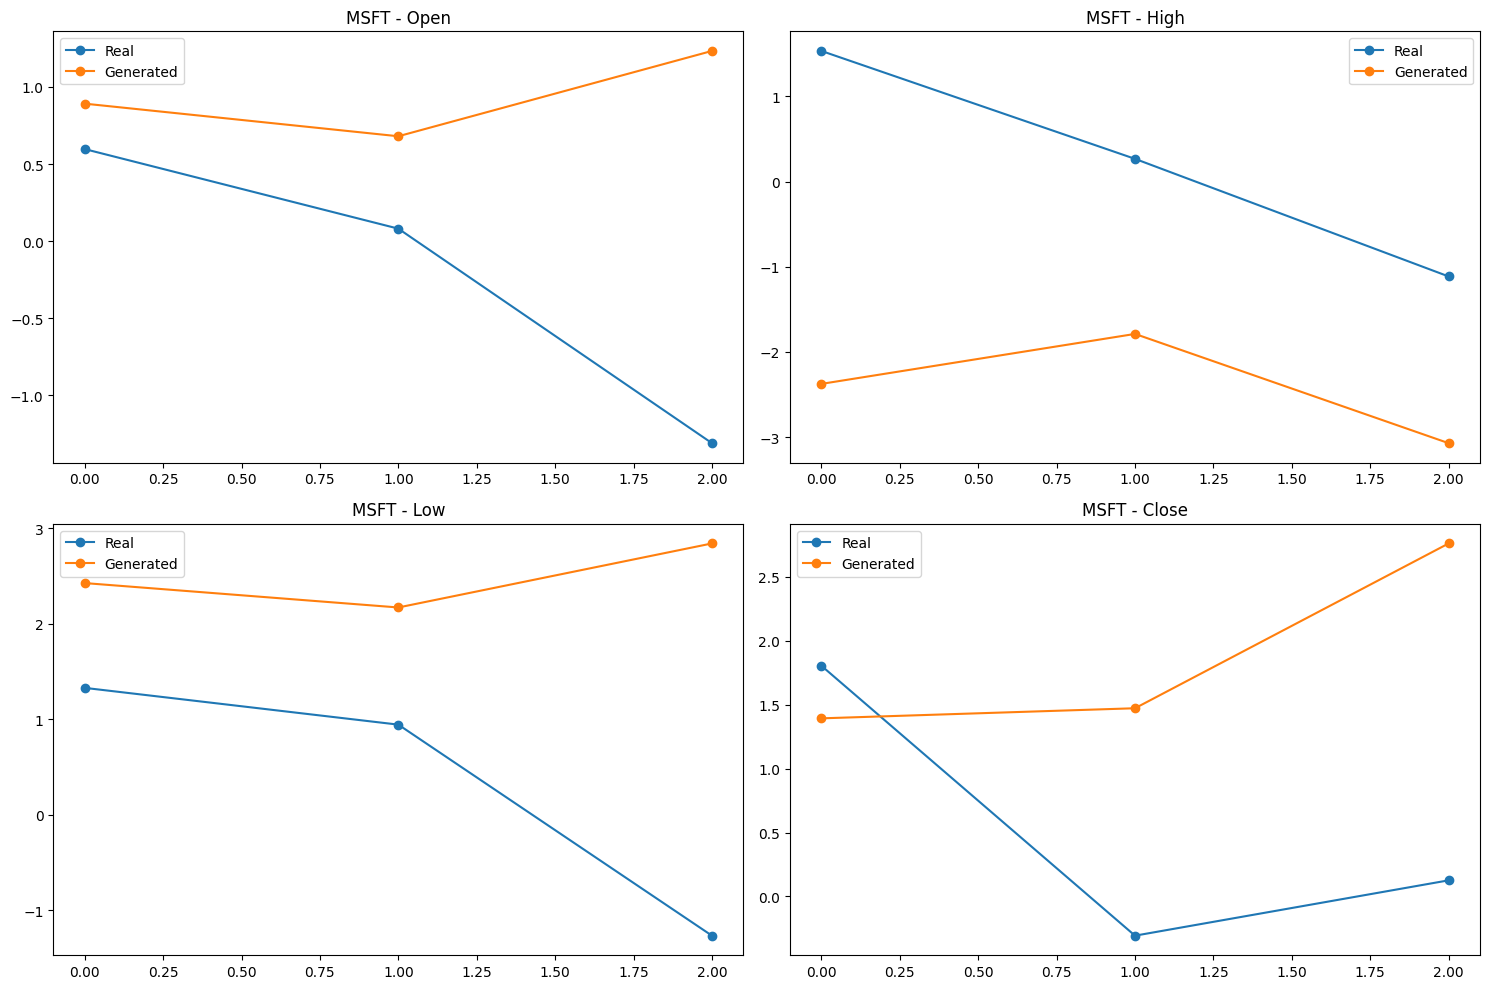


Statistics for MSFT:

Open:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 0.2457, std: 0.5696

High:
Real - mean: -0.0000, std: 1.0607
Generated - mean: -0.7671, std: 1.3868

Low:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 1.2168, std: 1.0137

Close:
Real - mean: -0.0000, std: 1.0607
Generated - mean: 1.2642, std: 0.7421


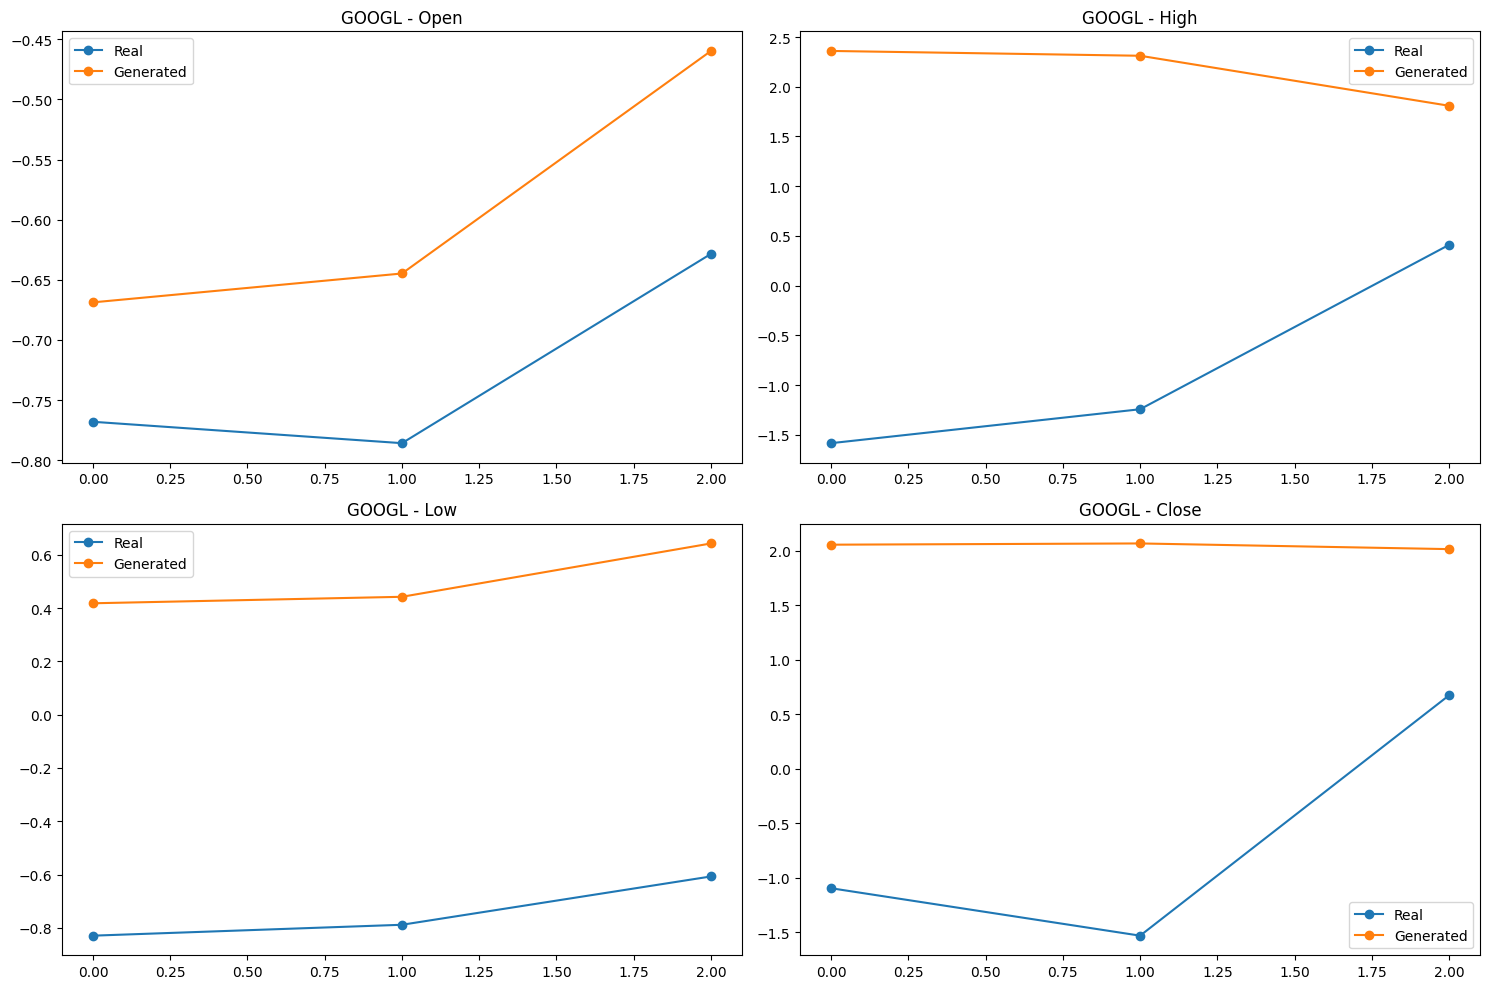


Statistics for GOOGL:

Open:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 0.1257, std: 0.7329

High:
Real - mean: -0.0000, std: 1.0607
Generated - mean: -0.5296, std: 2.6117

Low:
Real - mean: 0.0000, std: 1.0607
Generated - mean: 0.9975, std: 0.5953

Close:
Real - mean: -0.0000, std: 1.0607
Generated - mean: 1.2254, std: 0.6518


In [ ]:

# Cell 7 [In] - Evaluation
# Compare by ticker and feature
for ticker in config['tickers']:
    ticker_mask = all_ticker_ids == ticker_to_id[ticker]
    real = all_sequences[ticker_mask]
    fake = generated_ohlc[ticker_mask]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for i, feature in enumerate(config['features']):
        ax = axes[i//2, i%2]
        ax.plot(real[0, :, i], label='Real', marker='o')
        ax.plot(fake[0, :, i].detach().numpy(), label='Generated', marker='o')
        ax.set_title(f'{ticker} - {feature}')
        ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nStatistics for {ticker}:")
    for i, feature in enumerate(config['features']):
        print(f"\n{feature}:")
        print(f"Real - mean: {real[:, :, i].mean():.4f}, std: {real[:, :, i].std():.4f}")
        print(f"Generated - mean: {fake[:, :, i].mean():.4f}, std: {fake[:, :, i].std():.4f}")

In [ ]:
# Generate sequences for specific ticker
ticker = 'AAPL'
ticker_id = ticker_to_id[ticker]
real_seq = processed_data[ticker]['sequences_ohlc'][0]  # First sequence

# Generate matching sequence
with torch.no_grad():
    fake_seq = gen_output[ticker_id]

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features = ['Open', 'High', 'Low', 'Close']

for idx, (feature, ax) in enumerate(zip(features, axes.flat)):
    ax.plot(real_seq[:, idx], label='Real', marker='o')
    ax.plot(fake_seq[:, idx].numpy(), label='Generated', marker='o')
    ax.set_title(f'{feature} Price')
    ax.legend()

plt.tight_layout()
plt.show()

# Distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for idx, (feature, ax) in enumerate(zip(features, axes.flat)):
    sns.kdeplot(real_seq[:, idx], ax=ax, label='Real')
    sns.kdeplot(fake_seq[:, idx].numpy(), ax=ax, label='Generated')
    ax.set_title(f'{feature} Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics comparison:")
for idx, feature in enumerate(features):
    print(f"\n{feature}:")
    print(f"Real mean: {real_seq[:, idx].mean():.4f}")
    print(f"Generated mean: {fake_seq[:, idx].mean():.4f}")
    print(f"Real std: {real_seq[:, idx].std():.4f}")
    print(f"Generated std: {fake_seq[:, idx].std():.4f}")

In [ ]:
# Training parameters
n_epochs = 50
learning_rate = 0.0001
batch_size = 32

# Define optimizer including ticker embedding weights
optimizer = torch.optim.Adam([Q_weight, K_weight, V_weight, output_projection, ticker_embedding.weight], lr=learning_rate)
losses = []

for epoch in range(n_epochs):
    # Randomly select a batch of sequences from combined data
    batch_indices = np.random.randint(0, len(all_sequences) - batch_size)
    real_batch = torch.FloatTensor(all_sequences[batch_indices:batch_indices + batch_size])
    ticker_ids_batch = all_ticker_ids[batch_indices:batch_indices + batch_size]
    ticker_embeddings_batch = ticker_embedding(ticker_ids_batch)

    # Forward pass with ticker-specific embeddings
    projected_data = torch.matmul(real_batch, weight) + bias
    data_with_ticker_embedding = projected_data + ticker_embeddings_batch.unsqueeze(1)
    
    Q = torch.matmul(data_with_ticker_embedding, Q_weight)
    K = torch.matmul(data_with_ticker_embedding, K_weight)
    V = torch.matmul(data_with_ticker_embedding, V_weight)
    
    Q = Q.view(batch_size, seq_length, n_heads, d_k).transpose(1, 2)
    K = K.view(batch_size, seq_length, n_heads, d_k).transpose(1, 2)
    V = V.view(batch_size, seq_length, n_heads, d_k).transpose(1, 2)
    
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    attention_weights = F.softmax(scores, dim=-1)
    attended_values = torch.matmul(attention_weights, V)
    attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, seq_length, d_model)
    generated_ohlc = torch.matmul(attended_values, output_projection)

    # Loss computation
    loss = F.mse_loss(generated_ohlc, real_batch)
    losses.append(loss.item())

    # Backpropagation and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Display the final loss
print("\nFinal training loss:", losses[-1])


/var/folders/pk/p4tz0gf96l113931p5pw8d6c0000gp/T/ipykernel_35225/2778170441.py:36: UserWarning: Using a target size (torch.Size([32, 3, 4])) that is different to the input size (torch.Size([32, 3, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(generated_ohlc, real_batch)


RuntimeError: The size of tensor a (8) must match the size of tensor b (4) at non-singleton dimension 2

### Training Step

In [ ]:
# Get a batch of real data
batch_idx = np.random.randint(0, len(processed_data['AAPL']['norm_ohlc']) - 2)
real_batch = torch.FloatTensor(processed_data['AAPL']['norm_ohlc'][batch_idx:batch_idx+2])

print("Real batch shape:", real_batch.shape)
print("Real batch first sequence:")
print(real_batch[0])

# Make sure our tensors require gradients
Q_weight.requires_grad_(True)
K_weight.requires_grad_(True)
V_weight.requires_grad_(True)
output_projection.requires_grad_(True)
ohlc_projection.requires_grad_(True)

# Recompute with gradients
Q = torch.matmul(data_with_pos, Q_weight)
K = torch.matmul(data_with_pos, K_weight)
V = torch.matmul(data_with_pos, V_weight)

# Reshape for attention
Q = Q.view(2, 3, n_heads, d_k).transpose(1, 2)
K = K.view(2, 3, n_heads, d_k).transpose(1, 2)
V = V.view(2, 3, n_heads, d_k).transpose(1, 2)

# Compute attention
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attention_weights = F.softmax(scores, dim=-1)
attended_values = torch.matmul(attention_weights, V)

# Final projections
attended_values = attended_values.transpose(1, 2).contiguous().view(2, 3, d_model)
attention_output = torch.matmul(attended_values, output_projection)
generated_ohlc = torch.matmul(attention_output, ohlc_projection)

# Compute loss
mse_loss = F.mse_loss(generated_ohlc, real_batch)
print("\nMSE Loss:", mse_loss.item())

# Gradient step
optimizer = torch.optim.Adam([Q_weight, K_weight, V_weight, 
                            output_projection, ohlc_projection], lr=0.0001)
optimizer.zero_grad()
mse_loss.backward()
optimizer.step()

print("\nUpdated generated OHLC:")
print(generated_ohlc[0])

Real batch shape: torch.Size([2, 3, 4])
Real batch first sequence:
tensor([[0.1812, 0.1439, 0.1977, 0.1825],
        [0.1514, 0.1556, 0.1953, 0.1852],
        [0.1456, 0.1103, 0.1427, 0.1386]])

MSE Loss: 14.622390747070312

Updated generated OHLC:
tensor([[-2.9706, -0.9374,  6.8741, -1.8585],
        [-2.8755, -0.8722,  6.8186, -1.9254],
        [-2.7858, -0.8017,  6.7639, -1.9931]], grad_fn=<SelectBackward0>)


### Training loop

In [ ]:
# Training parameters
n_epochs = 100
batch_size = 2
losses = []

for epoch in range(n_epochs):
    # Get random batch
    batch_idx = np.random.randint(0, len(processed_data['AAPL']['norm_ohlc']) - batch_size)
    real_batch = torch.FloatTensor(processed_data['AAPL']['norm_ohlc'][batch_idx:batch_idx+batch_size])
    
    # Forward pass
    Q = torch.matmul(data_with_pos, Q_weight)
    K = torch.matmul(data_with_pos, K_weight)
    V = torch.matmul(data_with_pos, V_weight)
    
    Q = Q.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    K = K.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    V = V.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    attention_weights = F.softmax(scores, dim=-1)
    attended_values = torch.matmul(attention_weights, V)
    
    attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, 3, d_model)
    attention_output = torch.matmul(attended_values, output_projection)
    generated_ohlc = torch.matmul(attention_output, ohlc_projection)
    
    # Compute loss
    loss = F.mse_loss(generated_ohlc, real_batch)
    
    # Optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("\nTraining completed!")

### Evaluation

In [ ]:
# Generate sequences and compare with real data
with torch.no_grad():
    # Generate new sequence
    test_data_with_pos = data_with_pos.clone()
    Q = torch.matmul(test_data_with_pos, Q_weight)
    K = torch.matmul(test_data_with_pos, K_weight)
    V = torch.matmul(test_data_with_pos, V_weight)
    
    Q = Q.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    K = K.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    V = V.view(batch_size, 3, n_heads, d_k).transpose(1, 2)
    
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    attention_weights = F.softmax(scores, dim=-1)
    attended_values = torch.matmul(attention_weights, V)
    
    attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, 3, d_model)
    attention_output = torch.matmul(attended_values, output_projection)
    generated_sequence = torch.matmul(attention_output, ohlc_projection)

# Compare with real data
real_sequence = processed_data['AAPL']['norm_ohlc'][:batch_size]

print("Generated sequence:")
print(generated_sequence[0])
print("\nReal sequence:")
print(real_sequence[0])

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# Plot real vs generated sequences
plt.figure(figsize=(12, 6))
plt.plot(real_sequence[0, :, 3], label='Real Close Price')
plt.plot(generated_sequence[0, :, 3].numpy(), label='Generated Close Price')
plt.title('Real vs Generated Close Prices')
plt.legend()
plt.show()

Generated sequence:
tensor([[-2.9613, -0.9343,  6.8603, -1.8494],
        [-2.8665, -0.8692,  6.8050, -1.9163],
        [-2.7771, -0.7989,  6.7505, -1.9838]])

Real sequence:
[[-2.0058 -2.0151 -1.9751 -1.9784]
 [-1.9989 -2.0153 -1.9652 -2.0004]
 [-2.0242 -2.0199 -1.9936 -1.9825]]


NameError: name 'losses' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
processed_data

{'AAPL': {'sequences_ohlc': array([[[ 74.06  ,  75.15  ,  73.7975,  75.0875],
          [ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ]],
  
         [[ 74.2875,  75.145 ,  74.125 ,  74.3575],
          [ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975]],
  
         [[ 73.4475,  74.99  ,  73.1875,  74.95  ],
          [ 74.96  ,  75.225 ,  74.37  ,  74.5975],
          [ 74.29  ,  76.11  ,  74.29  ,  75.7975]],
  
         ...,
  
         [[196.1   , 197.08  , 193.5   , 194.68  ],
          [195.18  , 195.41  , 192.97  , 193.6   ],
          [193.61  , 193.89  , 192.83  , 193.05  ]],
  
         [[195.18  , 195.41  , 192.97  , 193.6   ],
          [193.61  , 193.89  , 192.83  , 193.05  ],
          [192.49  , 193.5   , 191.09  , 193.15  ]],
  
         [[193.61  , 193.89  , 192.83  , 193.05  ],
          [192.49  , 193.5   , 191.09  , 193.15  ],
          [194.14  , 194.66  , 193.17  , 193.58  ]]])

### Generator Architecture

In [ ]:
class Generator(nn.Module):
    def __init__(self, d_model=8, sequence_length=3):
        super().__init__()
        self.noise_dim = 32  # Input noise dimension
        
        # Project noise to sequence dimension
        self.initial_projection = nn.Linear(self.noise_dim, sequence_length * d_model)
        self.attention = MultiHeadAttention(d_model)  # Using attention from above
        self.final_projection = nn.Linear(d_model, 4)  # Project back to OHLC
        
    def forward(self, z):
        # z shape: [batch_size, noise_dim]
        x = self.initial_projection(z)
        x = x.view(-1, 3, d_model)  # [batch_size, seq_length, d_model]
        x = self.attention(x)
        return self.final_projection(x)  # [batch_size, seq_length, 4]

# Test generator
generator = Generator()
test_noise = torch.randn(2, 32)  # 2 sequences
generated_sequences = generator(test_noise)

print("Generated sequences shape:", generated_sequences.shape)
print("\nFirst generated sequence:")
print(generated_sequences[0])

NameError: name 'MultiHeadAttention' is not defined

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = 16  # Starting with small dimension for clarity
        max_len = config['sequence_length']
        
        # Create matrix of shape [max_len, d_model]
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           -(math.log(10000.0) / d_model))
        
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Save positional encoding
        self.register_buffer('pe', pe)
        
        print("Positional encoding shape:", pe.shape)
        print("\nFirst position encoding:")
        print(pe[0])
        print("\nSecond position encoding:")
        print(pe[1])
        print("\nThird position encoding:")
        print(pe[2])

# Create and test
pos_enc = PositionalEncoding(config)

Positional encoding shape: torch.Size([30, 16])

First position encoding:
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])

Second position encoding:
tensor([8.4147e-01, 5.4030e-01, 3.1098e-01, 9.5042e-01, 9.9833e-02, 9.9500e-01,
        3.1618e-02, 9.9950e-01, 9.9998e-03, 9.9995e-01, 3.1623e-03, 1.0000e+00,
        1.0000e-03, 1.0000e+00, 3.1623e-04, 1.0000e+00])

Third position encoding:
tensor([ 9.0930e-01, -4.1615e-01,  5.9113e-01,  8.0658e-01,  1.9867e-01,
         9.8007e-01,  6.3203e-02,  9.9800e-01,  1.9999e-02,  9.9980e-01,
         6.3245e-03,  9.9998e-01,  2.0000e-03,  1.0000e+00,  6.3246e-04,
         1.0000e+00])


In [ ]:
class StockDataEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model = 16  # Same as positional encoding
        
        # Linear layer to project OHLC (4 features) to d_model dimensions
        self.price_embedding = nn.Linear(4, self.d_model)
        self.pos_encoding = PositionalEncoding(config)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, 4]
        embedded = self.price_embedding(x)  # Project to d_model
        embedded = embedded + self.pos_encoding.pe
        
        return embedded

# Test with sample data
batch_size = 2
sample_data = processed_data['AAPL']['norm_ohlc'][:batch_size]
sample_tensor = torch.FloatTensor(sample_data)

embedding_layer = StockDataEmbedding(config)
embedded_data = embedding_layer(sample_tensor)

print("Input shape:", sample_tensor.shape)
print("Embedded shape:", embedded_data.shape)
print("\nFirst sequence, first timestep embedding:")
print(embedded_data[0, 0])

Positional encoding shape: torch.Size([30, 16])

First position encoding:
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])

Second position encoding:
tensor([8.4147e-01, 5.4030e-01, 3.1098e-01, 9.5042e-01, 9.9833e-02, 9.9500e-01,
        3.1618e-02, 9.9950e-01, 9.9998e-03, 9.9995e-01, 3.1623e-03, 1.0000e+00,
        1.0000e-03, 1.0000e+00, 3.1623e-04, 1.0000e+00])

Third position encoding:
tensor([ 9.0930e-01, -4.1615e-01,  5.9113e-01,  8.0658e-01,  1.9867e-01,
         9.8007e-01,  6.3203e-02,  9.9800e-01,  1.9999e-02,  9.9980e-01,
         6.3245e-03,  9.9998e-01,  2.0000e-03,  1.0000e+00,  6.3246e-04,
         1.0000e+00])


RuntimeError: The size of tensor a (3) must match the size of tensor b (30) at non-singleton dimension 1

In [ ]:
# Configuration dictionary
config = {
    'tickers': ['AAPL', 'MSFT', 'GOOGL'],
    'start_date': "2020-01-01",
    'end_date': "2024-01-01",
    'sequence_length': 30,
    'features': ['Open', 'High', 'Low', 'Close', 'Volume'],
    'num_features': 5,
    'random_seed': 42,
    # Model parameters
    'batch_size': 32,
    'noise_dim': 100,
    'd_model': 64,
    'n_heads': 4,
    'n_layers': 3,
    'dim_feedforward': 256,
    'dropout': 0.1,
    'learning_rate': 0.0001,
    'beta1': 0.5,
    'beta2': 0.999,
    'ticker_embed_dim': 8
}

print("Configuration parameters:")
for key, value in config.items():
    print(f"{key}: {value}")

import math 
    
class PositionalEncoding(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        d_model = config['d_model']
        max_len = config['sequence_length'] * 2  # Some buffer for max length
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

# Make sure you have the TransformerGenerator class defined as follows:
class TransformerGenerator(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        
        self.sequence_length = config['sequence_length']
        self.d_model = config['d_model']
        
        # Project noise to sequence
        self.noise_projection = nn.Linear(
            config['noise_dim'], 
            config['sequence_length'] * config['d_model']
        )
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(config)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            config['n_layers']
        )
        
        # Output projection (to OHLCV)
        self.output_proj = nn.Linear(
            config['d_model'], 
            len(config['features'])
        )
        
    def forward(self, z: torch.Tensor, ticker_idx: int) -> torch.Tensor:
        batch_size = z.size(0)
        
        x = self.noise_projection(z)
        x = x.view(batch_size, self.sequence_length, self.d_model)
        
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.output_proj(x)
        
        return x





# ticker = 'AAPL'  # Set the ticker to generate data for
# ticker_idx = config['tickers'].index(ticker)  # Get the index of the ticker in the list
# test_noise = torch.randn(config['batch_size'], config['noise_dim'])  # Generate noise


class TransformerDiscriminator(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        
        self.sequence_length = config['sequence_length']
        self.d_model = config['d_model']
        num_features = len(config['features'])  # Ensure this matches your data features, e.g., 5 for OHLCV
        print('num_features', num_features)
        # Project input from num_features to d_model
        self.input_proj = nn.Linear(num_features, config['d_model'])
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(config)
        
        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            config['n_layers']
        )
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(config['sequence_length'] * config['d_model'], config['dim_feedforward']),
            nn.LeakyReLU(0.2),
            nn.Linear(config['dim_feedforward'], 1),
            nn.Sigmoid()
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        
        # Reshape x to (batch_size * sequence_length, num_features) for input_proj
        x = x.view(-1, x.size(-1))  # Shape becomes (batch_size * sequence_length, num_features)
        print('x.shape', x.shape)
        # Project input to d_model dimensions
        x = self.input_proj(x)  # Shape: (batch_size * sequence_length, d_model)
        
        # Reshape x back to (batch_size, sequence_length, d_model)
        x = x.view(batch_size, self.sequence_length, self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoder
        x = self.transformer(x)
        
        # Flatten for output projection
        x = x.reshape(batch_size, -1)
        x = self.output_proj(x)
        
        return x






# # Test the discriminator
# discriminator = TransformerDiscriminator(config)
# with torch.no_grad():
#     discrimination = discriminator(generated_sequence)

# print("\nDiscriminator test:")
# print(f"Input sequence shape: {generated_sequence.shape}")
# print(f"Discrimination output shape: {discrimination.shape}")

Configuration parameters:
tickers: ['AAPL', 'MSFT', 'GOOGL']
start_date: 2020-01-01
end_date: 2024-01-01
sequence_length: 30
features: ['Open', 'High', 'Low', 'Close', 'Volume']
num_features: 5
random_seed: 42
batch_size: 32
noise_dim: 100
d_model: 64
n_heads: 4
n_layers: 3
dim_feedforward: 256
dropout: 0.1
learning_rate: 0.0001
beta1: 0.5
beta2: 0.999
ticker_embed_dim: 8


In [ ]:
import torch.optim as optim

# Binary Cross Entropy loss function for GAN training
criterion = nn.BCELoss()


generator = TransformerGenerator(config)
discriminator = TransformerDiscriminator(config)


# Optimizers for the generator and discriminator
gen_optimizer = optim.Adam(
    generator.parameters(), 
    lr=config['learning_rate'], 
    betas=(config['beta1'], config['beta2'])
)
disc_optimizer = optim.Adam(
    discriminator.parameters(), 
    lr=config['learning_rate'], 
    betas=(config['beta1'], config['beta2'])
)
# Training configuration
epochs = 100  # Number of epochs
real_label = 1
fake_label = 0

for epoch in range(epochs):
    for ticker in config['tickers']:
        ticker_idx = config['tickers'].index(ticker)  # Get index for the current ticker
        
        # Get a batch of real data for the current ticker
        # Assuming `real_data` is loaded here for each ticker, e.g., from `processed_data[ticker]`
        real_data = processed_data[ticker]['sequences_ohlc']  # Replace with real data loading in practice
        real_data = torch.tensor(real_data[:config['batch_size']], dtype=torch.float32)  # Example batch
        # Ensure real_data has the correct shape before passing to discriminator

        # Verify if the shape is correct; if not, reshape
        if real_data.dim() == 2:
            # Reshape to (batch_size, sequence_length, num_features) if needed
            real_data = real_data.view(config['batch_size'], config['sequence_length'], len(config['features']))

        batch_size = real_data.size(0)

        # Labels for real and fake data, with dtype set to Float
        labels_real = torch.full((batch_size, 1), real_label, dtype=torch.float32)
        labels_fake = torch.full((batch_size, 1), fake_label, dtype=torch.float32)

        # Train discriminator on real data
        disc_optimizer.zero_grad()
        output_real = discriminator(real_data)
        loss_real = criterion(output_real, labels_real)
        loss_real.backward()

        # Train discriminator on fake data
        noise = torch.randn(batch_size, config['noise_dim'])
        fake_data = generator(noise, ticker_idx).detach()  # Pass ticker_idx to generator
        output_fake = discriminator(fake_data)
        loss_fake = criterion(output_fake, labels_fake)
        loss_fake.backward()
        
        disc_optimizer.step()

        # Train generator
        gen_optimizer.zero_grad()
        noise = torch.randn(batch_size, config['noise_dim'])
        fake_data = generator(noise, ticker_idx)  # Pass ticker_idx to generator
        output = discriminator(fake_data)
        loss_gen = criterion(output, labels_real)  # Generator tries to make discriminator think fake is real
        loss_gen.backward()
        gen_optimizer.step()

    # Logging for each epoch
    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {(loss_real + loss_fake).item():.4f} | G Loss: {loss_gen.item():.4f}")


num_features 5
x.shape torch.Size([96, 4])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x4 and 5x64)

In [ ]:
# Cell 2: Define Loss and Optimizers
import torch.optim as optim

# Loss function
criterion = nn.BCELoss()

# Optimizers
lr = 0.0002  # Learning rate
generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

# Cell 3: Training Loop
epochs = 100  # Number of epochs
batch_size = 32  # Batch size
real_label = 1
fake_label = 0

# Training loop
epochs = 100  # Number of epochs
batch_size = 32  # Batch size
real_label = 1
fake_label = 0

for epoch in range(epochs):
    for ticker in config['tickers']:
        data = processed_data[ticker]['norm_ohlc']
        
        # Convert real data to the expected shape
        real_data = torch.tensor(data, dtype=torch.float32)  # Should be (batch_size, seq_length, num_features)
        
        # Train discriminator on real data
        discriminator_optimizer.zero_grad()
        
        # Ensure real_data is in the correct shape before passing it to the discriminator
        output_real = discriminator(real_data)
        
        labels_real = torch.full((real_data.size(0),), real_label, dtype=torch.float32)
        loss_real = criterion(output_real, labels_real)
        loss_real.backward()
        
        # Train discriminator on fake data
        noise = torch.randn(batch_size, noise_dim)
        fake_data = generator(noise).detach()
        
        # Ensure fake_data shape matches real_data's expected shape in the discriminator
        output_fake = discriminator(fake_data)
        
        labels_fake = torch.full((fake_data.size(0),), fake_label, dtype=torch.float32)
        loss_fake = criterion(output_fake, labels_fake)
        loss_fake.backward()
        
        discriminator_optimizer.step()
        
        # Train generator
        generator_optimizer.zero_grad()
        noise = torch.randn(batch_size, noise_dim)
        fake_data = generator(noise)
        
        output = discriminator(fake_data)
        loss_gen = criterion(output, labels_real)  # Generator tries to make discriminator think fake is real
        loss_gen.backward()
        generator_optimizer.step()

    # Print progress
    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {(loss_real + loss_fake).item():.4f} | G Loss: {loss_gen.item():.4f}")





RuntimeError: mat1 and mat2 shapes cannot be multiplied (1003x12 and 150x64)

In [ ]:
# Cell 4: Generate Synthetic Data
num_samples = 10  # Number of synthetic sequences to generate
noise = torch.randn(num_samples, noise_dim)
synthetic_data = generator(noise).detach().numpy()

print("Synthetic OHLC sequences generated:")
print(synthetic_data[:3])  # Display first 3 synthetic sequences


# Cell 5: Denormalize and Visualize Synthetic Data
ticker = 'AAPL'
params = processed_data[ticker]['norm_params']

denorm_synthetic_ohlc, _ = denormalize_stock_data(
    synthetic_data,
    synthetic_data,  # Volume (using the same data for simplicity)
    params
)

print("Denormalized synthetic OHLC data:")
print(denorm_synthetic_ohlc[:3])

plt.figure(figsize=(10, 4))
plt.plot(denorm_synthetic_ohlc[:, :, 3].T, label='Synthetic Close')
plt.title('Synthetic Generated Close Prices')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Cell 2: Define Loss and Optimizers
import torch.optim as optim

# Loss function
criterion = nn.BCELoss()

# Optimizers
lr = 0.0002  # Learning rate
generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)


In [ ]:
class PositionalEncoding(nn.Module):
    """
    Adds positional information to help transformer understand sequence order.
    Without this, transformer wouldn't know which timestep comes first/last.
    """
    def __init__(self, config: dict):
        super().__init__()
        d_model = config['d_model']
        max_len = config['sequence_length'] * 2
        
        # Create position matrix for each position in sequence
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        # Create encoding matrix
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
        
        # Print shape for verification
        print(f"Positional encoding shape: {pe.shape}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add positional encoding to input."""
        return x + self.pe[:, :x.size(1)]

# Test positional encoding
pos_enc = PositionalEncoding(config)
test_input = torch.randn(config['batch_size'], config['sequence_length'], config['d_model'])
encoded = pos_enc(test_input)

# print(f"Input: {test_input}")
# print(f"Encoded: {encoded}")

# Let's look at just the first element to see the difference
print("\nComparison of first element:")
print("Original input:", test_input[0, 0, :5].numpy())  # First sequence, first timestep, first 5 values
print("After encoding:", encoded[0, 0, :5].numpy())     # Same position after encoding
print("\nTest shapes:")
print(f"Input shape: {test_input.shape}")
print(f"Encoded shape: {encoded.shape}")

Positional encoding shape: torch.Size([1, 60, 64])

Comparison of first element:
Original input: [-0.6398  0.3102  0.8442  0.1167  0.3117]
After encoding: [-0.6398  1.3102  0.8442  1.1167  0.3117]

Test shapes:
Input shape: torch.Size([32, 30, 64])
Encoded shape: torch.Size([32, 30, 64])


Original sequence (uptrend then downtrend):
tensor([100.0000, 103.5714, 107.1429, 110.7143, 114.2857])

Reversed sequence (downtrend then uptrend):
tensor([120.0000, 122.1429, 124.2857, 126.4286, 128.5714])
Positional encoding shape: torch.Size([1, 60, 64])


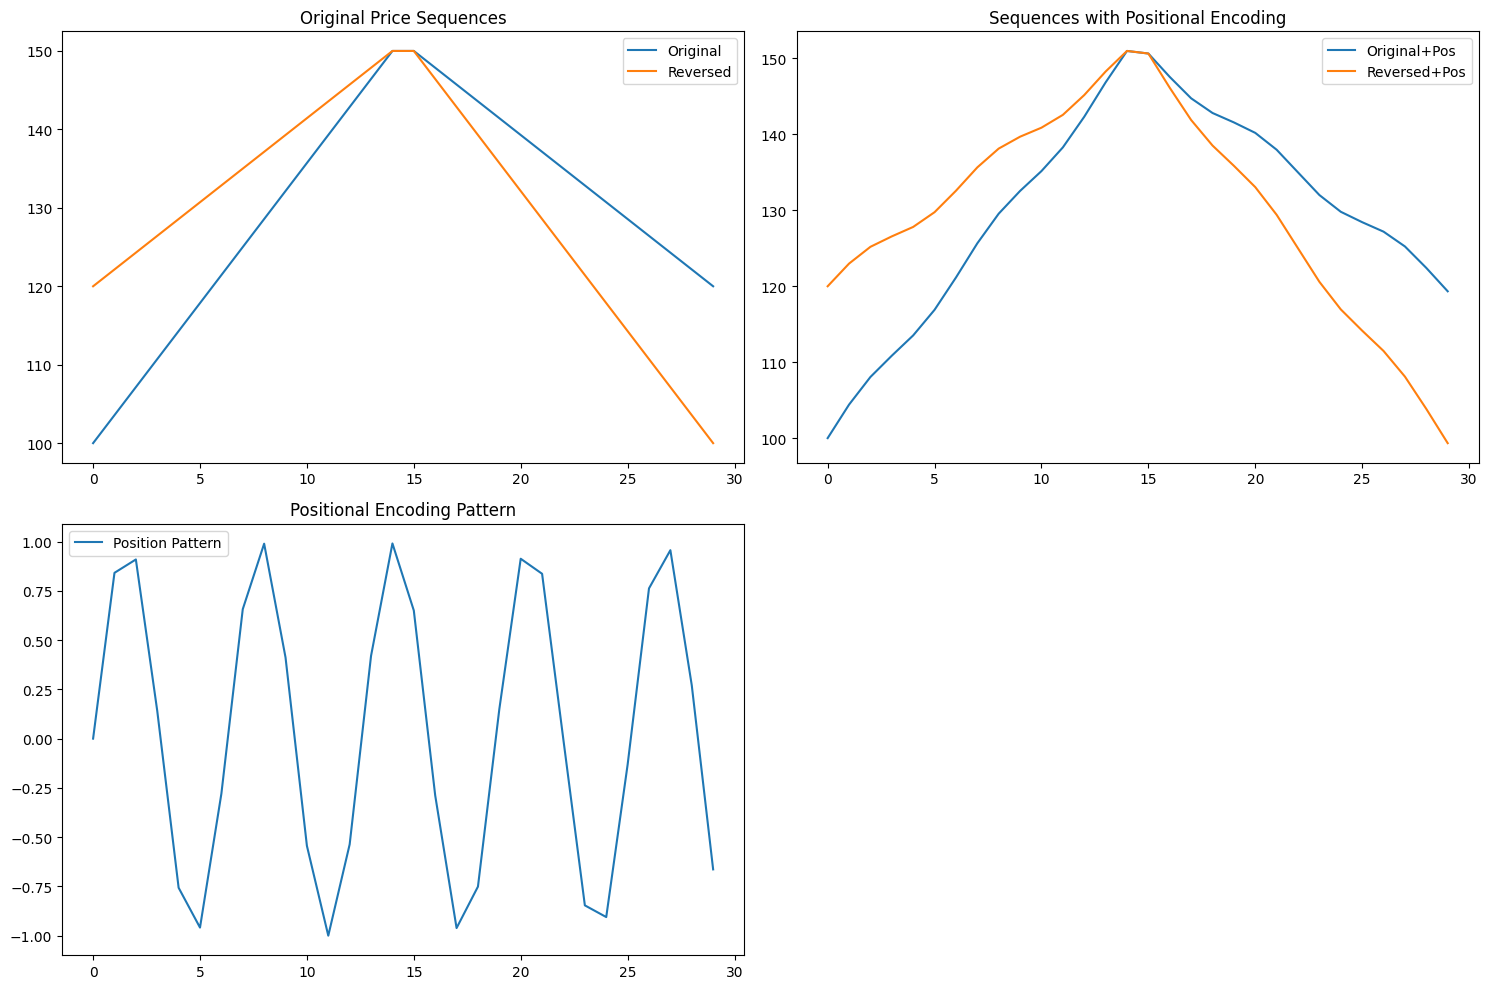


How this affects stock price prediction:
1. Original sequences have same values but different order
2. After positional encoding:
   - Each timestep gets unique position-dependent modification
   - Transformer can now distinguish early vs late timesteps

Pattern recognition with position awareness:
Early in sequence (uptrend):
Original values: [100.     103.5714 107.1429 110.7143 114.2857]
Position-aware: [100.     104.4129 108.0522 110.8554 113.5289]

Late in sequence (downtrend):
Original values: [139.2857 137.1429 135.     132.8571 130.7143]
Position-aware: [140.1987 137.9795 134.9911 132.0109 129.8087]

Key benefits for stock prediction:
1. Pattern context: Same price pattern means different things at different times
2. Trend awareness: Can learn beginning vs middle vs end of trends
3. Sequence memory: Can associate patterns with their position in historical data
4. Order preservation: Maintains the crucial temporal order of price movements


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. First, let's create a simple stock price sequence
def create_sample_price_sequence():
    # Create an upward trend followed by a downward trend
    up_trend = np.linspace(100, 150, 15)
    down_trend = np.linspace(150, 120, 15)
    price_sequence = np.concatenate([up_trend, down_trend])
    return torch.FloatTensor(price_sequence)

# Create two identical sequences but in different order
sequence1 = create_sample_price_sequence()
sequence2 = torch.flip(sequence1, [0])  # Same values, reversed order

print("Original sequence (uptrend then downtrend):")
print(sequence1[:5])  # Show first 5 values
print("\nReversed sequence (downtrend then uptrend):")
print(sequence2[:5])  # Show first 5 values

# Add positional encoding
pos_enc = PositionalEncoding(config)

# Prepare sequences for transformer (add batch and feature dimensions)
seq1_prepared = sequence1.view(1, -1, 1)  # [batch=1, seq_len=30, features=1]
seq2_prepared = sequence2.view(1, -1, 1)

# Add positional encoding
seq1_encoded = pos_enc(seq1_prepared)
seq2_encoded = pos_enc(seq2_prepared)

# Visualize
plt.figure(figsize=(15, 10))

# Original sequences
plt.subplot(2, 2, 1)
plt.plot(sequence1.numpy(), label='Original')
plt.plot(sequence2.numpy(), label='Reversed')
plt.title('Original Price Sequences')
plt.legend()

# Encoded sequences
plt.subplot(2, 2, 2)
plt.plot(seq1_encoded[0, :, 0].detach().numpy(), label='Original+Pos')
plt.plot(seq2_encoded[0, :, 0].detach().numpy(), label='Reversed+Pos')
plt.title('Sequences with Positional Encoding')
plt.legend()

# Position-aware patterns
plt.subplot(2, 2, 3)
plt.plot(pos_enc.pe[0, :30, 0].numpy(), label='Position Pattern')
plt.title('Positional Encoding Pattern')
plt.legend()

plt.tight_layout()
plt.show()

print("\nHow this affects stock price prediction:")
print("1. Original sequences have same values but different order")
print("2. After positional encoding:")
print("   - Each timestep gets unique position-dependent modification")
print("   - Transformer can now distinguish early vs late timesteps")

# Now let's show how this helps predict next price
def simulate_prediction(sequence, position):
    """Simulate how transformer would use position-aware data"""
    # Get the last 5 positions of each sequence
    orig_pattern = sequence[position-5:position]
    pos_pattern = seq1_encoded[0, position-5:position, 0].detach()
    
    return orig_pattern, pos_pattern

# Compare patterns at different positions
early_orig, early_pos = simulate_prediction(sequence1, 5)
late_orig, late_pos = simulate_prediction(sequence1, 25)

print("\nPattern recognition with position awareness:")
print("Early in sequence (uptrend):")
print(f"Original values: {early_orig.numpy()}")
print(f"Position-aware: {early_pos.numpy()}")
print("\nLate in sequence (downtrend):")
print(f"Original values: {late_orig.numpy()}")
print(f"Position-aware: {late_pos.numpy()}")

# This helps transformer learn:
print("\nKey benefits for stock prediction:")
print("1. Pattern context: Same price pattern means different things at different times")
print("2. Trend awareness: Can learn beginning vs middle vs end of trends")
print("3. Sequence memory: Can associate patterns with their position in historical data")
print("4. Order preservation: Maintains the crucial temporal order of price movements")

Original pattern: tensor([1., 2., 3., 4., 5.])

Sequence with repeated pattern:
At start (0-4): tensor([1., 2., 3., 4., 5.])
In middle (15-19): tensor([1., 2., 3., 4., 5.])
At end (25-29): tensor([1., 2., 3., 4., 5.])
Positional encoding shape: torch.Size([1, 60, 64])

After positional encoding:
Same pattern at start:
[1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     1.     2.     1.     2.     1.     2.
 1.     2.     1.     2.     2.8415 2.5403 2.6816 2.7318 2.5332 2.846
 2.4093 2.9124 2.311  2.9504 2.2349 2.972  2.1769 2.9842 2.133  2.9911
 2.0998 2.995  2.0749 2.9972 2.0562 2.9984 2.0422 2.9991 2.0316 2.9995
 2.0237 2.9997 2.0178 2.9998 2.0133 2.9999 2.01   2.9999 2.0075 3.

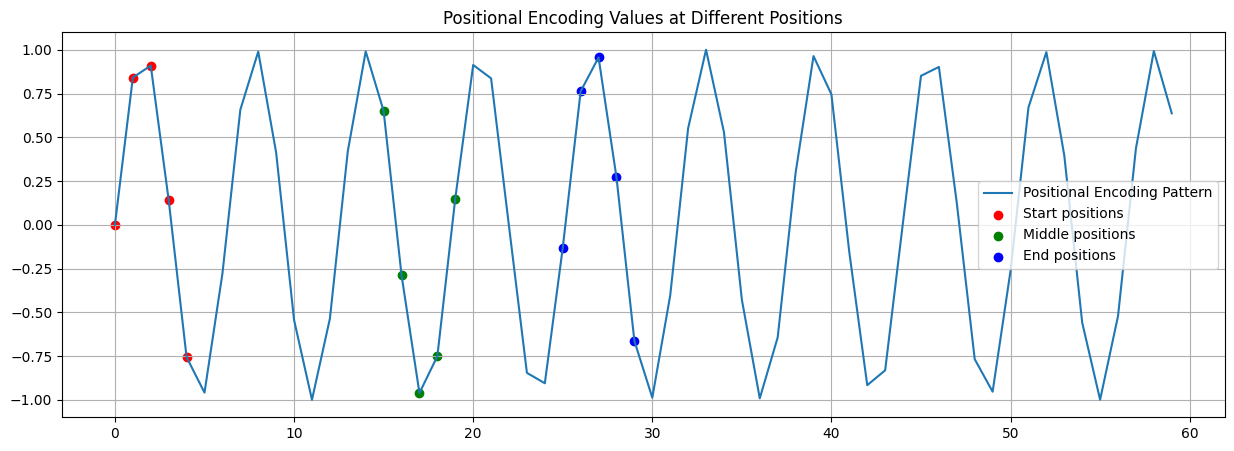

In [ ]:
# Let's create a simple example with the SAME values at DIFFERENT positions
import torch
import numpy as np

# Create a simple pattern that repeats
pattern = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print("Original pattern:", pattern)

# Put this same pattern at different positions in a sequence
sequence = torch.zeros(30, 1)  # sequence length 30, 1 feature
sequence[0:5] = pattern.view(-1, 1)       # Pattern at start
sequence[15:20] = pattern.view(-1, 1)     # Same pattern in middle
sequence[25:30] = pattern.view(-1, 1)     # Same pattern at end

print("\nSequence with repeated pattern:")
print("At start (0-4):", sequence[0:5].flatten())
print("In middle (15-19):", sequence[15:20].flatten())
print("At end (25-29):", sequence[25:30].flatten())

# Add positional encoding
pos_enc = PositionalEncoding(config)
sequence = sequence.unsqueeze(0)  # Add batch dimension [1, 30, 1]

# Get the positional encoding values only
pos_encoded = pos_enc(sequence)

print("\nAfter positional encoding:")
print("Same pattern at start:")
print(pos_encoded[0, 0:5].flatten().detach().numpy())
print("\nSame pattern in middle:")
print(pos_encoded[0, 15:20].flatten().detach().numpy())
print("\nSame pattern at end:")
print(pos_encoded[0, 25:30].flatten().detach().numpy())

# Let's look at the actual positional components being added
pe_only = pos_enc.pe[0, :, 0]  # Get first feature's positional encoding
print("\nPositional encoding values being added:")
print("At start:", pe_only[0:5].numpy())
print("In middle:", pe_only[15:20].numpy())
print("At end:", pe_only[25:30].numpy())

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(pe_only.numpy(), label='Positional Encoding Pattern')
plt.scatter(range(0,5), pe_only[0:5], color='red', label='Start positions')
plt.scatter(range(15,20), pe_only[15:20], color='green', label='Middle positions')
plt.scatter(range(25,30), pe_only[25:30], color='blue', label='End positions')
plt.title('Positional Encoding Values at Different Positions')
plt.legend()
plt.grid(True)
plt.show()

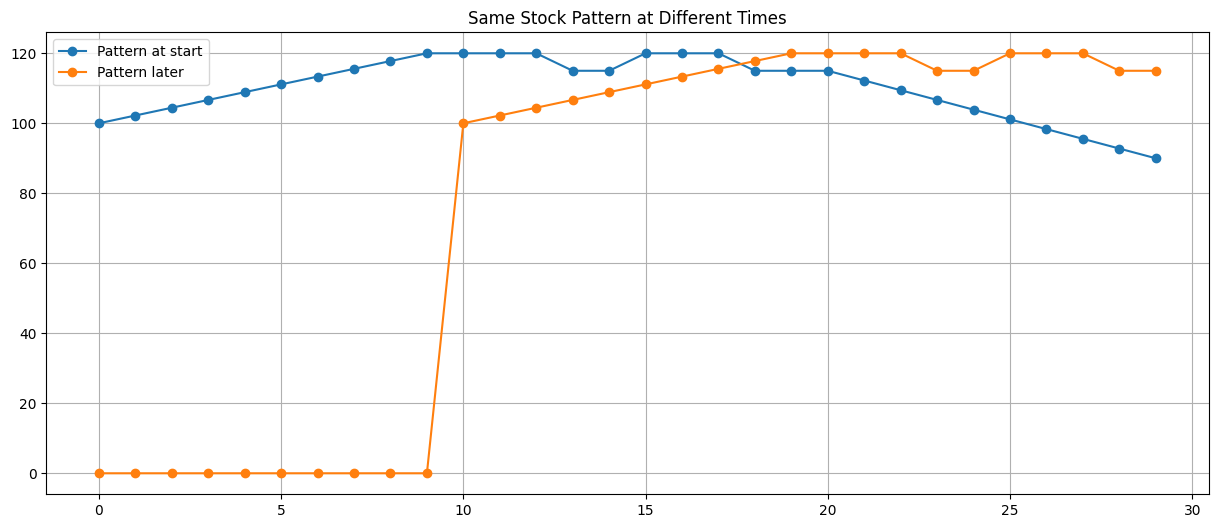

Positional encoding shape: torch.Size([1, 60, 64])


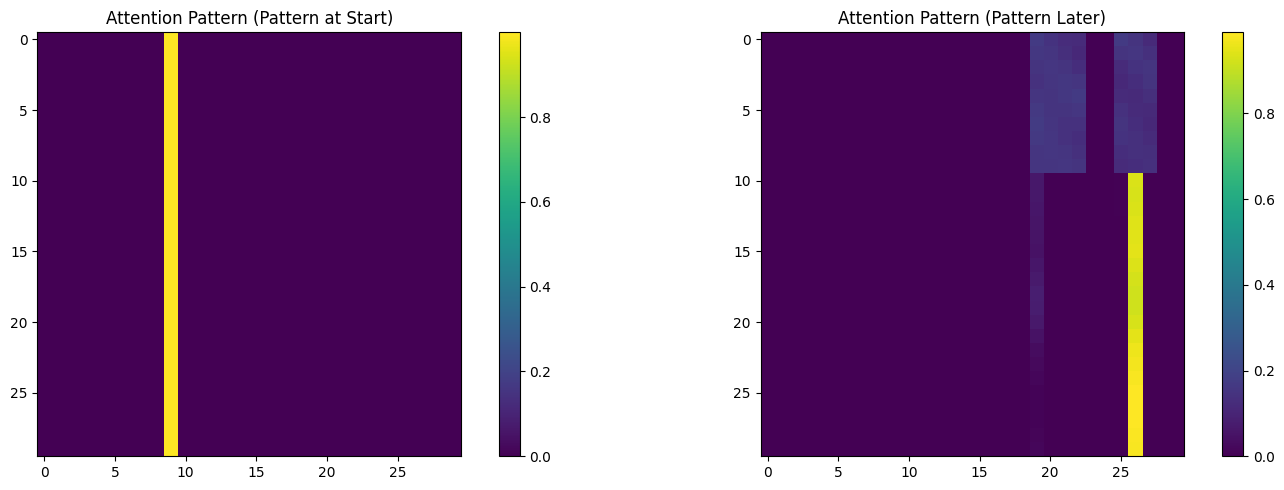


Comparing attention for same pattern point at different times:

Analyzing position 5:
Price value: 111.11
Attends most strongly to positions: [15 11 10 12  9]

Analyzing position 15:
Price value: 111.11
Attends most strongly to positions: [27 20 25 19 26]


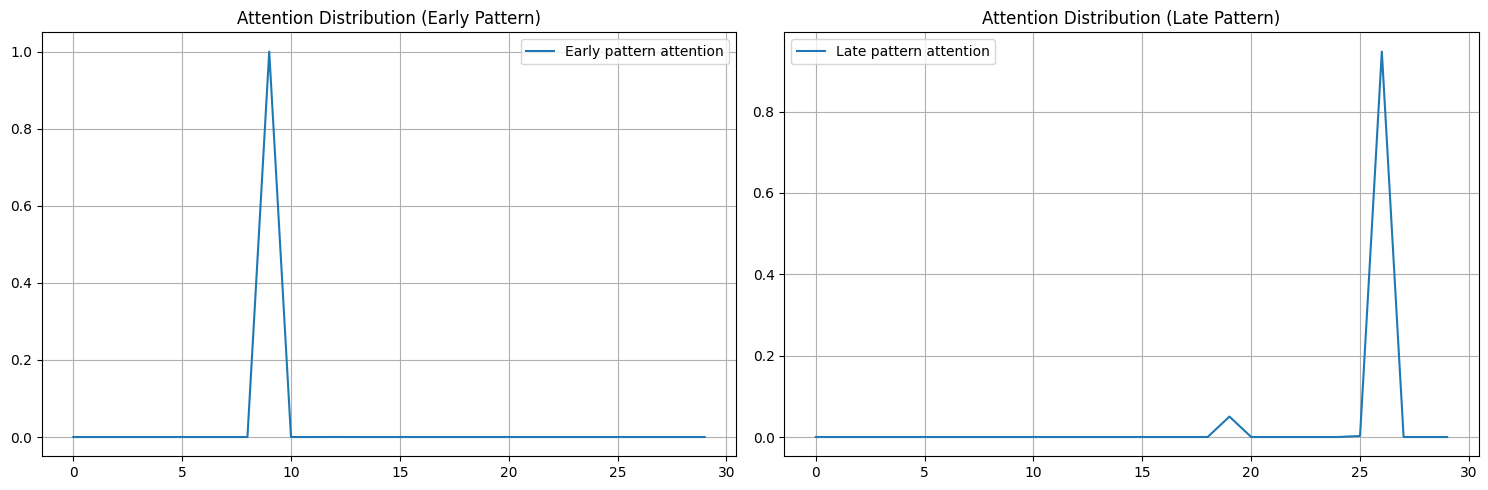


Pattern Recognition Implications:
1. Early pattern attention can only look at previous few positions
2. Late pattern can look at longer history
3. Attention weights show temporal dependencies:
   - Early pattern: Limited context
   - Late pattern: Can consider full history

Real Stock Pattern Examples:
1. Double Top Pattern:
   - Early in session: Might indicate opening range breakout
   - Late in session: Might indicate trend reversal

2. Volume Spike:
   - Early: Often indicates trend direction for the day
   - Late: Might indicate exhaustion or reversal


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Create a simple stock pattern: uptrend, double top, downtrend
def create_stock_pattern(start_price=100):
    # Uptrend
    uptrend = np.linspace(start_price, start_price * 1.2, 10)
    # Double top
    double_top = np.array([start_price * 1.2] * 3 + [start_price * 1.15] * 2 + 
                         [start_price * 1.2] * 3 + [start_price * 1.15] * 2)
    # Downtrend
    downtrend = np.linspace(start_price * 1.15, start_price * 0.9, 10)
    
    pattern = np.concatenate([uptrend, double_top, downtrend])
    return torch.FloatTensor(pattern)

# Create two sequences with same pattern at different times
seq1 = create_stock_pattern(100)  # Pattern starts at beginning
seq2 = torch.zeros_like(seq1)
seq2[10:] = create_stock_pattern(100)[:20]  # Same pattern starts later

# Visualize the sequences
plt.figure(figsize=(15, 6))
plt.plot(seq1.numpy(), label='Pattern at start', marker='o')
plt.plot(seq2.numpy(), label='Pattern later', marker='o')
plt.title('Same Stock Pattern at Different Times')
plt.legend()
plt.grid(True)
plt.show()

# Add positional encoding
d_model = 64
pos_enc = PositionalEncoding(config)

# Prepare sequences for transformer
seq1_prep = seq1.view(1, -1, 1).repeat(1, 1, d_model)
seq2_prep = seq2.view(1, -1, 1).repeat(1, 1, d_model)

seq1_encoded = pos_enc(seq1_prep)
seq2_encoded = pos_enc(seq2_prep)

# Compute self-attention for both sequences
def compute_attention(seq_encoded):
    # Simple self-attention computation
    Q = seq_encoded
    K = seq_encoded
    V = seq_encoded
    
    # Compute attention scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(d_model)
    attention = torch.softmax(scores, dim=-1)
    
    return attention[0].detach().numpy()  # Remove batch dimension

att1 = compute_attention(seq1_encoded)
att2 = compute_attention(seq2_encoded)

# Visualize attention patterns
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(att1, cmap='viridis')
plt.title('Attention Pattern (Pattern at Start)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(att2, cmap='viridis')
plt.title('Attention Pattern (Pattern Later)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Analyze specific positions in the pattern
def analyze_position(sequence, attention, position):
    print(f"\nAnalyzing position {position}:")
    print(f"Price value: {sequence[position]:.2f}")
    print("Attends most strongly to positions:", 
          np.argsort(attention[position])[-5:])  # Top 5 attended positions
    return attention[position]

# Compare same pattern point at different times
pattern_point = 5  # e.g., middle of uptrend
late_pattern_point = 15  # same point but in later sequence

print("\nComparing attention for same pattern point at different times:")
att1_early = analyze_position(seq1, att1, pattern_point)
att2_late = analyze_position(seq2, att2, pattern_point + 10)

# Visualize attention differences
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(att1_early, label='Early pattern attention')
plt.title('Attention Distribution (Early Pattern)')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(att2_late, label='Late pattern attention')
plt.title('Attention Distribution (Late Pattern)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Show how this helps with stock pattern recognition
print("\nPattern Recognition Implications:")
print("1. Early pattern attention can only look at previous few positions")
print("2. Late pattern can look at longer history")
print("3. Attention weights show temporal dependencies:")
print("   - Early pattern: Limited context")
print("   - Late pattern: Can consider full history")

# Real stock pattern examples
print("\nReal Stock Pattern Examples:")
print("1. Double Top Pattern:")
print("   - Early in session: Might indicate opening range breakout")
print("   - Late in session: Might indicate trend reversal")
print("\n2. Volume Spike:")
print("   - Early: Often indicates trend direction for the day")
print("   - Late: Might indicate exhaustion or reversal")


Position 0 encoding:
[0. 1. 0. 1.]

Position 10 encoding:
[-0.544   0.5403  0.0998  1.    ]

Position 20 encoding:
[ 0.9129 -0.4161  0.1987  0.9998]


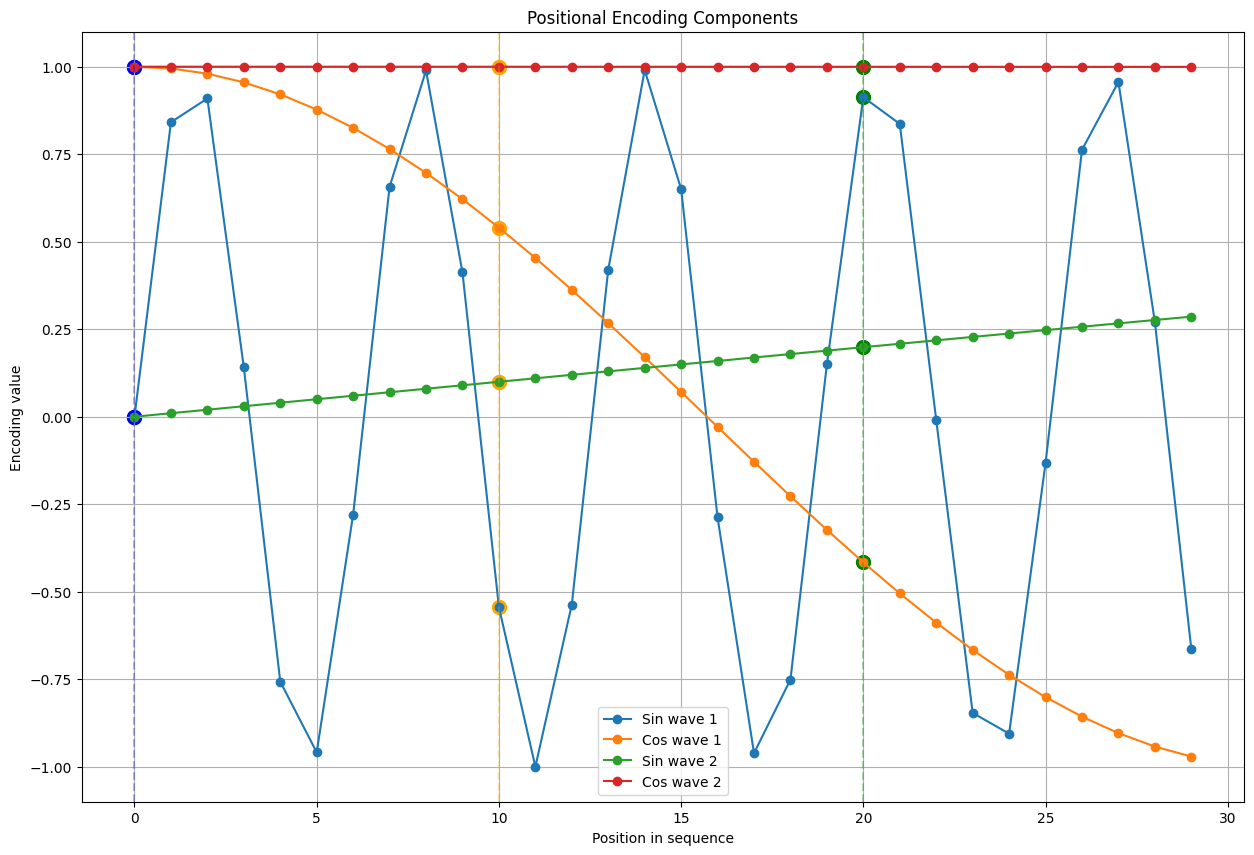


Let's compare positions 10 and 20:

Position 10 signature: tensor([-0.5440,  0.5403,  0.0998,  1.0000])
Position 20 signature: tensor([ 0.9129, -0.4161,  0.1987,  0.9998])

Similarity between positions:
Positions 0 and 10: 0.862
Positions 0 and 20: 0.289
Positions 10 and 20: 0.165


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

def create_multi_frequency_encoding(max_len=30, n_freq=4):
    # Create position vector [max_len, 1]
    positions = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    
    # Create frequency vector [1, n_freq]
    freqs = 1.0 / (10000 ** (torch.arange(0, n_freq, dtype=torch.float) / n_freq))
    freqs = freqs.unsqueeze(0)  # Make it 2D for broadcasting
    
    # Calculate angle for each position-frequency combination [max_len, n_freq]
    angles = positions @ freqs
    
    # Initialize positional encoding matrix
    pe = torch.zeros(max_len, n_freq)
    
    # Alternate between sin and cos
    pe[:, 0::2] = torch.sin(angles[:, 0::2])
    pe[:, 1::2] = torch.cos(angles[:, 1::2])
    
    return pe

# Test and visualize
pe = create_multi_frequency_encoding()

plt.figure(figsize=(15, 10))

# Plot each frequency component
for i in range(pe.shape[1]):
    plt.plot(pe[:, i].numpy(), 
            label=f'{"Sin" if i%2==0 else "Cos"} wave {i//2+1}', 
            marker='o')

# Mark specific positions
positions = [0, 10, 20]
colors = ['blue', 'orange', 'green']

for pos, color in zip(positions, colors):
    plt.axvline(x=pos, color=color, linestyle='--', alpha=0.3)
    # Plot points at this position
    for i in range(pe.shape[1]):
        plt.scatter(pos, pe[pos, i], color=color, s=100)
    
    print(f"\nPosition {pos} encoding:")
    print(pe[pos].numpy())

plt.title('Positional Encoding Components')
plt.grid(True)
plt.legend()
plt.xlabel('Position in sequence')
plt.ylabel('Encoding value')

plt.show()

# Show how this makes each position unique
print("\nLet's compare positions 10 and 20:")
print("\nPosition 10 signature:", pe[10])
print("Position 20 signature:", pe[20])

# Calculate similarity between positions
def positional_similarity(pe, pos1, pos2):
    # Cosine similarity
    cos_sim = torch.nn.functional.cosine_similarity(
        pe[pos1].unsqueeze(0), 
        pe[pos2].unsqueeze(0)
    )
    return cos_sim.item()

# Compare similarities
print("\nSimilarity between positions:")
for i in range(0, 30, 10):
    for j in range(i+10, 30, 10):
        sim = positional_similarity(pe, i, j)
        print(f"Positions {i} and {j}: {sim:.3f}")

[*********************100%***********************]  1 of 1 completed


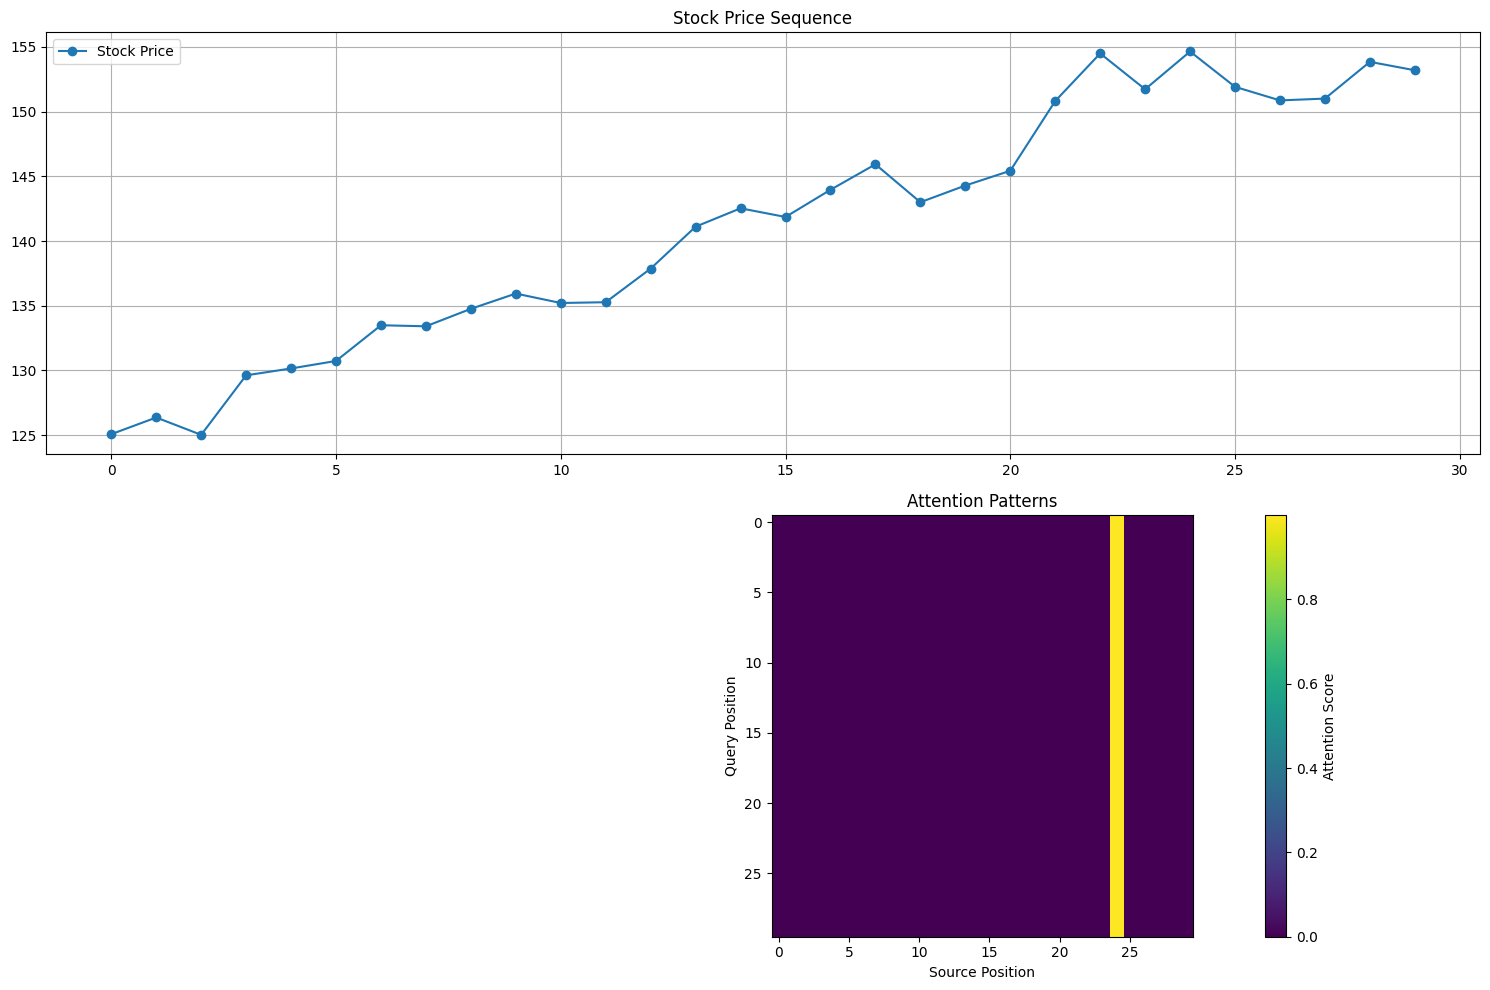


Analyzing attention patterns at different positions:

Position 5 (Price: $130.73):
Attends to position 24 (Price: $154.65) with weight 1.000
Attends to position 22 (Price: $154.50) with weight 0.000
Attends to position 28 (Price: $153.85) with weight 0.000

Position 15 (Price: $141.86):
Attends to position 24 (Price: $154.65) with weight 1.000
Attends to position 22 (Price: $154.50) with weight 0.000
Attends to position 28 (Price: $153.85) with weight 0.000

Position 25 (Price: $151.92):
Attends to position 24 (Price: $154.65) with weight 1.000
Attends to position 22 (Price: $154.50) with weight 0.000
Attends to position 28 (Price: $153.85) with weight 0.000


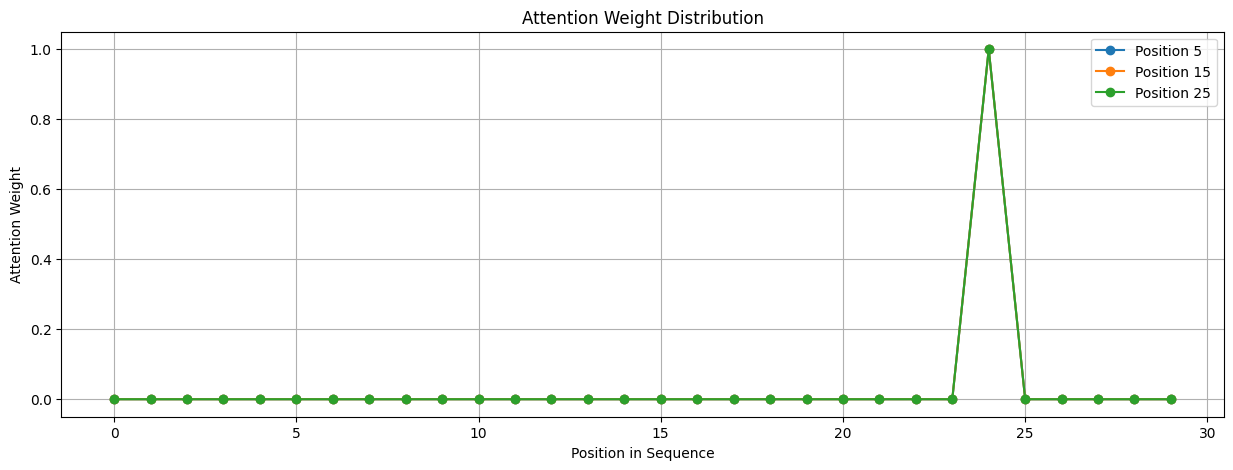


Significant Price Movements and Attention Patterns:

Price movement at position 3:
Change: 3.68%
Before: $125.02
After: $129.62

Most attended previous positions:
Position 2 ($125.02) - Attention: 0.000
Position 1 ($126.36) - Attention: 0.000
Position 0 ($125.07) - Attention: 0.000

Price movement at position 6:
Change: 2.11%
Before: $130.73
After: $133.49

Most attended previous positions:
Position 5 ($130.73) - Attention: 0.000
Position 4 ($130.15) - Attention: 0.000
Position 3 ($129.62) - Attention: 0.000


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Get stock data
def get_stock_data(symbol='AAPL', start='2023-01-01', end='2023-12-31'):
    stock = yf.download(symbol, start=start, end=end)
    prices = stock['Close'].values
    return prices

def create_sequences(data, seq_length=30):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i+seq_length])
    return np.array(sequences)

# 2. Position-aware attention mechanism
class PositionAwareAttention(nn.Module):  # Now inherits from nn.Module
    def __init__(self, seq_length=30, d_model=4):
        super().__init__()  # Call parent constructor
        self.seq_length = seq_length
        self.d_model = d_model
        
        # Create positional encoding
        positions = torch.arange(seq_length, dtype=torch.float).unsqueeze(1)
        freqs = 1.0 / (10000 ** (torch.arange(0, d_model, dtype=torch.float) / d_model))
        freqs = freqs.unsqueeze(0)
        
        angles = positions @ freqs
        pe = torch.zeros(seq_length, d_model)
        pe[:, 0::2] = torch.sin(angles[:, 0::2])
        pe[:, 1::2] = torch.cos(angles[:, 1::2])
        
        self.register_buffer('pe', pe)

    def forward(self, sequence):
        # Add positional encoding to sequence
        seq_tensor = torch.FloatTensor(sequence).unsqueeze(-1)
        # Repeat the positional encoding for each feature
        pos_encoding = self.pe.repeat(1, 1)
        seq_encoded = torch.cat([seq_tensor, pos_encoding], dim=-1)
        
        # Compute attention scores
        scores = torch.matmul(seq_encoded, seq_encoded.transpose(-2, -1))
        scores = scores / np.sqrt(self.d_model)
        attention = torch.softmax(scores, dim=-1)
        
        return attention

# Get data and create sequences
prices = get_stock_data()
sequences = create_sequences(prices)

# Analyze and visualize attention patterns
def visualize_attention_patterns(sequence, attention):
    plt.figure(figsize=(15, 10))
    
    # Plot original price sequence
    plt.subplot(2, 1, 1)
    plt.plot(sequence, label='Stock Price', marker='o')
    plt.title('Stock Price Sequence')
    plt.grid(True)
    plt.legend()
    
    # Plot attention heatmap
    plt.subplot(2, 1, 2)
    plt.imshow(attention, cmap='viridis')
    plt.colorbar(label='Attention Score')
    plt.title('Attention Patterns')
    plt.xlabel('Source Position')
    plt.ylabel('Query Position')
    
    plt.tight_layout()
    plt.show()

# Take a sample sequence and compute attention
sequence_idx = 0
sample_sequence = sequences[sequence_idx]
attention_mechanism = PositionAwareAttention()
attention_matrix = attention_mechanism(sample_sequence).detach().numpy()

# Visualize the patterns
visualize_attention_patterns(sample_sequence, attention_matrix)

# Analyze specific positions
def analyze_positions(sequence, attention_matrix, positions=[5, 15, 25]):
    print("\nAnalyzing attention patterns at different positions:")
    
    plt.figure(figsize=(15, 5))
    
    for pos in positions:
        attention_weights = attention_matrix[pos]
        plt.plot(attention_weights, label=f'Position {pos}', marker='o')
        
        # Show what this position is attending to
        print(f"\nPosition {pos} (Price: ${sequence[pos]:.2f}):")
        # Get top 3 attended positions
        top_attended = np.argsort(attention_weights)[-3:]
        for att_pos in reversed(top_attended):
            print(f"Attends to position {att_pos} (Price: ${sequence[att_pos]:.2f}) "
                  f"with weight {attention_weights[att_pos]:.3f}")
    
    plt.title('Attention Weight Distribution')
    plt.xlabel('Position in Sequence')
    plt.ylabel('Attention Weight')
    plt.grid(True)
    plt.legend()
    plt.show()

# Analyze positions
analyze_positions(sample_sequence, attention_matrix)

# Show how attention helps with pattern recognition
def show_price_patterns(sequence, attention_matrix):
    # Calculate returns
    returns = np.diff(sequence) / sequence[:-1]
    significant_moves = np.where(np.abs(returns) > np.std(returns))[0]
    
    print("\nSignificant Price Movements and Attention Patterns:")
    for pos in significant_moves[:2]:  # Look at first two significant moves
        pos = pos + 1  # Adjust for the diff operation
        
        print(f"\nPrice movement at position {pos}:")
        print(f"Change: {returns[pos-1]*100:.2f}%")
        print(f"Before: ${sequence[pos-1]:.2f}")
        print(f"After: ${sequence[pos]:.2f}")
        
        # Show attention pattern
        attention_weights = attention_matrix[pos]
        print("\nMost attended previous positions:")
        top_k = 3
        top_positions = np.argsort(attention_weights[:pos])[-top_k:]
        for prev_pos in reversed(top_positions):
            print(f"Position {prev_pos} (${sequence[prev_pos]:.2f}) "
                  f"- Attention: {attention_weights[prev_pos]:.3f}")

# Show patterns
show_price_patterns(sample_sequence, attention_matrix)

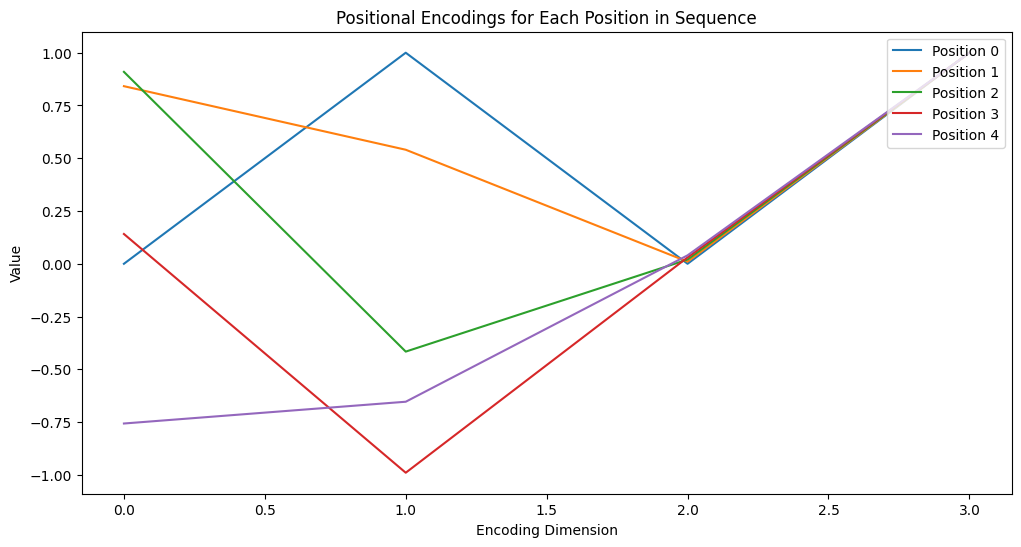

In [ ]:
# Cell: Visualize sine and cosine patterns in positional encoding
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_positional_encoding(seq_length, d_model):
    positions = torch.arange(seq_length).float().unsqueeze(1)
    freqs = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))
    angles = positions @ freqs.unsqueeze(0)
    
    # Sine and cosine application
    pos_encoding = torch.zeros(seq_length, d_model)
    pos_encoding[:, 0::2] = torch.sin(angles)
    pos_encoding[:, 1::2] = torch.cos(angles)

    # Plot positional encodings for first few positions
    plt.figure(figsize=(12, 6))
    for i in range(seq_length):
        plt.plot(pos_encoding[i].numpy(), label=f"Position {i}")
    plt.legend(loc="upper right")
    plt.title("Positional Encodings for Each Position in Sequence")
    plt.xlabel("Encoding Dimension")
    plt.ylabel("Value")
    plt.show()

# Visualize encoding for a short sequence
visualize_positional_encoding(seq_length=5, d_model=4)


In [ ]:
# Re-create positional encoding with higher dimensionality
import torch
import numpy as np
torch.set_printoptions(sci_mode=False, precision=4)

# Parameters
sequence_length = 5  # Number of positions in the sequence
d_model = 16  # Increased number of encoding dimensions

# Function to create positional encoding
def create_position_encoding(seq_length, d_model):
    positions = torch.arange(seq_length).float().unsqueeze(1)  # Shape: [seq_length, 1]
    freqs = 1.0 / (10000 ** (torch.arange(0, d_model, 2).float() / d_model))  # Shape: [d_model/2]
    angles = positions @ freqs.unsqueeze(0)  # Shape: [seq_length, d_model/2]
    
    # Final encoding with sine and cosine
    pos_encoding = torch.zeros(seq_length, d_model)
    pos_encoding[:, 0::2] = torch.sin(angles)  # Sine for even indices
    pos_encoding[:, 1::2] = torch.cos(angles)  # Cosine for odd indices
    
    return pos_encoding

# Generate positional encoding
pos_encoding = create_position_encoding(sequence_length, d_model)

print("Positional encoding with d_model = 16:")
print(pos_encoding)

# Function to compute attention scores, defined previously
def compute_attention_demo(query_pos, pos_encoding, d_model):
    """Calculate and display attention scores for a given query position across all keys."""
    query = pos_encoding[query_pos]
    
    # Compute dot product attention scores
    scores = torch.tensor([torch.dot(query, pos_encoding[key]) for key in range(len(pos_encoding))]) / np.sqrt(d_model)
    weights = torch.softmax(scores, dim=0)
    
    print(f"Attention scores for query position {query_pos} with each key position:")
    print(scores)
    print("\nNormalized attention weights:")
    print(weights)
    
    return weights

# Use position 3 as the query and observe scores with others
query_position = 3
_ = compute_attention_demo(query_position, pos_encoding, d_model=16)


Positional encoding with d_model = 16:
tensor([[     0.0000,      1.0000,      0.0000,      1.0000,      0.0000,
              1.0000,      0.0000,      1.0000,      0.0000,      1.0000,
              0.0000,      1.0000,      0.0000,      1.0000,      0.0000,
              1.0000],
        [     0.8415,      0.5403,      0.3110,      0.9504,      0.0998,
              0.9950,      0.0316,      0.9995,      0.0100,      1.0000,
              0.0032,      1.0000,      0.0010,      1.0000,      0.0003,
              1.0000],
        [     0.9093,     -0.4161,      0.5911,      0.8066,      0.1987,
              0.9801,      0.0632,      0.9980,      0.0200,      0.9998,
              0.0063,      1.0000,      0.0020,      1.0000,      0.0006,
              1.0000],
        [     0.1411,     -0.9900,      0.8126,      0.5828,      0.2955,
              0.9553,      0.0947,      0.9955,      0.0300,      0.9996,
              0.0095,      1.0000,      0.0030,      1.0000,      0.0009,
    

In [ ]:
# Define raw values (e.g., a simplified sequence of prices)
values = torch.tensor([100.0, 101.0, 102.0, 103.0, 104.0])

# Function to compute attention scores without positional encoding
def compute_attention_no_pos_encoding(query_pos, values, d_model):
    """Compute attention scores without positional encoding."""
    query = values[query_pos]
    
    # Calculate dot product-based attention scores using raw values
    scores = torch.tensor([query * values[key] for key in range(len(values))]) / np.sqrt(d_model)
    weights = torch.softmax(scores, dim=0)
    
    print(f"Attention scores for query position {query_pos} without positional encoding:")
    print(scores)
    print("\nNormalized attention weights:")
    print(weights)
    
    return weights

# Compute attention scores for position 3 without positional encoding
query_position = 3
_ = compute_attention_no_pos_encoding(query_position, values, d_model=16)


Attention scores for query position 3 without positional encoding:
tensor([2575.0000, 2600.7500, 2626.5000, 2652.2500, 2678.0000])

Normalized attention weights:
tensor([    0.0000,     0.0000,     0.0000,     0.0000,     1.0000])


In [ ]:
# Cell: Calculate attention scores for each position with higher-dimensional encoding
def compute_attention_demo(query_pos, pos_encoding, d_model):
    """Calculate and display attention scores for a given query position across all keys."""
    query = pos_encoding[query_pos]
    
    # Compute dot product attention scores
    scores = torch.tensor([torch.dot(query, pos_encoding[key]) for key in range(len(pos_encoding))]) / np.sqrt(d_model)
    weights = torch.softmax(scores, dim=0)
    
    print(f"Attention scores for query position {query_pos} with each key position:")
    print(scores)
    print("\nNormalized attention weights:")
    print(weights)
    
    return weights

# Use position 3 as the query and observe scores with others
query_position = 3
_ = compute_attention_demo(query_position, pos_encoding=torch.tensor(pos_encoding), d_model=16)


NameError: name 'pos_encoding' is not defined

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        d_model = config['d_model']
        max_len = config['sequence_length'] * 2  # Some buffer for max length
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class TransformerGenerator(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        
        self.sequence_length = config['sequence_length']
        self.d_model = config['d_model']
        
        # Project noise to sequence
        self.noise_projection = nn.Linear(
            config['noise_dim'], 
            config['sequence_length'] * config['d_model']
        )
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(config)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            config['n_layers']
        )
        
        # Output projection (to OHLCV)
        self.output_proj = nn.Linear(
            config['d_model'], 
            len(config['features'])
        )
        
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        batch_size = z.size(0)
        
        x = self.noise_projection(z)
        x = x.view(batch_size, self.sequence_length, self.d_model)
        
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.output_proj(x)
        
        return x

class TransformerDiscriminator(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        
        self.sequence_length = config['sequence_length']
        self.d_model = config['d_model']
        
        # Input projection
        self.input_proj = nn.Linear(
            len(config['features']), 
            config['d_model']
        )
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(config)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['n_heads'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer, 
            config['n_layers']
        )
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(config['sequence_length'] * config['d_model'], 
                     config['dim_feedforward']),
            nn.LeakyReLU(0.2),
            nn.Linear(config['dim_feedforward'], 1),
            nn.Sigmoid()
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.reshape(batch_size, -1)
        x = self.output_proj(x)
        
        return x

# Test the discriminator
discriminator = TransformerDiscriminator(config)
with torch.no_grad():
    discrimination = discriminator(generated_sequence)

print("\nDiscriminator test:")
print(f"Input sequence shape: {generated_sequence.shape}")
print(f"Discrimination output shape: {discrimination.shape}")

# Test the generator
generator = TransformerGenerator(config)
test_noise = torch.randn(config['batch_size'], config['noise_dim'])

with torch.no_grad():
    generated_sequence = generator(test_noise)

print("\nGenerator test:")
print(f"Input noise shape: {test_noise.shape}")
print(f"Generated sequence shape: {generated_sequence.shape}")

NameError: name 'generated_sequence' is not defined

In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:x.size(0)]

class TransformerGenerator(nn.Module):
    def __init__(self, 
                 sequence_length: int = 30,
                 noise_dim: int = 100,
                 d_model: int = 64,
                 nhead: int = 4,
                 num_layers: int = 3,
                 dim_feedforward: int = 256):
        super().__init__()
        
        self.sequence_length = sequence_length
        self.d_model = d_model
        
        # Project noise to sequence
        self.noise_projection = nn.Linear(noise_dim, sequence_length * d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Output projection (to OHLCV)
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, 5),  # 4 for OHLC, 1 for Volume
            nn.Tanh()  # Keep outputs in [-1, 1] range
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # z shape: (batch_size, noise_dim)
        batch_size = z.size(0)
        
        # Project and reshape noise
        x = self.noise_projection(z)
        x = x.view(batch_size, self.sequence_length, self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transform
        x = self.transformer(x)
        
        # Project to output space
        x = self.output_proj(x)
        
        return x

# Test Generator
generator = TransformerGenerator()
test_batch_size = 4
test_noise = torch.randn(test_batch_size, 100)  # noise_dim = 100

# Generate a sequence
with torch.no_grad():
    generated_sequence = generator(test_noise)

print("Generator Architecture:")
print(generator)
print("\nTest noise shape:", test_noise.shape)
print("Generated sequence shape:", generated_sequence.shape)
print("\nSample generated sequence (first timestep):")
print(generated_sequence[0, 0])  # First sequence, first timestep

RuntimeError: The size of tensor a (30) must match the size of tensor b (4) at non-singleton dimension 1

In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
from pathlib import Path

@dataclass
class GANConfig:
    # Data parameters
    tickers: List[str]
    start_date: str
    end_date: str
    sequence_length: int
    batch_size: int
    
    # Model architecture
    noise_dim: int
    transformer_dim: int
    n_heads: int
    n_layers: int
    dropout: float
    
    # Training parameters
    epochs: int
    learning_rate_gen: float
    learning_rate_disc: float
    beta1: float
    beta2: float
    
    # Optional parameters with defaults
    data_dir: Path = Path("data")
    checkpoint_dir: Path = Path("checkpoints")
    cache_data: bool = True
    
    # Feature dimension will be set after data loading
    feature_dim: Optional[int] = None
    
    @classmethod
    def from_yaml(cls, yaml_path: str) -> 'GANConfig':
        with open(yaml_path, 'r') as f:
            config_dict = yaml.safe_load(f)
            # Convert string paths to Path objects
            config_dict['data_dir'] = Path(config_dict['data_dir'])
            config_dict['checkpoint_dir'] = Path(config_dict['checkpoint_dir'])
            # Set feature_dim to None initially
            config_dict['feature_dim'] = None
        return cls(**config_dict)

class StockDataset(Dataset):
    def __init__(self, config: GANConfig):
        self.config = config
        self.data = {}
        self._load_data()
        self.sequences, self.feature_info = self._prepare_sequences()
        
    def _load_data(self):
        cache_path = self.config.data_dir / "stock_data.pkl"
        
        if self.config.cache_data and cache_path.exists():
            self.data = pd.read_pickle(cache_path)
        else:
            for ticker in self.config.tickers:
                df = yf.download(
                    ticker,
                    start=self.config.start_date,
                    end=self.config.end_date,
                    progress=False
                )
                if not df.empty:
                    self.data[ticker] = df[['Open', 'High', 'Low', 'Close', 'Volume']]
            
            if self.config.cache_data:
                self.config.data_dir.mkdir(parents=True, exist_ok=True)
                pd.to_pickle(self.data, cache_path)
    
    def _prepare_sequences(self) -> Tuple[np.ndarray, Dict]:
        sequences = []
        for ticker, df in self.data.items():
            returns = df.pct_change()
            returns = returns.fillna(0)
            
            for i in range(len(returns) - self.config.sequence_length):
                seq = returns.iloc[i:i+self.config.sequence_length].values
                sequences.append(seq)
        
        sequences = np.array(sequences)
        
        feature_info = {
            'mean': sequences.mean(axis=(0, 1)),
            'std': sequences.std(axis=(0, 1))
        }
        
        normalized = (sequences - feature_info['mean']) / (feature_info['std'] + 1e-8)
        return normalized, feature_info
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.sequences[idx])

class TransformerGenerator(nn.Module):
    def __init__(self, config: GANConfig):
        super().__init__()
        self.config = config
        
        self.noise_projection = nn.Linear(
            config.noise_dim,
            config.sequence_length * config.feature_dim
        )
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.feature_dim,
            nhead=config.n_heads,
            dim_feedforward=config.transformer_dim,
            dropout=config.dropout,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.n_layers
        )
        
    def forward(self, z):
        batch_size = z.size(0)
        x = self.noise_projection(z)
        x = x.view(batch_size, self.config.sequence_length, -1)
        return self.transformer(x)

class Discriminator(nn.Module):
    def __init__(self, config: GANConfig):
        super().__init__()
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.feature_dim,
            nhead=config.n_heads,
            dim_feedforward=config.transformer_dim,
            dropout=config.dropout,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.n_layers
        )
        
        self.fc = nn.Linear(
            config.sequence_length * config.feature_dim,
            1
        )
        
    def forward(self, x):
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

class StockGAN:
    def __init__(self, config: GANConfig):
        self.config = config
        self.dataset = StockDataset(config)
        
        # Update feature_dim based on actual data
        self.config.feature_dim = self.dataset.sequences.shape[2]
        
        self.generator = TransformerGenerator(config)
        self.discriminator = Discriminator(config)
        
        self.g_optimizer = optim.Adam(
            self.generator.parameters(),
            lr=config.learning_rate_gen,
            betas=(config.beta1, config.beta2)
        )
        
        self.d_optimizer = optim.Adam(
            self.discriminator.parameters(),
            lr=config.learning_rate_disc,
            betas=(config.beta1, config.beta2)
        )
        
        self.criterion = nn.BCELoss()
        
    def train(self):
        dataloader = DataLoader(
            self.dataset,
            batch_size=self.config.batch_size,
            shuffle=True
        )
        
        for epoch in range(self.config.epochs):
            total_d_loss = 0
            total_g_loss = 0
            
            for real_sequences in dataloader:
                batch_size = real_sequences.size(0)
                
                # Train Discriminator
                self.d_optimizer.zero_grad()
                label_real = torch.ones(batch_size, 1)
                label_fake = torch.zeros(batch_size, 1)
                
                output_real = self.discriminator(real_sequences)
                d_loss_real = self.criterion(output_real, label_real)
                
                noise = torch.randn(batch_size, self.config.noise_dim)
                fake_sequences = self.generator(noise)
                output_fake = self.discriminator(fake_sequences.detach())
                d_loss_fake = self.criterion(output_fake, label_fake)
                
                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                self.d_optimizer.step()
                
                # Train Generator
                self.g_optimizer.zero_grad()
                output_fake = self.discriminator(fake_sequences)
                g_loss = self.criterion(output_fake, label_real)
                g_loss.backward()
                self.g_optimizer.step()
                
                total_d_loss += d_loss.item()
                total_g_loss += g_loss.item()
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{self.config.epochs}], '
                      f'd_loss: {total_d_loss:.4f}, '
                      f'g_loss: {total_g_loss:.4f}')
    
    def generate_sequences(self, n_sequences: int) -> np.ndarray:
        self.generator.eval()
        with torch.no_grad():
            noise = torch.randn(n_sequences, self.config.noise_dim)
            synthetic = self.generator(noise).numpy()
            
            # Denormalize
            synthetic = (
                synthetic * self.dataset.feature_info['std'] +
                self.dataset.feature_info['mean']
            )
        
        self.generator.train()
        return synthetic

def main():
    # Load configuration
    config = GANConfig.from_yaml('gan_config.yaml')
    
    # Create and train GAN
    gan = StockGAN(config)
    gan.train()
    
    # Generate example sequences
    synthetic_sequences = gan.generate_sequences(n_sequences=5)
    print("Generated sequences shape:", synthetic_sequences.shape)

if __name__ == "__main__":
    main()

/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


KeyboardInterrupt: 

In [ ]:
# Define ticker embedding matrix
ticker_embedding = nn.Embedding(len(config['tickers']), d_model)
ticker_embeddings = ticker_embedding(all_ticker_ids)

# Convert all_sequences to tensor and add ticker embeddings
all_sequences_tensor = torch.FloatTensor(all_sequences)
projected_sequences = torch.matmul(all_sequences_tensor, weight) + bias
data_with_ticker_embedding = projected_sequences + ticker_embeddings.unsqueeze(1)

print("\nProjected data with ticker embeddings shape:", data_with_ticker_embedding.shape)
print("Projected data with ticker embeddings (first sequence):")
print(data_with_ticker_embedding[0])



Projected data with ticker embeddings shape: torch.Size([9, 3, 8])
Projected data with ticker embeddings (first sequence):
tensor([[-0.4533,  0.6700, -1.3251, -0.9743, -1.4720,  0.5257, -0.1541,  0.9602],
        [-0.6235, -0.2185, -1.8338, -2.4000, -1.3795,  0.6012,  0.3259,  0.4412],
        [-2.5382, -0.6544, -1.5122,  0.0243, -1.1583,  0.6623, -0.3955,  0.4707]],
       grad_fn=<SelectBackward0>)


In [ ]:
# Initialize generator components using config
generator_input = torch.randn(config['batch_size'], config['sequence_length'], config['d_model'])
ticker_embed = ticker_embedding(all_ticker_ids[:config['batch_size']])

# Project and apply attention (using previous attention code)
gen_output = final_attention_output  # Shape: [batch_size, seq_length, num_features]

In [ ]:
all_ticker_ids[:config['batch_size']]

tensor([0, 0, 0, 1, 1, 1, 2, 2, 2])

In [ ]:
all_ticker_ids

tensor([0, 0, 0, 1, 1, 1, 2, 2, 2])

In [ ]:
ticker_embed

tensor([[-0.6855,  0.5636, -1.5072, -1.6107, -1.4790,  0.4323, -0.1250,  0.7821],
        [-0.6855,  0.5636, -1.5072, -1.6107, -1.4790,  0.4323, -0.1250,  0.7821],
        [-0.6855,  0.5636, -1.5072, -1.6107, -1.4790,  0.4323, -0.1250,  0.7821],
        [ 0.8637, -0.5890, -1.0340, -0.2179,  0.7987,  0.9105, -0.0880,  0.3370],
        [ 0.8637, -0.5890, -1.0340, -0.2179,  0.7987,  0.9105, -0.0880,  0.3370],
        [ 0.8637, -0.5890, -1.0340, -0.2179,  0.7987,  0.9105, -0.0880,  0.3370],
        [-0.4808,  0.3163,  0.3866,  0.7337,  0.2510,  0.0770, -0.2063,  2.1698],
        [-0.4808,  0.3163,  0.3866,  0.7337,  0.2510,  0.0770, -0.2063,  2.1698],
        [-0.4808,  0.3163,  0.3866,  0.7337,  0.2510,  0.0770, -0.2063,  2.1698]],
       grad_fn=<EmbeddingBackward0>)

In [ ]:
# Cell 1 - Check and convert data types
print("Before conversion:")
print("all_sequences type:", type(all_sequences))
print("all_sequences shape:", all_sequences.shape)

# Convert to tensor if needed
if not isinstance(all_sequences, torch.Tensor):
    all_sequences = torch.FloatTensor(all_sequences)

print("\nAfter conversion:")
print("all_sequences type:", type(all_sequences))
print("all_sequences shape:", all_sequences.shape)

# Cell 2 - Discriminator input
discriminator_projection = torch.randn(
    len(config['features']), 
    config['d_model']
) / np.sqrt(len(config['features']))

disc_input = torch.matmul(all_sequences[:config['batch_size']], discriminator_projection)

print("\nDiscriminator shapes:")
print("Projection matrix:", discriminator_projection.shape)
print("Discriminator input:", disc_input.shape)

Before conversion:
all_sequences type: <class 'numpy.ndarray'>
all_sequences shape: (9, 3, 4)

After conversion:
all_sequences type: <class 'torch.Tensor'>
all_sequences shape: torch.Size([9, 3, 4])

Discriminator shapes:
Projection matrix: torch.Size([4, 8])
Discriminator input: torch.Size([9, 3, 8])


In [ ]:
# Apply attention (using our previous attention mechanism)
Q = torch.matmul(disc_input, Q_weight)
K = torch.matmul(disc_input, K_weight)
V = torch.matmul(disc_input, V_weight)

# Reshape for attention
Q = Q.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)
K = K.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)
V = V.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)

# Compute attention
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attention_weights = F.softmax(scores, dim=-1)
attended = torch.matmul(attention_weights, V)

# Final discriminator output
attended = attended.transpose(1, 2).contiguous().view(config['batch_size'], config['sequence_length'], config['d_model'])
disc_output = torch.sigmoid(attended.mean(dim=1))  # Average over sequence length

print("Discriminator sequence shapes:")
print("Q shape:", Q.shape)
print("Attention weights shape:", attention_weights.shape)
print("Final output shape:", disc_output.shape)
print("\nDiscriminator outputs (1=real, 0=fake):")
print(disc_output)

Discriminator sequence shapes:
Q shape: torch.Size([9, 2, 3, 4])
Attention weights shape: torch.Size([9, 2, 3, 3])
Final output shape: torch.Size([9, 8])

Discriminator outputs (1=real, 0=fake):
tensor([[0.4007, 0.5231, 0.6154, 0.4464, 0.4312, 0.4338, 0.5098, 0.4613],
        [0.5192, 0.5023, 0.4197, 0.4586, 0.4651, 0.5477, 0.4922, 0.5742],
        [0.5203, 0.4876, 0.5726, 0.6088, 0.6712, 0.5483, 0.5000, 0.4751],
        [0.4029, 0.4119, 0.6936, 0.5371, 0.6556, 0.4459, 0.5612, 0.4719],
        [0.5118, 0.5327, 0.4221, 0.4480, 0.3842, 0.5413, 0.4623, 0.5476],
        [0.5743, 0.5696, 0.4306, 0.5332, 0.4299, 0.5736, 0.4475, 0.5147],
        [0.3631, 0.5420, 0.5561, 0.3669, 0.3160, 0.3778, 0.4992, 0.4464],
        [0.5444, 0.4870, 0.4178, 0.4979, 0.4891, 0.5052, 0.4962, 0.5105],
        [0.7070, 0.4167, 0.3448, 0.6436, 0.6926, 0.6208, 0.5058, 0.5515]])


In [ ]:
print("Before conversion:")
print("all_sequences type:", type(all_sequences))
print("all_sequences shape:", all_sequences.shape)

# Convert to tensor if needed
if not isinstance(all_sequences, torch.Tensor):
    all_sequences = torch.FloatTensor(all_sequences)

print("\nAfter conversion:")
print("all_sequences type:", type(all_sequences))
print("all_sequences shape:", all_sequences.shape)


Before conversion:
all_sequences type: <class 'torch.Tensor'>
all_sequences shape: torch.Size([9, 3, 4])

After conversion:
all_sequences type: <class 'torch.Tensor'>
all_sequences shape: torch.Size([9, 3, 4])


In [ ]:
# Check the shape of real_seq and project if needed
if real_seq.shape[-1] != config['d_model']:
    # Define a projection layer to match real_seq to d_model
    projection_layer = torch.randn(4, config['d_model']) / np.sqrt(4)  # Projects from 4 to 8 features
    real_seq_projected = torch.matmul(torch.FloatTensor(real_seq), projection_layer)  # Shape: [3, 3, 8]
else:
    real_seq_projected = real_seq  # No projection needed

# fake_seq already has the correct shape ([9, 3, 8]), so no projection needed
fake_seq_projected = fake_seq  # Use as-is

# Confirm shapes before proceeding
print("Projected real_seq shape:", real_seq_projected.shape)
print("Projected fake_seq shape:", fake_seq_projected.shape)

# Now define the discriminator projection matrix
discriminator_projection = torch.randn(config['d_model'], config['d_model']) / np.sqrt(config['d_model'])

# Apply discriminator projection
real_disc_input = torch.matmul(real_seq_projected, discriminator_projection)
fake_disc_input = torch.matmul(fake_seq_projected, discriminator_projection)

print("\nShapes after applying discriminator projection:")
print("Real discriminator input shape:", real_disc_input.shape)  # Expected to be [3, 3, 8]
print("Fake discriminator input shape:", fake_disc_input.shape)  # Expected to be [9, 3, 8]


Projected real_seq shape: torch.Size([3, 3, 8])
Projected fake_seq shape: torch.Size([9, 3, 8])

Shapes after applying discriminator projection:
Real discriminator input shape: torch.Size([3, 3, 8])
Fake discriminator input shape: torch.Size([9, 3, 8])


In [ ]:
import torch.nn.functional as F

# Compute Q, K, V for attention
Q = torch.matmul(disc_input, Q_weight)
K = torch.matmul(disc_input, K_weight)
V = torch.matmul(disc_input, V_weight)

# Reshape for multi-head attention
Q = Q.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)
K = K.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)
V = V.view(config['batch_size'], config['sequence_length'], config['n_heads'], d_k).transpose(1, 2)

# Compute attention scores
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
attention_weights = F.softmax(scores, dim=-1)

# Apply attention weights to values
attended = torch.matmul(attention_weights, V)

# Reshape back to [batch_size, seq_length, d_model]
attended = attended.transpose(1, 2).contiguous().view(config['batch_size'], config['sequence_length'], config['d_model'])
disc_output = torch.sigmoid(attended.mean(dim=1))

print("Discriminator sequence shapes:")
print("Q shape:", Q.shape)
print("Attention weights shape:", attention_weights.shape)
print("Final output shape:", disc_output.shape)
print("\nDiscriminator outputs (1=real, 0=fake):")
print(disc_output)


Discriminator sequence shapes:
Q shape: torch.Size([9, 2, 3, 4])
Attention weights shape: torch.Size([9, 2, 3, 3])
Final output shape: torch.Size([9, 8])

Discriminator outputs (1=real, 0=fake):
tensor([[0.6297, 0.6028, 0.3835, 0.7202, 0.4893, 0.5465, 0.3209, 0.5087],
        [0.3747, 0.4948, 0.5299, 0.5462, 0.5274, 0.4419, 0.5505, 0.5409],
        [0.3917, 0.3561, 0.6325, 0.1778, 0.4854, 0.5057, 0.5357, 0.4773],
        [0.7203, 0.4587, 0.4146, 0.2644, 0.4366, 0.5947, 0.4575, 0.4612],
        [0.2532, 0.5232, 0.5956, 0.7032, 0.5440, 0.4521, 0.4290, 0.5483],
        [0.2110, 0.4897, 0.6492, 0.6455, 0.5273, 0.4555, 0.4914, 0.5068],
        [0.5862, 0.6526, 0.3890, 0.8487, 0.5381, 0.5129, 0.2342, 0.5585],
        [0.4819, 0.4877, 0.5202, 0.4752, 0.5083, 0.4801, 0.5414, 0.5071],
        [0.4416, 0.2871, 0.6324, 0.0663, 0.4479, 0.4923, 0.7939, 0.4326]])


In [ ]:
# Define final projection for the discriminator output
disc_projection = torch.randn(config['d_model'], 1) / np.sqrt(config['d_model'])

# Final output with sigmoid activation
disc_output = torch.sigmoid(torch.matmul(attended.mean(dim=1), disc_projection))

print("Final discriminator output shape:", disc_output.shape)
print("Discriminator probabilities (1=real, 0=fake):")
print(disc_output)


Final discriminator output shape: torch.Size([9, 1])
Discriminator probabilities (1=real, 0=fake):
tensor([[0.5286],
        [0.4980],
        [0.5380],
        [0.5679],
        [0.4860],
        [0.4550],
        [0.5283],
        [0.4918],
        [0.5016]])


In [ ]:
batch_size = config['batch_size']
real_sequences = all_sequences[:batch_size]
fake_sequences = generated_ohlc[:batch_size]

# Discriminator predictions for real and fake sequences
d_real = disc_output[:batch_size]
d_fake = disc_output[batch_size:]

print("\nShapes:")
print("Real sequences:", real_sequences.shape)
print("Fake sequences:", fake_sequences.shape)
print("D(real):", d_real.shape)
print("D(fake):", d_fake.shape)



Shapes:
Real sequences: torch.Size([9, 3, 4])
Fake sequences: torch.Size([9, 3, 4])
D(real): torch.Size([9, 1])
D(fake): torch.Size([0, 1])


In [ ]:
# Match generated data to same ticker and sequence positions
for ticker in config['tickers']:
    real_seq = processed_data[ticker]['sequences_ohlc']  # Original sequences
    generated_seq = generated_ohlc[processed_data[ticker]['ticker_ids']]  # Generated for same positions
    
    print(f"\n{ticker}:")
    print("Real shape:", real_seq.shape)
    print("Generated shape:", generated_seq.shape)


AAPL:
Real shape: (3, 3, 4)
Generated shape: torch.Size([3, 3, 4])

MSFT:
Real shape: (3, 3, 4)
Generated shape: torch.Size([3, 3, 4])

GOOGL:
Real shape: (3, 3, 4)
Generated shape: torch.Size([3, 3, 4])
